In [2]:
print("python")

python


# Parameter Sweep Analysis

## 00 — Analysis contract

### Primary research question

**RQ3B:** Within a distribution family, how does changing mathematically meaningful parameters such as location, scale, support, rate, or shape alter probabilistic alignment and its stage profile?

### Analysis hierarchy

1. Parameter effect on probabilistic alignment.
2. Parameter × stage localisation.
3. Prefix-level localisation where required.
4. Matched-prefix validation for major effects.
5. Model/protocol robustness of parameter effects.
6. Secondary diagnostics: valid candidate mass and Spearman.
7. Token-level analysis only when needed to explain an established result.

### Primary metric

TVD between the analytical next-symbol distribution and the LM distribution renormalised over valid numerical continuations.

Lower TVD indicates closer probabilistic alignment.

### Analysis boundaries

- Parameter sweep primarily answers RQ3B.
- Stage analysis contributes an RQ3B × RQ2 interaction.
- Model/protocol analysis contributes an RQ3B × RQ4 robustness interaction.
- RQ1 receives only a robustness synthesis.
- RQ3A is not re-run as a distribution-family leaderboard.
- RQ5 is outside this experiment.
- Fraction depth 1 is primary.
- Fraction depth 2 is robustness/additional analysis.
- Token-level analysis is diagnostic rather than primary.
- Major conclusions require matched-prefix validation where parameter settings differ in prefix coverage.

> **Execution rule:** run the notebook from top to bottom. The validation sections deliberately create derived columns used later in the analysis.


## 01 — Load and clean data

### 01.1 Load merged files and preserve the ROOT prefix


In [3]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

PREFIX_PATH = Path("prefix_summary_parameter_sweep_v2_merged.csv")
TOKEN_PATH = Path("token_level_parameter_sweep_v2_merged.csv")

prefix = pd.read_csv(PREFIX_PATH)
token = pd.read_csv(TOKEN_PATH)
# The empty prefix is the ROOT state; pandas otherwise reads it as NaN.
prefix["prefix"] = prefix["prefix"].fillna("ROOT")
token["prefix"] = token["prefix"].fillna("ROOT")

print("Prefix-level:", prefix.shape)
print("Token-level: ", token.shape)


Prefix-level: (2118, 49)
Token-level:  (19680, 42)


### 01.2 ROOT preservation check


In [4]:
root_check = pd.Series({
    "missing_prefix_prefix_level": int(prefix["prefix"].isna().sum()),
    "missing_prefix_token_level": int(token["prefix"].isna().sum()),
    "root_rows_prefix_level": int((prefix["prefix"] == "ROOT").sum()),
    "runs_with_root_prefix": int(
        prefix.loc[prefix["prefix"] == "ROOT", "run_id"].nunique()
    ),
    "token_runs_with_root": int(
        token.loc[token["prefix"] == "ROOT", "run_id"].nunique()
    ),
    "total_runs": int(prefix["run_id"].nunique()),
})

display(root_check.to_frame("value"))


,value
missing_prefix_prefix_level,0
missing_prefix_token_level,0
root_rows_prefix_level,144
runs_with_root_prefix,144
token_runs_with_root,144
total_runs,144


## 02 — Reconstruct the experimental design

### 02.1 Run, model, parameter, and prompt counts


In [5]:
design_summary = pd.Series({
    "prefix_rows": len(prefix),
    "token_rows": len(token),
    "runs_prefix": prefix["run_id"].nunique(),
    "runs_token": token["run_id"].nunique(),
    "model_protocol_conditions": prefix["model_id"].nunique(),
    "parameter_settings": prefix["parameter_id"].nunique(),
    "distribution_families": prefix["distribution"].nunique(),
    "prompt_types": prefix["prompt_type"].nunique(),
})

display(design_summary.to_frame("value"))

model_design = (
    prefix[
        ["model_id", "model_name", "prompt_protocol", "lm_scoring_method"]
    ]
    .drop_duplicates()
    .sort_values("model_id")
    .reset_index(drop=True)
)

display(model_design)


,value
prefix_rows,2118
token_rows,19680
runs_prefix,144
runs_token,144
model_protocol_conditions,6
parameter_settings,24
distribution_families,5
prompt_types,1


,model_id,model_name,prompt_protocol,lm_scoring_method
0,S1,Qwen/Qwen3-4B-Base,raw_direct,single_token
1,S2,Qwen/Qwen3-4B-Instruct-2507,raw_direct,single_token
2,S3,Qwen/Qwen3-4B-Instruct-2507,chat_direct,single_token
3,S4,google/gemma-4-E4B,raw_direct,single_token
4,S5,google/gemma-4-E4B-it,raw_direct,single_token
5,S6,google/gemma-4-E4B-it,chat_direct,single_token


### 02.2 Parse authoritative distribution parameters


In [6]:
def parse_distribution_params(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    return json.loads(value)

prefix["params"] = prefix["distribution_params"].map(parse_distribution_params)
token["params"] = token["distribution_params"].map(parse_distribution_params)

def get_param(d, key):
    return d.get(key, np.nan)

for df in (prefix, token):
    df["param_mean"] = df["params"].map(lambda d: get_param(d, "mean"))
    df["param_std"] = df["params"].map(lambda d: get_param(d, "std"))
    df["param_loc"] = df["params"].map(lambda d: get_param(d, "loc"))
    df["param_scale"] = df["params"].map(lambda d: get_param(d, "scale"))
    df["param_low"] = df["params"].map(lambda d: get_param(d, "low"))
    df["param_high"] = df["params"].map(lambda d: get_param(d, "high"))
    df["param_rate"] = df["params"].map(lambda d: get_param(d, "rate"))
    df["param_alpha"] = df["params"].map(lambda d: get_param(d, "alpha"))
    df["param_beta"] = df["params"].map(lambda d: get_param(d, "beta"))

parameter_design = (
    prefix[
        [
            "parameter_id",
            "distribution",
            "distribution_params",
            "support_mode",
            "allow_negative",
            "param_mean",
            "param_std",
            "param_loc",
            "param_scale",
            "param_low",
            "param_high",
            "param_rate",
            "param_alpha",
            "param_beta",
        ]
    ]
    .drop_duplicates()
    .sort_values(["distribution", "parameter_id"])
    .reset_index(drop=True)
)

display(parameter_design)


,parameter_id,distribution,distribution_params,support_mode,allow_negative,param_mean,param_std,param_loc,param_scale,param_low,param_high,param_rate,param_alpha,param_beta
0,B1,beta,"{""alpha"": 1.0, ""beta"": 1.0}",bounded,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,B2,beta,"{""alpha"": 2.0, ""beta"": 2.0}",bounded,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
2,B3,beta,"{""alpha"": 0.5, ""beta"": 0.5}",bounded,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.5
3,B4,beta,"{""alpha"": 2.0, ""beta"": 5.0}",bounded,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,5.0
4,B5,beta,"{""alpha"": 5.0, ""beta"": 2.0}",bounded,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0
5,B6,beta,"{""alpha"": 5.0, ""beta"": 5.0}",bounded,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0
6,E1,exponential,"{""rate"": 1.0}",positive,False,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
7,E2,exponential,"{""rate"": 0.5}",positive,False,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN
8,E3,exponential,"{""rate"": 2.0}",positive,False,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
9,E4,exponential,"{""rate"": 0.1}",positive,False,NaN,NaN,NaN,NaN,NaN,NaN,0.1,NaN,NaN


### 02.3 Canonical anchors and parameter-manipulation labels


In [103]:
CANONICAL = {
    "normal": "N1",
    "laplace": "L1",
    "exponential": "E1",
    "uniform": "U1",
    "beta": "B2",
}

MANIPULATION = {
    "N1": "canonical",
    "N2": "scale",
    "N3": "scale",
    "N4": "location",
    "N5": "location",
    "N6": "scale_extreme",

    "L1": "canonical",
    "L2": "scale",
    "L3": "scale",
    "L4": "scale_extreme",

    "E1": "canonical",
    "E2": "rate",
    "E3": "rate",
    "E4": "rate_extreme",

    "U1": "canonical",
    "U2": "support_crosses_zero",
    "U3": "support_width",
    "U4": "support_width_extreme",

    "B1": "flat_shape",
    "B2": "canonical",
    "B3": "u_shape",
    "B4": "right_skew",
    "B5": "left_skew",
    "B6": "high_concentration",
}

# IMPORTANT: create these columns before displaying or using them later.
for df in (prefix, token):
    df["canonical_parameter_id"] = df["distribution"].map(CANONICAL)
    df["is_canonical"] = (
        df["parameter_id"] == df["canonical_parameter_id"]
    )
    df["parameter_manipulation"] = df["parameter_id"].map(MANIPULATION)

assert prefix["canonical_parameter_id"].notna().all()
assert token["canonical_parameter_id"].notna().all()
assert prefix["parameter_manipulation"].notna().all()
assert token["parameter_manipulation"].notna().all()

display(
    prefix[
        [
            "parameter_id",
            "distribution",
            "distribution_params",
            "canonical_parameter_id",
            "is_canonical",
            "parameter_manipulation",
        ]
    ]
    .drop_duplicates()
    .sort_values(["distribution", "parameter_id"])
    .reset_index(drop=True)
)


,parameter_id,distribution,distribution_params,canonical_parameter_id,is_canonical,parameter_manipulation
0,B1,beta,"{""alpha"": 1.0, ""beta"": 1.0}",B2,False,flat_shape
1,B2,beta,"{""alpha"": 2.0, ""beta"": 2.0}",B2,True,canonical
2,B3,beta,"{""alpha"": 0.5, ""beta"": 0.5}",B2,False,u_shape
3,B4,beta,"{""alpha"": 2.0, ""beta"": 5.0}",B2,False,right_skew
4,B5,beta,"{""alpha"": 5.0, ""beta"": 2.0}",B2,False,left_skew
5,B6,beta,"{""alpha"": 5.0, ""beta"": 5.0}",B2,False,high_concentration
6,E1,exponential,"{""rate"": 1.0}",E1,True,canonical
7,E2,exponential,"{""rate"": 0.5}",E1,False,rate
8,E3,exponential,"{""rate"": 2.0}",E1,False,rate
9,E4,exponential,"{""rate"": 0.1}",E1,False,rate_extreme


### 02.4 Balanced model × parameter run coverage


In [8]:
run_coverage = (
    prefix
    .groupby(["model_id", "parameter_id"])["run_id"]
    .nunique()
    .unstack(fill_value=0)
)

coverage_values = np.unique(run_coverage.to_numpy())

coverage_summary = pd.Series({
    "expected_model_parameter_cells":
        prefix["model_id"].nunique() * prefix["parameter_id"].nunique(),
    "observed_model_parameter_cells": int((run_coverage > 0).sum().sum()),
    "missing_cells": int((run_coverage == 0).sum().sum()),
    "unique_runs_per_cell_values": coverage_values.tolist(),
})

display(coverage_summary.to_frame("value"))



,value
expected_model_parameter_cells,144
observed_model_parameter_cells,144
missing_cells,0
unique_runs_per_cell_values,[1]


### 02.5 Duplicate-row audit


In [9]:
prefix_duplicates = prefix.duplicated(
    subset=["run_id", "prefix", "prefix_kind"],
    keep=False,
)

token_duplicates = token.duplicated(
    subset=["run_id", "prefix", "prefix_kind", "token"],
    keep=False,
)

duplicate_summary = pd.Series({
    "duplicate_prefix_rows": int(prefix_duplicates.sum()),
    "duplicate_token_rows": int(token_duplicates.sum()),
})

display(duplicate_summary.to_frame("value"))




,value
duplicate_prefix_rows,0
duplicate_token_rows,0


## 03 — Validation

### 03.1 Stage and fraction-depth audit


In [10]:
def add_fraction_depth(df):
    df = df.copy()

    df["fraction_depth"] = pd.Series(
        pd.NA,
        index=df.index,
        dtype="Int64"
    )

    mask = df["prefix_kind"].eq("fraction")

    df.loc[mask, "fraction_depth"] = (
        df.loc[mask, "prefix"]
        .astype(str)
        .str.split(".", n=1)
        .str[1]
        .str.len()
        .astype("Int64")
    )

    return df


prefix = add_fraction_depth(prefix)
token = add_fraction_depth(token)

stage_summary = (
    prefix
    .groupby("prefix_kind")
    .agg(
        rows=("run_id", "size"),
        runs=("run_id", "nunique")
    )
    .sort_index()
)

display(stage_summary)

fraction_depth_summary = (
    prefix.loc[prefix["prefix_kind"].eq("fraction"), "fraction_depth"]
    .value_counts()
    .sort_index()
    .rename_axis("fraction_depth")
    .to_frame("rows")
)

display(fraction_depth_summary)


,rows,runs
prefix_kind,,
dot,474,144
fraction,960,144
integer,474,144
sign,66,66
start,144,144


,rows
fraction_depth,
1,480
2,480


### 03.2 Prefix-set consistency across model/protocol conditions


In [11]:
prefix_set_check = []

for parameter_id, group in prefix.groupby("parameter_id"):

    model_sets = {
        model_id: set(zip(model_group["prefix_kind"], model_group["prefix"]))
        for model_id, model_group in group.groupby("model_id")
    }

    unique_sets = {
        frozenset(prefix_set)
        for prefix_set in model_sets.values()
    }

    prefix_set_check.append({
        "parameter_id": parameter_id,
        "n_model_conditions": len(model_sets),
        "identical_prefix_sets": len(unique_sets) == 1,
        "prefixes_per_condition": sorted(
            {len(prefix_set) for prefix_set in model_sets.values()}
        )
    })

prefix_set_check = pd.DataFrame(prefix_set_check)

display(prefix_set_check)




,parameter_id,n_model_conditions,identical_prefix_sets,prefixes_per_condition
0,B1,6,True,[9]
1,B2,6,True,[9]
2,B3,6,True,[9]
3,B4,6,True,[9]
4,B5,6,True,[9]
5,B6,6,True,[9]
6,E1,6,True,[13]
7,E2,6,True,[13]
8,E3,6,True,[13]
9,E4,6,True,[19]


### 03.3 Parameter × stage prefix coverage


In [12]:
coverage = (
    prefix[
        ["parameter_id", "prefix_kind", "prefix"]
    ]
    .drop_duplicates()
    .groupby(["parameter_id", "prefix_kind"])
    .size()
    .unstack(fill_value=0)
)

display(coverage)


prefix_kind,dot,fraction,integer,sign,start
parameter_id,,,,,
B1,1,6,1,0,1
B2,1,6,1,0,1
B3,1,6,1,0,1
B4,1,6,1,0,1
B5,1,6,1,0,1
B6,1,6,1,0,1
E1,3,6,3,0,1
E2,3,6,3,0,1
E3,3,6,3,0,1


### 03.4 Fraction-depth coverage


In [13]:
fraction_coverage = (
    prefix.loc[
        prefix["prefix_kind"].eq("fraction"),
        ["parameter_id", "fraction_depth", "prefix"]
    ]
    .drop_duplicates()
    .groupby(["parameter_id", "fraction_depth"])
    .size()
    .unstack(fill_value=0)
)

display(fraction_coverage)


fraction_depth,1,2
parameter_id,,
B1,3,3
B2,3,3
B3,3,3
B4,3,3
B5,3,3
B6,3,3
E1,3,3
E2,3,3
E3,3,3


### 03.5 Prefix overlap with canonical family anchors


In [14]:
parameter_prefixes = (
    prefix[
        ["distribution", "parameter_id", "prefix_kind", "prefix"]
    ]
    .drop_duplicates()
)

overlap_rows = []

for (distribution, parameter_id), group in parameter_prefixes.groupby(
    ["distribution", "parameter_id"]
):

    anchor_id = CANONICAL[distribution]

    anchor = parameter_prefixes[
        (parameter_prefixes["distribution"] == distribution)
        & (parameter_prefixes["parameter_id"] == anchor_id)
    ]

    stages = sorted(
        set(group["prefix_kind"]).union(anchor["prefix_kind"])
    )

    for stage in stages:

        parameter_set = set(
            group.loc[
                group["prefix_kind"] == stage,
                "prefix"
            ]
        )

        anchor_set = set(
            anchor.loc[
                anchor["prefix_kind"] == stage,
                "prefix"
            ]
        )

        overlap_rows.append({
            "distribution": distribution,
            "parameter_id": parameter_id,
            "anchor_id": anchor_id,
            "stage": stage,
            "n_parameter": len(parameter_set),
            "n_anchor": len(anchor_set),
            "n_common": len(parameter_set & anchor_set),
            "n_new": len(parameter_set - anchor_set),
            "n_lost": len(anchor_set - parameter_set),
        })

prefix_overlap = pd.DataFrame(overlap_rows)

display(
    prefix_overlap[
        prefix_overlap["parameter_id"]
        != prefix_overlap["anchor_id"]
    ]
)


,distribution,parameter_id,anchor_id,stage,n_parameter,n_anchor,n_common,n_new,n_lost
0,beta,B1,B2,dot,1,1,1,0,0
1,beta,B1,B2,fraction,6,6,6,0,0
2,beta,B1,B2,integer,1,1,1,0,0
3,beta,B1,B2,start,1,1,1,0,0
8,beta,B3,B2,dot,1,1,1,0,0
9,beta,B3,B2,fraction,6,6,6,0,0
10,beta,B3,B2,integer,1,1,1,0,0
11,beta,B3,B2,start,1,1,1,0,0
12,beta,B4,B2,dot,1,1,1,0,0
13,beta,B4,B2,fraction,6,6,6,0,0


### 03.6 Candidate-count audit


In [15]:
candidate_counts = (
    token
    .groupby(
        ["run_id", "prefix_kind", "prefix"],
        dropna=False
    )
    .size()
    .rename("candidate_count")
    .reset_index()
)

prefix = (
    prefix
    .drop(columns=["candidate_count"], errors="ignore")
    .merge(
        candidate_counts,
        on=["run_id", "prefix_kind", "prefix"],
        how="left",
        validate="one_to_one"
    )
)

candidate_summary = (
    prefix["candidate_count"]
    .value_counts()
    .sort_index()
    .rename_axis("candidate_count")
    .to_frame("prefix_rows")
)

display(candidate_summary)


,prefix_rows
candidate_count,
1,204
10,1578
11,336


### 03.7 Candidate count by numerical stage


In [16]:
display(
    pd.crosstab(
        prefix["prefix_kind"],
        prefix["candidate_count"]
    )
)


candidate_count,1,10,11
prefix_kind,,,
dot,0,474,0
fraction,0,960,0
integer,204,0,270
sign,0,66,0
start,0,78,66


### 03.8 Deterministic-prefix check


In [17]:
deterministic = prefix[
    prefix["candidate_count"] == 1
]

deterministic_summary = pd.Series({
    "rows": len(deterministic),
    "min_tvd": deterministic["tv_analytic_lm"].min(),
    "max_tvd": deterministic["tv_analytic_lm"].max(),
    "min_valid_candidate_mass":
        deterministic["valid_candidate_mass"].min(),
    "median_valid_candidate_mass":
        deterministic["valid_candidate_mass"].median(),
    "max_valid_candidate_mass":
        deterministic["valid_candidate_mass"].max(),
})

display(deterministic_summary.to_frame("value"))




,value
rows,204.000000
min_tvd,0.000000
max_tvd,0.000000
min_valid_candidate_mass,0.000642
median_valid_candidate_mass,0.998320
max_valid_candidate_mass,1.000000


### 03.9 Define alignment-informative rows


In [18]:
prefix["alignment_informative"] = (
    prefix["candidate_count"] > 1
)

display(
    prefix["alignment_informative"]
    .value_counts()
    .rename_axis("alignment_informative")
    .to_frame("rows")
)

display(
    pd.crosstab(
        prefix["prefix_kind"],
        prefix["alignment_informative"]
    )
)


,rows
alignment_informative,
True,1914
False,204


alignment_informative,False,True
prefix_kind,,
dot,0,474
fraction,0,960
integer,204,270
sign,0,66
start,0,144


### 03.10 Create the conditional-alignment analysis subset


In [19]:
alignment_data = prefix[
    prefix["alignment_informative"]
].copy()
print("Alignment-informative rows:", len(alignment_data))


Alignment-informative rows: 1914


### 03.11 Stored Spearman missingness


In [20]:
stored_spearman_missing = int(prefix["spearman_analytic_lm"].isna().sum())
print("Stored Spearman missing values:", stored_spearman_missing)


Stored Spearman missing values: 240


### 03.12 Define rank-informative rows


In [21]:
RANK_FLAT_TOL = 1e-12

prefix["truth_effectively_flat"] = (
    prefix["truth_max_minus_min"].abs()
    <= RANK_FLAT_TOL
)

prefix["rank_informative"] = (
    prefix["candidate_count"].gt(1)
    & ~prefix["truth_effectively_flat"]
)


### 03.13 Rank-informativeness summary


In [22]:
rank_summary = pd.Series({
    "all_prefix_rows": len(prefix),
    "stored_spearman_missing":
        prefix["spearman_analytic_lm"].isna().sum(),
    "single_candidate_rows":
        (prefix["candidate_count"] == 1).sum(),
    "effectively_flat_multi_candidate_rows":
        (
            (prefix["candidate_count"] > 1)
            & prefix["truth_effectively_flat"]
        ).sum(),
    "rank_informative_rows":
        prefix["rank_informative"].sum(),
})

display(rank_summary.to_frame("value"))


,value
all_prefix_rows,2118
stored_spearman_missing,240
single_candidate_rows,204
effectively_flat_multi_candidate_rows,186
rank_informative_rows,1728


### 03.14 Monte Carlo reliability summary


In [23]:
mc_summary = pd.Series({
    "mc_reliable": prefix["mc_reliable"].sum(),
    "mc_unreliable": (~prefix["mc_reliable"]).sum(),
})

display(mc_summary.to_frame("value"))


,value
mc_reliable,1992
mc_unreliable,126


### 03.15 Monte Carlo reliability by stage


In [24]:
display(
    pd.crosstab(
        prefix["prefix_kind"],
        prefix["mc_reliable"]
    )
)


mc_reliable,False,True
prefix_kind,,
dot,0,474
fraction,126,834
integer,0,474
sign,0,66
start,0,144


### 03.16 MC-reliability flag consistency


In [25]:
mc_flag_consistent = (
    (prefix["prefix_class"] == "mc_unreliable")
    == (~prefix["mc_reliable"])
).all()

display(pd.Series({
    "prefix_class_agrees_with_mc_reliable": bool(mc_flag_consistent)
}).to_frame("value"))



,value
prefix_class_agrees_with_mc_reliable,True


### 03.17 Probability normalisation and vocabulary-partition checks


In [26]:
probability_checks = (
    token
    .groupby(
        ["run_id", "prefix_kind", "prefix"],
        dropna=False
    )
    .agg(
        analytic_sum=("analytic_truth", "sum"),
        lm_sum=("lm_prob", "sum"),
        unconditional_valid_sum=(
            "lm_prob_unconditional",
            "sum"
        ),
        valid_candidate_mass=(
            "valid_candidate_mass",
            "first"
        ),
        other_vocab_mass=(
            "other_vocab_mass",
            "first"
        ),
    )
    .reset_index()
)

probability_checks["analytic_sum_error"] = (
    probability_checks["analytic_sum"] - 1
).abs()

probability_checks["lm_sum_error"] = (
    probability_checks["lm_sum"] - 1
).abs()

probability_checks["unconditional_mass_error"] = (
    probability_checks["unconditional_valid_sum"]
    - probability_checks["valid_candidate_mass"]
).abs()

probability_checks["partition_error"] = (
    probability_checks["valid_candidate_mass"]
    + probability_checks["other_vocab_mass"]
    - 1
).abs()

display(
    probability_checks[
        [
            "analytic_sum_error",
            "lm_sum_error",
            "unconditional_mass_error",
            "partition_error",
        ]
    ].agg(["mean", "max"])
)




,analytic_sum_error,lm_sum_error,unconditional_mass_error,partition_error
mean,3.267767e-16,4.976061e-08,4.480367e-09,3.653567e-17
max,7.771561e-16,2.527406e-07,1.700901e-07,2.220446e-16


### 03.18 Recompute prefix TVD from token-level probabilities


In [27]:
token_tvd = token.copy()

token_tvd["tvd_contribution"] = (
    0.5
    * (
        token_tvd["lm_prob"]
        - token_tvd["analytic_truth"]
    ).abs()
)

recomputed_tvd = (
    token_tvd
    .groupby(
        ["run_id", "prefix_kind", "prefix"],
        dropna=False
    )["tvd_contribution"]
    .sum()
    .rename("tv_analytic_lm_recomputed")
    .reset_index()
)

tvd_check = prefix[
    [
        "run_id",
        "prefix_kind",
        "prefix",
        "tv_analytic_lm"
    ]
].merge(
    recomputed_tvd,
    on=["run_id", "prefix_kind", "prefix"],
    how="left",
    validate="one_to_one"
)

tvd_check["absolute_difference"] = (
    tvd_check["tv_analytic_lm"]
    - tvd_check["tv_analytic_lm_recomputed"]
).abs()

display(
    tvd_check["absolute_difference"].describe()
)




count    2.118000e+03
mean     7.989717e-17
std      7.670803e-17
min      0.000000e+00
25%      0.000000e+00
50%      5.551115e-17
75%      1.110223e-16
max      3.799044e-16
Name: absolute_difference, dtype: float64

### 03.19 Validation conclusions

| Finding | Consequence |
| --- | --- |
| Prefix sets are identical across models within a parameter setting | Model robustness comparisons are clean |
| Prefix coverage changes across parameter settings | Never blindly pool prefix rows |
| One-candidate integer rows have forced TVD $=0$ | Exclude them from primary conditional-alignment aggregation |
| Some mathematically flat truths can acquire artificial Spearman rankings from floating-point noise | Use an effectively-flat tolerance for Spearman |
| Some parameter contrasts have partial or zero prefix overlap | Distinguish same-prefix sensitivity from changed-coverage effects |
| MC-unreliable rows occur in the fractional stage | Keep them for analytical TVD; test exclusion only as robustness |
| Token probabilities reconstruct prefix TVD | Metric pipeline passes |


## 04 — Coverage pre-analysis and contrast contract

### 04.1 Define primary analysis stages and primary TVD subset


In [28]:
def make_analysis_stage(df):
    df = df.copy()

    df["analysis_stage"] = df["prefix_kind"]

    fraction_mask = df["prefix_kind"].eq("fraction")

    df.loc[fraction_mask, "analysis_stage"] = (
        "fraction_d"
        + df.loc[fraction_mask, "fraction_depth"]
        .astype(str)
    )

    return df


prefix = make_analysis_stage(prefix)
token = make_analysis_stage(token)

PRIMARY_STAGE_ORDER = [
    "start",
    "sign",
    "integer",
    "dot",
    "fraction_d1",
]

ROBUSTNESS_STAGE = "fraction_d2"

prefix["primary_alignment_row"] = (
    prefix["alignment_informative"]
    & ~prefix["analysis_stage"].eq("fraction_d2")
)

primary_alignment = prefix[
    prefix["primary_alignment_row"]
].copy()


### 04.2 Informative-prefix coverage by parameter and stage


In [29]:
informative_coverage = (
    prefix
    .groupby(
        ["parameter_id", "analysis_stage"]
    )
    .agg(
        total_rows=("run_id", "size"),
        informative_rows=("alignment_informative", "sum"),
    )
    .reset_index()
)

informative_coverage["informative_prefixes_per_condition"] = (
    informative_coverage["informative_rows"] / 6
)

display(
    informative_coverage[
        informative_coverage["analysis_stage"].isin(PRIMARY_STAGE_ORDER)
    ]
    .pivot(
        index="parameter_id",
        columns="analysis_stage",
        values="informative_prefixes_per_condition",
    )
    .fillna(0)
)


analysis_stage,dot,fraction_d1,integer,sign,start
parameter_id,,,,,
B1,1.0,3.0,0.0,0.0,1.0
B2,1.0,3.0,0.0,0.0,1.0
B3,1.0,3.0,0.0,0.0,1.0
B4,1.0,3.0,0.0,0.0,1.0
B5,1.0,3.0,0.0,0.0,1.0
B6,1.0,3.0,0.0,0.0,1.0
E1,3.0,3.0,2.0,0.0,1.0
E2,3.0,3.0,2.0,0.0,1.0
E3,3.0,3.0,2.0,0.0,1.0


### 04.3 Freeze model/protocol labels and order


In [30]:
MODEL_LABELS = {
    "S1": "Qwen Base · raw",
    "S2": "Qwen Instruct · raw",
    "S3": "Qwen Instruct · chat",
    "S4": "Gemma Base · raw",
    "S5": "Gemma IT · raw",
    "S6": "Gemma IT · chat",
}

MODEL_ORDER = ["S1", "S2", "S3", "S4", "S5", "S6"]

prefix["model_condition"] = prefix["model_id"].map(MODEL_LABELS)
token["model_condition"] = token["model_id"].map(MODEL_LABELS)


### 04.4 Freeze the planned within-family contrast registry


In [31]:
CONTRASTS = [
    # ---------------------------------------------------------
    # Normal
    # ---------------------------------------------------------
    {
        "contrast_id": "N2_vs_N1",
        "distribution": "normal",
        "target_id": "N2",
        "reference_id": "N1",
        "manipulation": "scale",
        "contrast_role": "primary_anchor",
        "question": "Lower scale: std 0.5 vs 1",
    },
    {
        "contrast_id": "N3_vs_N1",
        "distribution": "normal",
        "target_id": "N3",
        "reference_id": "N1",
        "manipulation": "scale",
        "contrast_role": "primary_anchor",
        "question": "Higher scale: std 2 vs 1",
    },
    {
        "contrast_id": "N6_vs_N1",
        "distribution": "normal",
        "target_id": "N6",
        "reference_id": "N1",
        "manipulation": "scale_extreme",
        "contrast_role": "primary_anchor",
        "question": "Extreme scale: std 10 vs 1",
    },
    {
        "contrast_id": "N4_vs_N1",
        "distribution": "normal",
        "target_id": "N4",
        "reference_id": "N1",
        "manipulation": "location_positive",
        "contrast_role": "primary_anchor",
        "question": "Positive location shift: mean 2 vs 0",
    },
    {
        "contrast_id": "N5_vs_N1",
        "distribution": "normal",
        "target_id": "N5",
        "reference_id": "N1",
        "manipulation": "location_negative",
        "contrast_role": "primary_anchor",
        "question": "Negative location shift: mean -2 vs 0",
    },
    {
        "contrast_id": "N4_vs_N5",
        "distribution": "normal",
        "target_id": "N4",
        "reference_id": "N5",
        "manipulation": "mirror_location",
        "contrast_role": "planned_control",
        "question": "Mirrored +2 vs -2 locations",
    },

    # ---------------------------------------------------------
    # Laplace
    # ---------------------------------------------------------
    {
        "contrast_id": "L2_vs_L1",
        "distribution": "laplace",
        "target_id": "L2",
        "reference_id": "L1",
        "manipulation": "scale",
        "contrast_role": "primary_anchor",
        "question": "Lower scale: 0.5 vs 1",
    },
    {
        "contrast_id": "L3_vs_L1",
        "distribution": "laplace",
        "target_id": "L3",
        "reference_id": "L1",
        "manipulation": "scale",
        "contrast_role": "primary_anchor",
        "question": "Higher scale: 2 vs 1",
    },
    {
        "contrast_id": "L4_vs_L1",
        "distribution": "laplace",
        "target_id": "L4",
        "reference_id": "L1",
        "manipulation": "scale_extreme",
        "contrast_role": "primary_anchor",
        "question": "Extreme scale: 10 vs 1",
    },

    # ---------------------------------------------------------
    # Exponential
    # ---------------------------------------------------------
    {
        "contrast_id": "E2_vs_E1",
        "distribution": "exponential",
        "target_id": "E2",
        "reference_id": "E1",
        "manipulation": "rate_lower",
        "contrast_role": "primary_anchor",
        "question": "Lower rate: 0.5 vs 1",
    },
    {
        "contrast_id": "E3_vs_E1",
        "distribution": "exponential",
        "target_id": "E3",
        "reference_id": "E1",
        "manipulation": "rate_higher",
        "contrast_role": "primary_anchor",
        "question": "Higher rate: 2 vs 1",
    },
    {
        "contrast_id": "E4_vs_E1",
        "distribution": "exponential",
        "target_id": "E4",
        "reference_id": "E1",
        "manipulation": "rate_extreme",
        "contrast_role": "primary_anchor",
        "question": "Extreme lower rate: 0.1 vs 1",
    },

    # ---------------------------------------------------------
    # Uniform
    # ---------------------------------------------------------
    {
        "contrast_id": "U2_vs_U1",
        "distribution": "uniform",
        "target_id": "U2",
        "reference_id": "U1",
        "manipulation": "support_crosses_zero",
        "contrast_role": "secondary_anchor",
        "question": "Support [-1,1] vs [0,1]",
    },
    {
        "contrast_id": "U3_vs_U1",
        "distribution": "uniform",
        "target_id": "U3",
        "reference_id": "U1",
        "manipulation": "support_width",
        "contrast_role": "primary_anchor",
        "question": "Positive support [0,2] vs [0,1]",
    },
    {
        "contrast_id": "U4_vs_U1",
        "distribution": "uniform",
        "target_id": "U4",
        "reference_id": "U1",
        "manipulation": "support_width_extreme",
        "contrast_role": "primary_anchor",
        "question": "Extreme support [0,100] vs [0,1]",
    },
    {
        "contrast_id": "U2_vs_U3",
        "distribution": "uniform",
        "target_id": "U2",
        "reference_id": "U3",
        "manipulation": "same_width_location_sign",
        "contrast_role": "planned_control",
        "question": "Same width: [-1,1] vs [0,2]",
    },

    # ---------------------------------------------------------
    # Beta
    # ---------------------------------------------------------
    {
        "contrast_id": "B1_vs_B2",
        "distribution": "beta",
        "target_id": "B1",
        "reference_id": "B2",
        "manipulation": "flat_shape",
        "contrast_role": "primary_anchor",
        "question": "Flat vs symmetric central shape",
    },
    {
        "contrast_id": "B3_vs_B2",
        "distribution": "beta",
        "target_id": "B3",
        "reference_id": "B2",
        "manipulation": "u_shape",
        "contrast_role": "primary_anchor",
        "question": "Boundary-heavy vs central shape",
    },
    {
        "contrast_id": "B4_vs_B2",
        "distribution": "beta",
        "target_id": "B4",
        "reference_id": "B2",
        "manipulation": "left_skew",
        "contrast_role": "primary_anchor",
        "question": "Beta(2,5) vs Beta(2,2)",
    },
    {
        "contrast_id": "B5_vs_B2",
        "distribution": "beta",
        "target_id": "B5",
        "reference_id": "B2",
        "manipulation": "right_skew",
        "contrast_role": "primary_anchor",
        "question": "Beta(5,2) vs Beta(2,2)",
    },
    {
        "contrast_id": "B6_vs_B2",
        "distribution": "beta",
        "target_id": "B6",
        "reference_id": "B2",
        "manipulation": "concentration",
        "contrast_role": "primary_anchor",
        "question": "Higher concentration vs Beta(2,2)",
    },
    {
        "contrast_id": "B4_vs_B5",
        "distribution": "beta",
        "target_id": "B4",
        "reference_id": "B5",
        "manipulation": "mirror_skew",
        "contrast_role": "planned_control",
        "question": "Mirrored skew: Beta(2,5) vs Beta(5,2)",
    },
]

contrast_plan = pd.DataFrame(CONTRASTS)

display(contrast_plan)


,contrast_id,distribution,target_id,reference_id,manipulation,contrast_role,question
0,N2_vs_N1,normal,N2,N1,scale,primary_anchor,Lower scale: std 0.5 vs 1
1,N3_vs_N1,normal,N3,N1,scale,primary_anchor,Higher scale: std 2 vs 1
2,N6_vs_N1,normal,N6,N1,scale_extreme,primary_anchor,Extreme scale: std 10 vs 1
3,N4_vs_N1,normal,N4,N1,location_positive,primary_anchor,Positive location shift: mean 2 vs 0
4,N5_vs_N1,normal,N5,N1,location_negative,primary_anchor,Negative location shift: mean -2 vs 0
5,N4_vs_N5,normal,N4,N5,mirror_location,planned_control,Mirrored +2 vs -2 locations
6,L2_vs_L1,laplace,L2,L1,scale,primary_anchor,Lower scale: 0.5 vs 1
7,L3_vs_L1,laplace,L3,L1,scale,primary_anchor,Higher scale: 2 vs 1
8,L4_vs_L1,laplace,L4,L1,scale_extreme,primary_anchor,Extreme scale: 10 vs 1
9,E2_vs_E1,exponential,E2,E1,rate_lower,primary_anchor,Lower rate: 0.5 vs 1


### 04.5 Keep the mathematically equivalent Beta(1,1) vs Uniform(0,1) control separate


In [32]:
equivalent_target_control = pd.DataFrame([
    {
        "contrast_id": "B1_vs_U1",
        "target_id": "B1",
        "reference_id": "U1",
        "control_type": "mathematically_equivalent_target",
        "question": "Beta(1,1) vs Uniform(0,1)",
    }
])

display(equivalent_target_control)


,contrast_id,target_id,reference_id,control_type,question
0,B1_vs_U1,B1,U1,mathematically_equivalent_target,"Beta(1,1) vs Uniform(0,1)"


### 04.6 Validate candidate-count consistency across models


In [33]:
candidate_count_consistency = (
    prefix
    .groupby(
        ["parameter_id", "prefix_kind", "prefix"]
    )["candidate_count"]
    .nunique()
)

print(
    "Maximum number of candidate-count variants "
    "across models for the same parameter/prefix:",
    candidate_count_consistency.max()
)




Maximum number of candidate-count variants across models for the same parameter/prefix: 1


### 04.7 Build the informative-prefix registry


In [34]:
prefix_registry = (
    prefix[
        [
            "parameter_id",
            "analysis_stage",
            "prefix",
            "candidate_count",
            "alignment_informative",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

display(prefix_registry.head())


,parameter_id,analysis_stage,prefix,candidate_count,alignment_informative
0,N1,start,ROOT,11,True
1,N1,sign,-,10,True
2,N1,integer,-1,11,True
3,N1,integer,-0,1,False
4,N1,integer,0,1,False


### 04.8 Compute overlap for every planned contrast


In [35]:
overlap_rows = []

for _, contrast in contrast_plan.iterrows():

    target_id = contrast["target_id"]
    reference_id = contrast["reference_id"]

    for stage in PRIMARY_STAGE_ORDER:

        target_prefixes = set(
            prefix_registry.loc[
                (prefix_registry["parameter_id"] == target_id)
                & (prefix_registry["analysis_stage"] == stage)
                & (prefix_registry["alignment_informative"]),
                "prefix",
            ]
        )

        reference_prefixes = set(
            prefix_registry.loc[
                (prefix_registry["parameter_id"] == reference_id)
                & (prefix_registry["analysis_stage"] == stage)
                & (prefix_registry["alignment_informative"]),
                "prefix",
            ]
        )

        common_prefixes = target_prefixes & reference_prefixes

        if len(target_prefixes) == 0 and len(reference_prefixes) == 0:
            match_status = "not_informative"

        elif len(common_prefixes) == 0:
            match_status = "no_match"

        elif (
            common_prefixes == target_prefixes
            and common_prefixes == reference_prefixes
        ):
            match_status = "full_match"

        else:
            match_status = "partial_match"

        overlap_rows.append({
            "contrast_id": contrast["contrast_id"],
            "distribution": contrast["distribution"],
            "target_id": target_id,
            "reference_id": reference_id,
            "stage": stage,
            "n_target": len(target_prefixes),
            "n_reference": len(reference_prefixes),
            "n_common": len(common_prefixes),
            "n_target_only": len(target_prefixes - reference_prefixes),
            "n_reference_only": len(reference_prefixes - target_prefixes),
            "match_status": match_status,
        })


contrast_overlap = pd.DataFrame(overlap_rows)

display(contrast_overlap)


,contrast_id,distribution,target_id,reference_id,stage,n_target,n_reference,n_common,n_target_only,n_reference_only,match_status
0,N2_vs_N1,normal,N2,N1,start,1,1,1,0,0,full_match
1,N2_vs_N1,normal,N2,N1,sign,1,1,1,0,0,full_match
2,N2_vs_N1,normal,N2,N1,integer,2,2,2,0,0,full_match
3,N2_vs_N1,normal,N2,N1,dot,4,4,4,0,0,full_match
4,N2_vs_N1,normal,N2,N1,fraction_d1,4,4,2,2,2,partial_match
...,...,...,...,...,...,...,...,...,...,...,...
105,B4_vs_B5,beta,B4,B5,start,1,1,1,0,0,full_match
106,B4_vs_B5,beta,B4,B5,sign,0,0,0,0,0,not_informative
107,B4_vs_B5,beta,B4,B5,integer,0,0,0,0,0,not_informative
108,B4_vs_B5,beta,B4,B5,dot,1,1,1,0,0,full_match


### 04.9 Match-status matrix for planned contrasts


In [36]:
overlap_status = (
    contrast_overlap
    .pivot(
        index="contrast_id",
        columns="stage",
        values="match_status",
    )
    .reindex(columns=PRIMARY_STAGE_ORDER)
)

display(overlap_status)


stage,start,sign,integer,dot,fraction_d1
contrast_id,,,,,
B1_vs_B2,full_match,not_informative,not_informative,full_match,full_match
B3_vs_B2,full_match,not_informative,not_informative,full_match,full_match
B4_vs_B2,full_match,not_informative,not_informative,full_match,full_match
B4_vs_B5,full_match,not_informative,not_informative,full_match,full_match
B5_vs_B2,full_match,not_informative,not_informative,full_match,full_match
B6_vs_B2,full_match,not_informative,not_informative,full_match,full_match
E2_vs_E1,full_match,not_informative,full_match,full_match,full_match
E3_vs_E1,full_match,not_informative,full_match,full_match,full_match
E4_vs_E1,full_match,not_informative,partial_match,partial_match,partial_match


### 04.10 Number of common informative prefixes


In [37]:
common_prefix_counts = (
    contrast_overlap
    .pivot(
        index="contrast_id",
        columns="stage",
        values="n_common",
    )
    .reindex(columns=PRIMARY_STAGE_ORDER)
)

display(common_prefix_counts)


stage,start,sign,integer,dot,fraction_d1
contrast_id,,,,,
B1_vs_B2,1,0,0,1,3
B3_vs_B2,1,0,0,1,3
B4_vs_B2,1,0,0,1,3
B4_vs_B5,1,0,0,1,3
B5_vs_B2,1,0,0,1,3
B6_vs_B2,1,0,0,1,3
E2_vs_E1,1,0,2,3,3
E3_vs_E1,1,0,2,3,3
E4_vs_E1,1,0,2,3,3


### 04.11 Parameter-effect interpretation rule

For every planned parameter contrast, two effects may be examined.

#### Full designed-context effect

Uses all alignment-informative prefixes available at the relevant stage under each parameter setting.

This measures how alignment changes under the complete numerical contexts generated by the parameter manipulation.

#### Matched-prefix effect

Uses only exact prefixes that are alignment-informative in both parameter settings.

This isolates how alignment changes at the same numerical context.

#### Interpretation

- **Full match:** the stage uses the same informative prefixes in both conditions. The full and matched comparisons address essentially the same prefix composition.
- **Partial match:** report both the full and matched effects.
- **No match:** a same-prefix effect cannot be estimated for that stage. The full effect must be interpreted as a change across different numerical regions/contexts.
- **Not informative:** the stage provides no non-deterministic conditional-alignment evidence and is not used for primary TVD interpretation.

A parameter effect is not described as a same-prefix sensitivity effect unless exact matched-prefix evidence exists.


### 04.12 Interpretation when full and matched effects differ

| Full effect | Matched effect | Interpretation |
| --- | --- | --- |
| Same direction | Same direction | Strong evidence of same-prefix parameter sensitivity |
| Large | Small | Much of the aggregate change is associated with changed prefix coverage |
| Small | Large | Same-prefix sensitivity exists but is masked by the composition of newly included contexts |
| Opposite directions | Opposite | Parameter effect depends strongly on which numerical contexts are considered |
| Available | No matched prefixes | Changed-region effect only; no same-prefix claim |
| Model-dependent | Model-dependent | Investigate RQ3B × RQ4 interaction |


## 05 — Descriptive atlas

The atlas is descriptive only. It is used to inspect outcome structure before the planned parameter contrasts; it does not itself establish RQ3B claims.

### 05.1 Build model × parameter × stage summaries


In [38]:
primary_alignment = prefix[
    prefix["primary_alignment_row"]
].copy()

stage_model = (
    primary_alignment
    .groupby(
        [
            "distribution",
            "parameter_id",
            "model_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_tvd=("tv_analytic_lm", "mean"),
        median_tvd=("tv_analytic_lm", "median"),
        n_prefixes=("prefix", "nunique"),
    )
)

display(stage_model.head())


,distribution,parameter_id,model_id,analysis_stage,mean_tvd,median_tvd,n_prefixes
0,beta,B1,S1,dot,0.102789,0.102789,1
1,beta,B1,S1,fraction_d1,0.140441,0.051105,3
2,beta,B1,S1,start,0.339737,0.339737,1
3,beta,B1,S2,dot,0.503155,0.503155,1
4,beta,B1,S2,fraction_d1,0.253263,0.201902,3


### 05.2 Aggregate descriptively across the six model/protocol conditions


In [39]:
stage_parameter = (
    stage_model
    .groupby(
        [
            "distribution",
            "parameter_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_tvd=("mean_tvd", "mean"),
        median_model_tvd=("mean_tvd", "median"),
        min_model_tvd=("mean_tvd", "min"),
        max_model_tvd=("mean_tvd", "max"),
        n_models=("model_id", "nunique"),
    )
)

stage_parameter["model_range"] = (
    stage_parameter["max_model_tvd"]
    - stage_parameter["min_model_tvd"]
)

display(stage_parameter.head())


,distribution,parameter_id,analysis_stage,mean_tvd,median_model_tvd,min_model_tvd,max_model_tvd,n_models,model_range
0,beta,B1,dot,0.513951,0.588430,0.102789,0.896866,6,0.794077
1,beta,B1,fraction_d1,0.346203,0.278733,0.058315,0.682998,6,0.624683
2,beta,B1,start,0.584364,0.603215,0.000499,0.999404,6,0.998905
3,beta,B2,dot,0.554160,0.572456,0.162559,0.969396,6,0.806836
4,beta,B2,fraction_d1,0.295077,0.190035,0.075834,0.579509,6,0.503675


### 05.3 Overall TVD distribution


In [40]:
tvd_summary = (
    primary_alignment["tv_analytic_lm"]
    .describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    )
)

display(tvd_summary.to_frame("TVD"))


,TVD
count,1.434000e+03
mean,3.562201e-01
std,2.936601e-01
min,1.500603e-14
5%,4.762584e-05
25%,1.011530e-01
50%,2.751519e-01
75%,5.982399e-01
95%,8.826977e-01
max,9.996064e-01


### 05.4 Stage-level descriptive summary


In [41]:
stage_descriptive = (
    primary_alignment
    .groupby("analysis_stage")
    .agg(
        rows=("run_id", "size"),
        runs=("run_id", "nunique"),
        parameter_settings=("parameter_id", "nunique"),
        mean_tvd=("tv_analytic_lm", "mean"),
        median_tvd=("tv_analytic_lm", "median"),
    )
    .reindex(PRIMARY_STAGE_ORDER)
)

display(stage_descriptive)


,rows,runs,parameter_settings,mean_tvd,median_tvd
analysis_stage,,,,,
start,144,144,24,0.420818,0.424740
sign,66,66,11,0.306775,0.286479
integer,270,96,16,0.203606,0.027278
dot,474,144,24,0.423889,0.325589
fraction_d1,480,144,24,0.362662,0.274562


### 05.5 Parameter × stage numerical atlas


In [42]:
PARAMETER_ORDER = [
    "N1", "N2", "N3", "N4", "N5", "N6",
    "L1", "L2", "L3", "L4",
    "E1", "E2", "E3", "E4",
    "U1", "U2", "U3", "U4",
    "B1", "B2", "B3", "B4", "B5", "B6",
]

parameter_stage_matrix = (
    stage_parameter
    .pivot(
        index="parameter_id",
        columns="analysis_stage",
        values="mean_tvd",
    )
    .reindex(
        index=PARAMETER_ORDER,
        columns=PRIMARY_STAGE_ORDER,
    )
)

display(parameter_stage_matrix.round(3))


analysis_stage,start,sign,integer,dot,fraction_d1
parameter_id,,,,,
N1,0.458,0.260,0.156,0.406,0.350
N2,0.482,0.195,0.185,0.454,0.317
N3,0.393,0.344,0.155,0.383,0.367
N4,0.315,0.345,0.054,0.398,0.418
N5,0.287,0.395,0.029,0.405,0.387
N6,0.446,0.310,0.353,0.387,0.343
L1,0.406,0.312,0.142,0.415,0.378
L2,0.460,0.219,0.181,0.407,0.337
L3,0.387,0.371,0.141,0.391,0.385


### 05.6 Parameter × stage heatmap


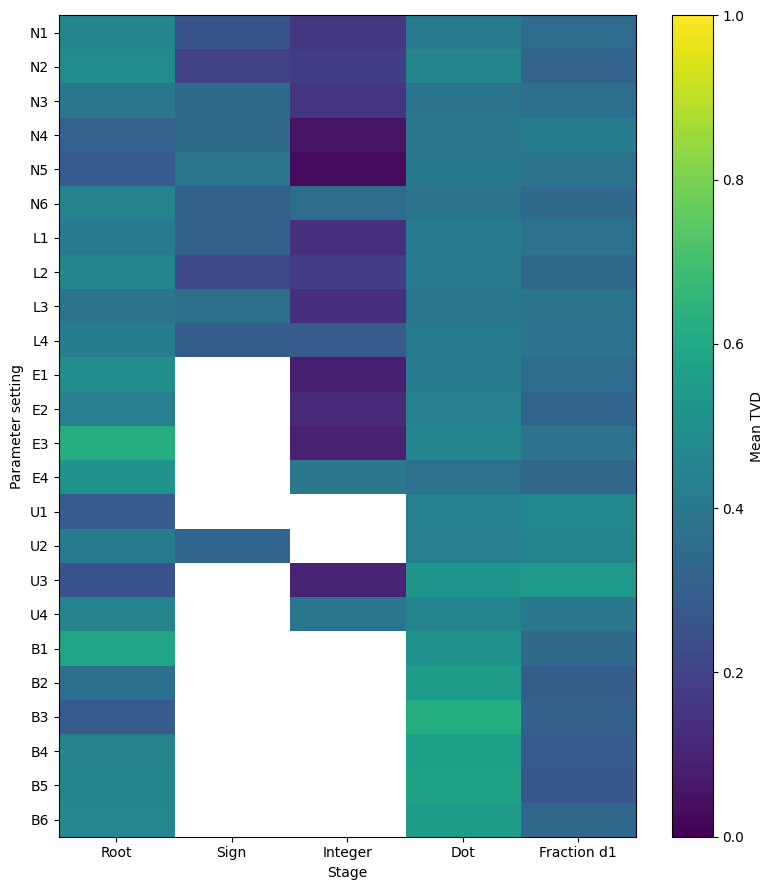

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 9))

im = ax.imshow(
    parameter_stage_matrix.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(PRIMARY_STAGE_ORDER)))
ax.set_xticklabels(
    ["Root", "Sign", "Integer", "Dot", "Fraction d1"]
)

ax.set_yticks(range(len(PARAMETER_ORDER)))
ax.set_yticklabels(PARAMETER_ORDER)

ax.set_xlabel("Stage")
ax.set_ylabel("Parameter setting")

fig.colorbar(
    im,
    ax=ax,
    label="Mean TVD"
)

plt.tight_layout()
plt.show()


### 05.7 Parameter × stage heatmap with family boundaries


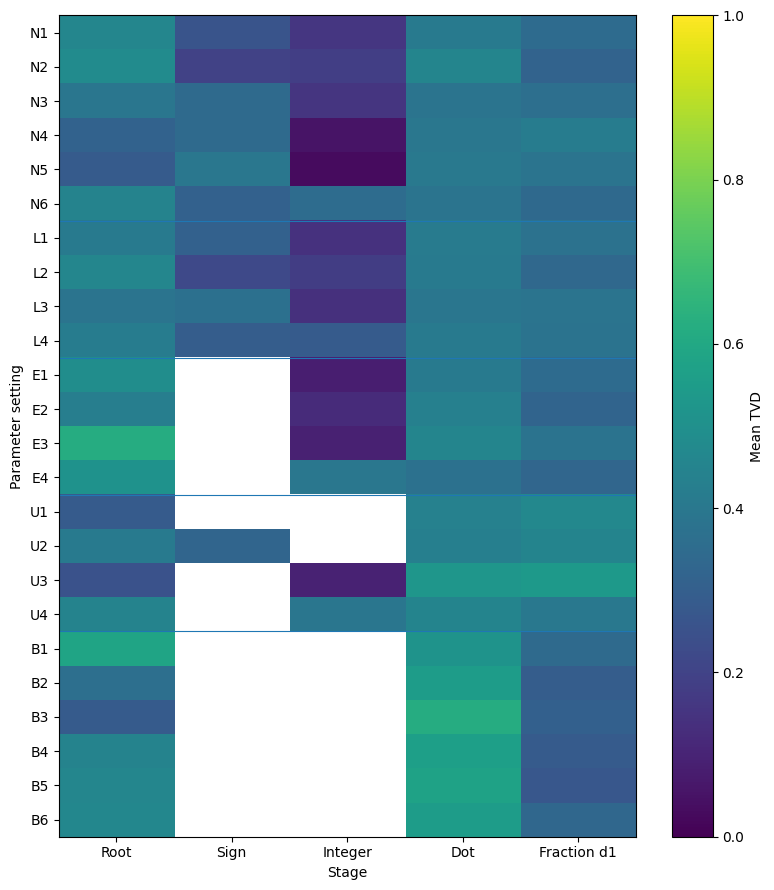

In [44]:
fig, ax = plt.subplots(figsize=(8, 9))

im = ax.imshow(
    parameter_stage_matrix.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(PRIMARY_STAGE_ORDER)))
ax.set_xticklabels(
    ["Root", "Sign", "Integer", "Dot", "Fraction d1"]
)

ax.set_yticks(range(len(PARAMETER_ORDER)))
ax.set_yticklabels(PARAMETER_ORDER)

# Family boundaries:
# Normal 6, Laplace 4, Exponential 4, Uniform 4, Beta 6
for boundary in [5.5, 9.5, 13.5, 17.5]:
    ax.axhline(boundary, linewidth=0.8)

ax.set_xlabel("Stage")
ax.set_ylabel("Parameter setting")

fig.colorbar(
    im,
    ax=ax,
    label="Mean TVD"
)

plt.tight_layout()
plt.show()


### 05.8 Parameter × model descriptive matrix


In [45]:
parameter_model = (
    stage_model
    .groupby(
        ["parameter_id", "model_id"],
        as_index=False,
    )
    .agg(
        stage_balanced_mean_tvd=("mean_tvd", "mean"),
        n_informative_stages=("analysis_stage", "nunique"),
    )
)

parameter_model_matrix = (
    parameter_model
    .pivot(
        index="parameter_id",
        columns="model_id",
        values="stage_balanced_mean_tvd",
    )
    .reindex(
        index=PARAMETER_ORDER,
        columns=MODEL_ORDER,
    )
)

display(parameter_model_matrix.round(3))


model_id,S1,S2,S3,S4,S5,S6
parameter_id,,,,,,
N1,0.136,0.232,0.471,0.300,0.543,0.275
N2,0.183,0.251,0.403,0.391,0.551,0.183
N3,0.183,0.239,0.557,0.232,0.581,0.180
N4,0.198,0.195,0.451,0.272,0.539,0.181
N5,0.136,0.252,0.454,0.260,0.546,0.156
N6,0.187,0.270,0.517,0.320,0.679,0.234
L1,0.132,0.248,0.471,0.288,0.601,0.245
L2,0.117,0.274,0.413,0.320,0.615,0.184
L3,0.168,0.279,0.560,0.199,0.591,0.213


### 05.9 Parameter × model heatmap


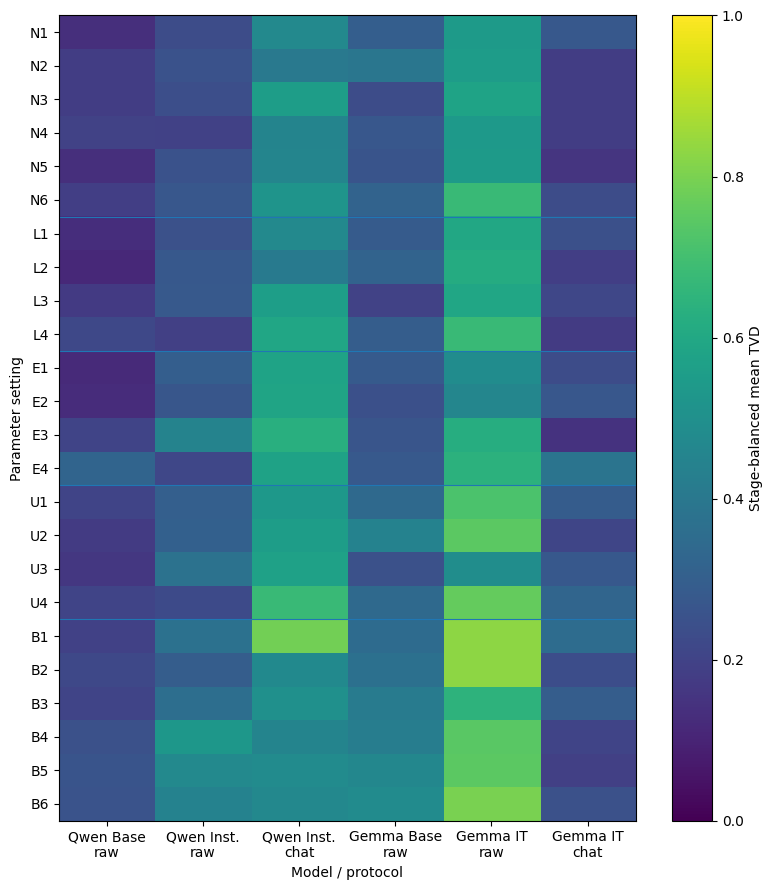

In [46]:
fig, ax = plt.subplots(figsize=(8, 9))

im = ax.imshow(
    parameter_model_matrix.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(
    [
        "Qwen Base\nraw",
        "Qwen Inst.\nraw",
        "Qwen Inst.\nchat",
        "Gemma Base\nraw",
        "Gemma IT\nraw",
        "Gemma IT\nchat",
    ]
)

ax.set_yticks(range(len(PARAMETER_ORDER)))
ax.set_yticklabels(PARAMETER_ORDER)

for boundary in [5.5, 9.5, 13.5, 17.5]:
    ax.axhline(boundary, linewidth=0.8)

ax.set_xlabel("Model / protocol")
ax.set_ylabel("Parameter setting")

fig.colorbar(
    im,
    ax=ax,
    label="Stage-balanced mean TVD"
)

plt.tight_layout()
plt.show()


### 05.10 Model/protocol heterogeneity diagnostic


In [47]:
model_spread = (
    stage_parameter[
        [
            "distribution",
            "parameter_id",
            "analysis_stage",
            "mean_tvd",
            "min_model_tvd",
            "max_model_tvd",
            "model_range",
        ]
    ]
    .sort_values(
        "model_range",
        ascending=False,
    )
)

display(model_spread.head(20).round(3))


,distribution,parameter_id,analysis_stage,mean_tvd,min_model_tvd,max_model_tvd,model_range
2,beta,B1,start,0.584,0.000,0.999,0.999
89,uniform,U2,sign,0.327,0.000,0.999,0.999
5,beta,B2,start,0.364,0.000,0.952,0.952
15,beta,B6,dot,0.553,0.117,0.997,0.880
17,beta,B6,start,0.461,0.000,0.863,0.863
41,laplace,L2,integer,0.181,0.000,0.846,0.846
12,beta,B5,dot,0.576,0.156,0.997,0.841
11,beta,B4,start,0.448,0.000,0.840,0.840
14,beta,B5,start,0.458,0.000,0.830,0.830
61,normal,N2,integer,0.185,0.000,0.821,0.821


### 05.11 Model-level descriptive summary


In [48]:
model_descriptive = (
    stage_model
    .groupby("model_id")
    .agg(
        stage_cells=("mean_tvd", "size"),
        mean_stage_tvd=("mean_tvd", "mean"),
        median_stage_tvd=("mean_tvd", "median"),
        min_stage_tvd=("mean_tvd", "min"),
        max_stage_tvd=("mean_tvd", "max"),
    )
    .reindex(MODEL_ORDER)
)

display(model_descriptive.round(3))


,stage_cells,mean_stage_tvd,median_stage_tvd,min_stage_tvd,max_stage_tvd
model_id,,,,,
S1,99,0.185,0.175,0.004,0.516
S2,99,0.293,0.289,0.000,0.825
S3,99,0.528,0.635,0.000,0.999
S4,99,0.316,0.218,0.021,0.894
S5,99,0.631,0.659,0.078,0.999
S6,99,0.232,0.207,0.000,0.899


### 05.12 TVD distribution by stage


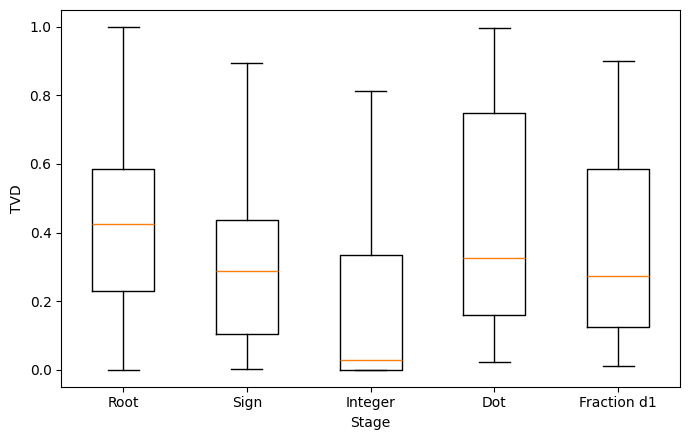

In [49]:
stage_plot_data = [
    primary_alignment.loc[
        primary_alignment["analysis_stage"] == stage,
        "tv_analytic_lm",
    ].dropna()
    for stage in PRIMARY_STAGE_ORDER
]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.boxplot(
    stage_plot_data,
    tick_labels=[
        "Root",
        "Sign",
        "Integer",
        "Dot",
        "Fraction d1",
    ],
    showfliers=False,
)

ax.set_ylabel("TVD")
ax.set_xlabel("Stage")

plt.tight_layout()
plt.show()


### 05.13 Atlas validation summary


In [50]:
atlas_check = pd.Series({
    "primary_informative_prefix_rows":
        len(primary_alignment),

    "parameter_settings":
        primary_alignment["parameter_id"].nunique(),

    "model_protocol_conditions":
        primary_alignment["model_id"].nunique(),

    "primary_stages":
        primary_alignment["analysis_stage"].nunique(),

    "parameter_stage_cells":
        len(stage_parameter),

    "model_parameter_stage_cells":
        len(stage_model),

    "minimum_primary_tvd":
        primary_alignment["tv_analytic_lm"].min(),

    "maximum_primary_tvd":
        primary_alignment["tv_analytic_lm"].max(),
})

display(atlas_check.to_frame("value"))


,value
primary_informative_prefix_rows,1.434000e+03
parameter_settings,2.400000e+01
model_protocol_conditions,6.000000e+00
primary_stages,5.000000e+00
parameter_stage_cells,9.900000e+01
model_parameter_stage_cells,5.940000e+02
minimum_primary_tvd,1.500603e-14
maximum_primary_tvd,9.996064e-01


### 05.14 Descriptive atlas notes

The descriptive atlas is used to inspect the outcome space before performing the planned parameter contrasts.

The following structural observations are carried forward:

1. TVD spans a wide range across the evaluated conditions.
2. Parameter-stage profiles vary visibly across parameter settings.
3. Model/protocol conditions show substantial heterogeneity within some parameter-stage cells.
4. Stage availability is not uniform across all parameter settings.
5. Therefore, parameter effects will be calculated within model/protocol condition and at the stage level.
6. Parameter contrasts with changing prefix coverage will be evaluated using both full-context and matched-prefix analyses where possible.

No substantive RQ3B conclusion is drawn from the descriptive atlas itself.


## 06 — RQ3B.1 Normal: Location and Scale

### Research question

How does changing the location or scale of a Normal target distribution alter next-symbol probabilistic alignment, and at which numerical stages do these effects occur?

The canonical reference condition is:

$$
N1 = \mathcal{N}(0,1).
$$

Two parameter dimensions are analysed separately.

#### Scale

- N2: $\mathcal{N}(0,0.5)$
- N1: $\mathcal{N}(0,1)$
- N3: $\mathcal{N}(0,2)$
- N6: $\mathcal{N}(0,10)$

#### Location

- N4: $\mathcal{N}(2,1)$
- N1: $\mathcal{N}(0,1)$
- N5: $\mathcal{N}(-2,1)$

N4 versus N5 is additionally treated as a mirrored-location control.


### 06.1 — Scale sensitivity

#### Pre-analysis expectation

Changing the Normal scale changes the amount of probability assigned to different numerical magnitudes while keeping the distribution centred at zero.

Therefore:

1. The manipulation does not introduce a location asymmetry.
2. Increasing scale should make larger-magnitude numerical regions more relevant.
3. Integer and dot stages may therefore become increasingly important as scale expands.
4. Fractional conditional distributions may also change, but fractional prefix coverage is not identical across the scale settings.
5. Full-context and matched-prefix effects must therefore be distinguished whenever prefix coverage changes.
6. No directional prediction is made about whether the LM becomes better or worse aligned. The analysis tests whether alignment changes and where such changes occur.


#### 06.1.1 Reusable contrast functions


In [51]:
def compute_stage_means(
    df,
    value_col="tv_analytic_lm",
):
    return (
        df
        .groupby(
            [
                "distribution",
                "parameter_id",
                "model_id",
                "analysis_stage",
            ],
            as_index=False,
        )
        .agg(
            mean_value=(value_col, "mean"),
            median_value=(value_col, "median"),
            n_prefixes=("prefix", "nunique"),
        )
    )


def compute_full_contrast(
    stage_table,
    target_id,
    reference_id,
):
    target = (
        stage_table[
            stage_table["parameter_id"] == target_id
        ][
            [
                "model_id",
                "analysis_stage",
                "mean_value",
            ]
        ]
        .rename(columns={"mean_value": "target_mean"})
    )

    reference = (
        stage_table[
            stage_table["parameter_id"] == reference_id
        ][
            [
                "model_id",
                "analysis_stage",
                "mean_value",
            ]
        ]
        .rename(columns={"mean_value": "reference_mean"})
    )

    out = target.merge(
        reference,
        on=["model_id", "analysis_stage"],
        how="inner",
        validate="one_to_one",
    )

    out["delta_full"] = (
        out["target_mean"]
        - out["reference_mean"]
    )

    out["contrast_id"] = (
        f"{target_id}_vs_{reference_id}"
    )

    return out


def compute_matched_contrast(
    df,
    target_id,
    reference_id,
    value_col="tv_analytic_lm",
):
    target = (
        df[df["parameter_id"] == target_id][
            [
                "model_id",
                "analysis_stage",
                "prefix",
                value_col,
            ]
        ]
        .rename(columns={value_col: "target_value"})
    )

    reference = (
        df[df["parameter_id"] == reference_id][
            [
                "model_id",
                "analysis_stage",
                "prefix",
                value_col,
            ]
        ]
        .rename(columns={value_col: "reference_value"})
    )

    paired = target.merge(
        reference,
        on=[
            "model_id",
            "analysis_stage",
            "prefix",
        ],
        how="inner",
        validate="one_to_one",
    )

    paired["delta_pair"] = (
        paired["target_value"]
        - paired["reference_value"]
    )

    summary = (
        paired
        .groupby(
            ["model_id", "analysis_stage"],
            as_index=False,
        )
        .agg(
            delta_matched=("delta_pair", "mean"),
            median_matched=("delta_pair", "median"),
            n_common=("prefix", "nunique"),
        )
    )

    summary["contrast_id"] = (
        f"{target_id}_vs_{reference_id}"
    )

    return summary, paired


def summarise_across_models(
    df,
    value_col,
):
    return (
        df
        .groupby(
            ["contrast_id", "analysis_stage"]
        )[value_col]
        .agg(
            mean_effect="mean",
            median_effect="median",
            min_effect="min",
            max_effect="max",
            n_models="count",
            n_worse=lambda x: (x > 0).sum(),
            n_better=lambda x: (x < 0).sum(),
        )
        .reset_index()
    )


#### 06.1.2 Construct the Normal scale analysis tables


In [52]:
normal_primary = prefix[
    (prefix["distribution"] == "normal")
    & prefix["primary_alignment_row"]
].copy()

normal_stage = compute_stage_means(normal_primary)

NORMAL_SCALE = ["N2", "N3", "N6"]

normal_scale_full = pd.concat(
    [
        compute_full_contrast(
            normal_stage,
            target_id=parameter_id,
            reference_id="N1",
        )
        for parameter_id in NORMAL_SCALE
    ],
    ignore_index=True,
)

matched_outputs = [
    compute_matched_contrast(
        normal_primary,
        target_id=parameter_id,
        reference_id="N1",
    )
    for parameter_id in NORMAL_SCALE
]

normal_scale_matched = pd.concat(
    [x[0] for x in matched_outputs],
    ignore_index=True,
)

normal_scale_pairs = {
    parameter_id: matched_outputs[i][1]
    for i, parameter_id in enumerate(NORMAL_SCALE)
}


#### 06.1.3 Full-context scale effects


In [53]:
scale_full_summary = summarise_across_models(
    normal_scale_full,
    "delta_full",
)

scale_full_summary["stage_order"] = (
    scale_full_summary["analysis_stage"]
    .map({stage: i for i, stage in enumerate(PRIMARY_STAGE_ORDER)})
)

scale_full_summary = (
    scale_full_summary
    .sort_values(["contrast_id", "stage_order"])
    .drop(columns="stage_order")
)

display(scale_full_summary.round(4))


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
4,N2_vs_N1,start,0.0241,0.0297,-0.1702,0.1291,6,4,2
3,N2_vs_N1,sign,-0.0647,-0.1120,-0.2719,0.2191,6,3,3
2,N2_vs_N1,integer,0.0292,0.0181,0.0000,0.0993,6,6,0
0,N2_vs_N1,dot,0.0482,0.0535,-0.1211,0.1689,6,4,2
1,N2_vs_N1,fraction_d1,-0.0328,-0.0457,-0.1172,0.0702,6,2,4
9,N3_vs_N1,start,-0.0650,-0.0459,-0.2322,0.0972,6,2,4
8,N3_vs_N1,sign,0.0840,0.0683,-0.2389,0.3825,6,3,3
7,N3_vs_N1,integer,-0.0011,0.0000,-0.0435,0.0270,6,4,2
5,N3_vs_N1,dot,-0.0232,-0.0055,-0.1487,0.0471,6,3,3
6,N3_vs_N1,fraction_d1,0.0172,0.0301,-0.0896,0.0995,6,4,2


#### 06.1.4 Matched-prefix scale effects


In [54]:
scale_matched_summary = summarise_across_models(
    normal_scale_matched,
    "delta_matched",
)

common_counts = (
    normal_scale_matched
    .groupby(["contrast_id", "analysis_stage"])["n_common"]
    .first()
    .reset_index()
)

scale_matched_summary = (
    scale_matched_summary
    .merge(
        common_counts,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)

scale_matched_summary["stage_order"] = (
    scale_matched_summary["analysis_stage"]
    .map({stage: i for i, stage in enumerate(PRIMARY_STAGE_ORDER)})
)

scale_matched_summary = (
    scale_matched_summary
    .sort_values(["contrast_id", "stage_order"])
    .drop(columns="stage_order")
)

display(scale_matched_summary.round(4))


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
4,N2_vs_N1,start,0.0241,0.0297,-0.1702,0.1291,6,4,2,1
3,N2_vs_N1,sign,-0.0647,-0.1120,-0.2719,0.2191,6,3,3,1
2,N2_vs_N1,integer,0.0292,0.0181,0.0000,0.0993,6,6,0,2
0,N2_vs_N1,dot,0.0482,0.0535,-0.1211,0.1689,6,4,2,4
1,N2_vs_N1,fraction_d1,-0.0249,-0.0352,-0.0745,0.0482,6,2,4,2
9,N3_vs_N1,start,-0.0650,-0.0459,-0.2322,0.0972,6,2,4,1
8,N3_vs_N1,sign,0.0840,0.0683,-0.2389,0.3825,6,3,3,1
7,N3_vs_N1,integer,0.0370,0.0137,-0.0000,0.1448,6,5,1,2
5,N3_vs_N1,dot,-0.0118,-0.0109,-0.1238,0.0461,6,2,4,4
6,N3_vs_N1,fraction_d1,0.0068,0.0216,-0.0816,0.0711,6,4,2,2


#### 06.1.5 Compare full-context and matched-prefix effects


In [55]:
scale_effect_summary = (
    scale_full_summary[
        [
            "contrast_id",
            "analysis_stage",
            "mean_effect",
            "median_effect",
            "n_worse",
            "n_better",
        ]
    ]
    .rename(columns={
        "mean_effect": "full_mean_effect",
        "median_effect": "full_median_effect",
        "n_worse": "full_n_worse",
        "n_better": "full_n_better",
    })
    .merge(
        scale_matched_summary[
            [
                "contrast_id",
                "analysis_stage",
                "mean_effect",
                "median_effect",
                "n_worse",
                "n_better",
                "n_common",
            ]
        ].rename(columns={
            "mean_effect": "matched_mean_effect",
            "median_effect": "matched_median_effect",
            "n_worse": "matched_n_worse",
            "n_better": "matched_n_better",
        }),
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)

display(scale_effect_summary.round(4))


,contrast_id,analysis_stage,full_mean_effect,full_median_effect,full_n_worse,full_n_better,matched_mean_effect,matched_median_effect,matched_n_worse,matched_n_better,n_common
0,N2_vs_N1,start,0.0241,0.0297,4,2,0.0241,0.0297,4,2,1
1,N2_vs_N1,sign,-0.0647,-0.1120,3,3,-0.0647,-0.1120,3,3,1
2,N2_vs_N1,integer,0.0292,0.0181,6,0,0.0292,0.0181,6,0,2
3,N2_vs_N1,dot,0.0482,0.0535,4,2,0.0482,0.0535,4,2,4
4,N2_vs_N1,fraction_d1,-0.0328,-0.0457,2,4,-0.0249,-0.0352,2,4,2
5,N3_vs_N1,start,-0.0650,-0.0459,2,4,-0.0650,-0.0459,2,4,1
6,N3_vs_N1,sign,0.0840,0.0683,3,3,0.0840,0.0683,3,3,1
7,N3_vs_N1,integer,-0.0011,0.0000,4,2,0.0370,0.0137,5,1,2
8,N3_vs_N1,dot,-0.0232,-0.0055,3,3,-0.0118,-0.0109,2,4,4
9,N3_vs_N1,fraction_d1,0.0172,0.0301,4,2,0.0068,0.0216,4,2,2


In [56]:
normal_primary = prefix[
    (prefix["distribution"] == "normal")
    & prefix["primary_alignment_row"]
].copy()

normal_stage = compute_stage_means(
    normal_primary
)

NORMAL_SCALE = ["N2", "N3", "N6"]

normal_scale_full = pd.concat(
    [
        compute_full_contrast(
            normal_stage,
            target_id=parameter_id,
            reference_id="N1",
        )
        for parameter_id in NORMAL_SCALE
    ],
    ignore_index=True,
)

matched_outputs = [
    compute_matched_contrast(
        normal_primary,
        target_id=parameter_id,
        reference_id="N1",
    )
    for parameter_id in NORMAL_SCALE
]

normal_scale_matched = pd.concat(
    [x[0] for x in matched_outputs],
    ignore_index=True,
)

#### 06.1.6 Localise the extreme-scale integer effect to shared prefixes


In [57]:
n1_integer_prefixes = set(
    normal_primary.loc[
        (normal_primary["parameter_id"] == "N1")
        & (normal_primary["analysis_stage"] == "integer"),
        "prefix",
    ]
)

n6_integer_prefixes = set(
    normal_primary.loc[
        (normal_primary["parameter_id"] == "N6")
        & (normal_primary["analysis_stage"] == "integer"),
        "prefix",
    ]
)

print("N1 integer prefixes:", sorted(n1_integer_prefixes))
print("N6 integer prefixes:", sorted(n6_integer_prefixes))
print("Common:", sorted(n1_integer_prefixes & n6_integer_prefixes))


N1 integer prefixes: ['-1', '1']
N6 integer prefixes: ['-1', '-10', '1', '10']
Common: ['-1', '1']


#### 06.1.7 Model/protocol robustness of the N6 integer effect


In [58]:
n6_integer_by_model = (
    normal_scale_matched[
        (normal_scale_matched["contrast_id"] == "N6_vs_N1")
        & (normal_scale_matched["analysis_stage"] == "integer")
    ][
        ["model_id", "delta_matched", "n_common"]
    ]
    .sort_values("model_id")
)

display(n6_integer_by_model.round(4))


,model_id,delta_matched,n_common
62,S1,0.1922,2
67,S2,0.5856,2
72,S3,0.7937,2
77,S4,0.1215,2
82,S5,-0.1220,2
87,S6,0.6919,2


#### 06.1.8 Prefix-specific N6 vs N1 integer effects


In [59]:
n6_n1_pairs = normal_scale_pairs["N6"]

n6_integer_prefix_effects = (
    n6_n1_pairs[
        n6_n1_pairs["analysis_stage"] == "integer"
    ]
    .pivot(
        index="model_id",
        columns="prefix",
        values="delta_pair",
    )
    .reindex(MODEL_ORDER)
)

display(n6_integer_prefix_effects.round(4))


prefix,-1,1
model_id,,
S1,0.0472,0.3371
S2,0.6925,0.4786
S3,0.8122,0.7751
S4,0.2067,0.0362
S5,-0.2563,0.0124
S6,0.7586,0.6253


#### 06.1.9 Full versus matched scale-effect plot


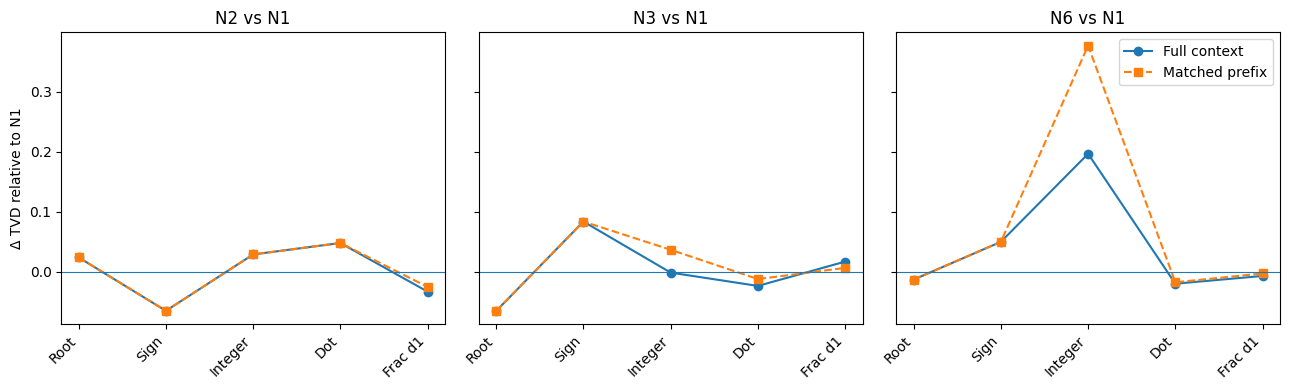

In [60]:
import matplotlib.pyplot as plt

scale_effect_plot = (
    normal_scale_full[
        [
            "contrast_id",
            "model_id",
            "analysis_stage",
            "delta_full",
        ]
    ]
    .merge(
        normal_scale_matched[
            [
                "contrast_id",
                "model_id",
                "analysis_stage",
                "delta_matched",
            ]
        ],
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="left",
    )
)

scale_plot_summary = (
    scale_effect_plot
    .groupby(
        ["contrast_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        full=("delta_full", "mean"),
        matched=("delta_matched", "mean"),
    )
)

contrast_order = [
    "N2_vs_N1",
    "N3_vs_N1",
    "N6_vs_N1",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
    sharey=True,
)

for ax, contrast_id in zip(axes, contrast_order):
    temp = (
        scale_plot_summary[
            scale_plot_summary["contrast_id"] == contrast_id
        ]
        .set_index("analysis_stage")
        .reindex(PRIMARY_STAGE_ORDER)
    )

    x = np.arange(len(PRIMARY_STAGE_ORDER))

    ax.plot(x, temp["full"], marker="o", label="Full context")
    ax.plot(
        x,
        temp["matched"],
        marker="s",
        linestyle="--",
        label="Matched prefix",
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["Root", "Sign", "Integer", "Dot", "Frac d1"],
        rotation=45,
        ha="right",
    )

    ax.set_title(contrast_id.replace("_vs_", " vs "))

axes[0].set_ylabel("Δ TVD relative to N1")
axes[-1].legend()

plt.tight_layout()
plt.show()


#### 06.1.10 Interpretation

- **N2: narrower Normal.** Moving from $\sigma=1$ to $\sigma=0.5$ produces mostly small and stage-dependent changes. The integer-stage effect is directionally consistent but small, while other stages do not show a common direction across model/protocol conditions.
- **N3: moderately wider Normal.** Moving to $\sigma=2$ again does not produce a uniform stage-wide effect. The matched integer comparison shows a modest worsening even though the full-context integer effect is close to zero, indicating that newly included integer contexts partly mask the same-prefix change.
- **N6: extreme scale.** The strongest scale effect is concentrated at the integer stage. The matched-prefix effect is larger than the full-context effect, showing that the deterioration is already present at the shared integer prefixes rather than being created only by the additional large-magnitude contexts.

The extreme-scale effect is therefore stage-localised, but its magnitude is model/protocol dependent.


#### 06.1.11 Result statement

Normal scale changes did not produce a uniform shift in alignment across numerical stages. Relative to $\mathcal{N}(0,1)$, the narrower $\mathcal{N}(0,0.5)$ condition produced a small matched integer-stage TVD increase, with higher TVD in all six model/protocol conditions. For $\mathcal{N}(0,2)$, the matched integer-stage effect was also positive in most conditions, although the corresponding full-context effect was close to zero. The extreme $\mathcal{N}(0,10)$ condition produced the strongest scale effect: integer-stage TVD increased substantially in both the full-context and matched-prefix comparisons, with five of six model/protocol conditions showing higher matched-prefix TVD. Changes at ROOT, sign, dot, and Fraction depth 1 were smaller on average and less directionally consistent.


#### 06.1.12 Result conclusion

Normal alignment is sensitive to scale, but the sensitivity is not a uniform deterioration across the numerical representation. The clearest scale dependence occurs at the integer stage, and it becomes pronounced under the extreme scale condition. Matched-prefix analysis shows that this effect cannot be explained solely by the introduction of additional large-magnitude prefixes: at the shared integer prefixes, the extreme-scale deterioration remains strong. However, the magnitude is model/protocol dependent, so the effect should not be described as universal across models.

**Deferred mechanistic follow-up:** token-level decomposition of N6 versus N1 at the shared integer prefixes is reserved until the Normal location analysis is complete.


### 06.2 — Location sensitivity

**Next analysis block:** N4 and N5 versus N1, followed by the N4 versus N5 mirrored-location control.

The fractional prefixes do not overlap with N1 for N4/N5, so fractional differences must be interpreted as changed numerical-region effects rather than same-prefix location effects.


## 06.2 — Location sensitivity

### Pre-analysis expectation

Changing the Normal location shifts probability mass toward different numerical regions while keeping the scale fixed.

The relevant conditions are:

- N1: $\mathcal{N}(0,1)$
- N4: $\mathcal{N}(2,1)$
- N5: $\mathcal{N}(-2,1)$

Two questions are distinguished:

1. How does shifting the mean away from zero alter alignment relative to N1?
2. Do the mirrored positive and negative location shifts behave symmetrically?

The prefix structure differs substantially across the location conditions.

In particular:

- N4 and N5 share ROOT and sign with N1.
- Some integer and dot prefixes overlap.
- Fraction depth-1 prefixes do not overlap with N1.
- N4 and N5 themselves contain mirrored numerical regions rather than identical later-stage prefixes.

Therefore, full-context effects and exact matched-prefix effects must be interpreted separately. For the N4-versus-N5 control, a mirrored-prefix comparison is additionally appropriate.

06.2.1 Compute N4 and N5 relative to N1

In [61]:
NORMAL_LOCATION = ["N4", "N5"]

normal_location_full = pd.concat(
    [
        compute_full_contrast(
            normal_stage,
            target_id=parameter_id,
            reference_id="N1",
        )
        for parameter_id in NORMAL_LOCATION
    ],
    ignore_index=True,
)

location_matched_outputs = [
    compute_matched_contrast(
        normal_primary,
        target_id=parameter_id,
        reference_id="N1",
    )
    for parameter_id in NORMAL_LOCATION
]

normal_location_matched = pd.concat(
    [x[0] for x in location_matched_outputs],
    ignore_index=True,
)

In [62]:
location_full_summary = summarise_across_models(
    normal_location_full,
    "delta_full",
)

location_matched_summary = summarise_across_models(
    normal_location_matched,
    "delta_matched",
)

location_common_counts = (
    normal_location_matched
    .groupby(
        ["contrast_id", "analysis_stage"]
    )["n_common"]
    .first()
    .reset_index()
)

location_matched_summary = (
    location_matched_summary
    .merge(
        location_common_counts,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)
print("Full context summary for location contrasts:")
display(
    location_full_summary
    .sort_values(
        ["contrast_id", "analysis_stage"]
    )
    .round(4)
)
print("Matched prefix summary for location contrasts:")

display(
    location_matched_summary
    .sort_values(
        ["contrast_id", "analysis_stage"]
    )
    .round(4)
)

Full context summary for location contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,N4_vs_N1,dot,-0.0087,0.0138,-0.1783,0.0951,6,3,3
1,N4_vs_N1,fraction_d1,0.0683,0.0263,-0.0552,0.2260,6,5,1
2,N4_vs_N1,integer,-0.1027,-0.0060,-0.5441,-0.0000,6,0,6
3,N4_vs_N1,sign,0.0847,0.0014,-0.2652,0.7498,6,3,3
4,N4_vs_N1,start,-0.1435,-0.1571,-0.3824,0.1586,6,1,5
5,N5_vs_N1,dot,-0.0012,0.0329,-0.1361,0.0609,6,4,2
6,N5_vs_N1,fraction_d1,0.0369,0.0066,-0.1404,0.1995,6,4,2
7,N5_vs_N1,integer,-0.1268,-0.0112,-0.5698,-0.0000,6,0,6
8,N5_vs_N1,sign,0.1352,0.1492,-0.2801,0.5438,6,4,2
9,N5_vs_N1,start,-0.1714,-0.1497,-0.4880,0.2222,6,2,4


Matched prefix summary for location contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
0,N4_vs_N1,dot,-0.0435,-0.0018,-0.2312,0.0974,6,3,3,3
1,N4_vs_N1,integer,-0.0058,-0.0000,-0.1021,0.0833,6,2,4,1
2,N4_vs_N1,sign,0.0847,0.0014,-0.2652,0.7498,6,3,3,1
3,N4_vs_N1,start,-0.1435,-0.1571,-0.3824,0.1586,6,1,5,1
4,N5_vs_N1,dot,0.0181,0.0345,-0.1521,0.1035,6,5,1,3
5,N5_vs_N1,integer,-0.1105,-0.0059,-0.6121,-0.0000,6,0,6,1
6,N5_vs_N1,sign,0.1352,0.1492,-0.2801,0.5438,6,4,2,1
7,N5_vs_N1,start,-0.1714,-0.1497,-0.4880,0.2222,6,2,4,1


In [63]:
n5_integer_by_model = (
    normal_location_matched[
        (normal_location_matched["contrast_id"] == "N5_vs_N1")
        & (
            normal_location_matched["analysis_stage"]
            == "integer"
        )
    ][
        [
            "model_id",
            "delta_matched",
            "n_common",
        ]
    ]
    .sort_values("model_id")
)

display(n5_integer_by_model.round(4))

,model_id,delta_matched,n_common
25,S1,-0.0118,1
29,S2,-0.0001,1
33,S3,-0.0000,1
37,S4,-0.0388,1
41,S5,-0.6121,1
45,S6,-0.0000,1


One plausible mechanism is that the ROOT truth distribution becomes less balanced when the Normal is shifted away from zero, potentially making the first numerical decision easier for some models.

But we should write that only as a hypothesis for now.

We have not yet tested the truth geometry at ROOT, so do not put that mechanism into the empirical result statement.

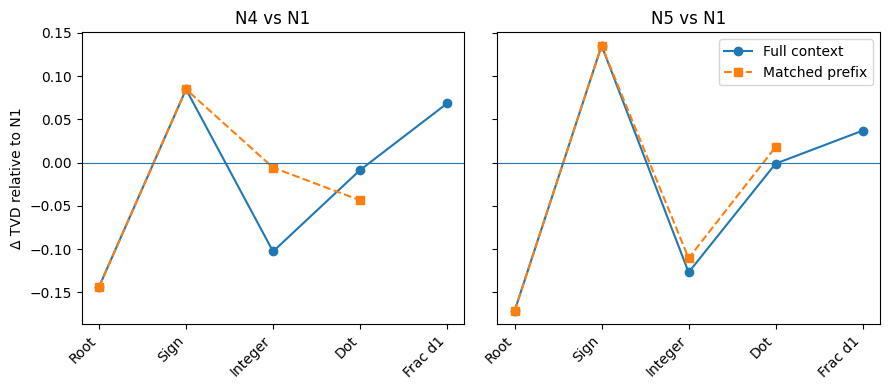

In [64]:
location_effect_plot = (
    normal_location_full[
        [
            "contrast_id",
            "model_id",
            "analysis_stage",
            "delta_full",
        ]
    ]
    .merge(
        normal_location_matched[
            [
                "contrast_id",
                "model_id",
                "analysis_stage",
                "delta_matched",
            ]
        ],
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="left",
    )
)

location_plot_summary = (
    location_effect_plot
    .groupby(
        ["contrast_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        full=("delta_full", "mean"),
        matched=("delta_matched", "mean"),
    )
)

contrast_order = [
    "N4_vs_N1",
    "N5_vs_N1",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    sharey=True,
)

for ax, contrast_id in zip(
    axes,
    contrast_order,
):
    temp = (
        location_plot_summary[
            location_plot_summary["contrast_id"]
            == contrast_id
        ]
        .set_index("analysis_stage")
        .reindex(PRIMARY_STAGE_ORDER)
    )

    x = np.arange(len(PRIMARY_STAGE_ORDER))

    ax.plot(
        x,
        temp["full"],
        marker="o",
        label="Full context",
    )

    ax.plot(
        x,
        temp["matched"],
        marker="s",
        linestyle="--",
        label="Matched prefix",
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "Root",
            "Sign",
            "Integer",
            "Dot",
            "Frac d1",
        ],
        rotation=45,
        ha="right",
    )

    ax.set_title(
        contrast_id.replace("_vs_", " vs ")
    )

axes[0].set_ylabel(
    "Δ TVD relative to N1"
)

axes[-1].legend()

plt.tight_layout()
plt.show()

In [65]:
def mirror_numeric_prefix(prefix_value):
    if prefix_value == "ROOT":
        return "ROOT"

    prefix_value = str(prefix_value)

    # There is no explicit positive-sign prefix corresponding
    # to the negative-sign branch.
    if prefix_value == "-":
        return None

    if prefix_value.startswith("-"):
        return prefix_value[1:]

    return "-" + prefix_value

In [66]:
n4_mirror = (
    normal_primary[
        normal_primary["parameter_id"] == "N4"
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "tv_analytic_lm",
        ]
    ]
    .copy()
)

n4_mirror["mirror_prefix"] = (
    n4_mirror["prefix"]
    .map(mirror_numeric_prefix)
)

n5_mirror = (
    normal_primary[
        normal_primary["parameter_id"] == "N5"
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "tv_analytic_lm",
        ]
    ]
    .copy()
)

mirror_pairs = n4_mirror.merge(
    n5_mirror,
    left_on=[
        "model_id",
        "analysis_stage",
        "mirror_prefix",
    ],
    right_on=[
        "model_id",
        "analysis_stage",
        "prefix",
    ],
    suffixes=("_N4", "_N5"),
)

mirror_pairs["delta_mirror"] = (
    mirror_pairs["tv_analytic_lm_N4"]
    - mirror_pairs["tv_analytic_lm_N5"]
)

In [67]:
mirror_model = (
    mirror_pairs
    .groupby(
        ["model_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        delta_mirror=("delta_mirror", "mean"),
        n_pairs=("delta_mirror", "size"),
    )
)

mirror_summary = (
    mirror_model
    .groupby("analysis_stage")
    ["delta_mirror"]
    .agg(
        mean_effect="mean",
        median_effect="median",
        min_effect="min",
        max_effect="max",
        n_models="count",
        n4_worse=lambda x: (x > 0).sum(),
        n4_better=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

mirror_pair_counts = (
    mirror_model
    .groupby("analysis_stage")
    ["n_pairs"]
    .first()
    .reset_index()
)

mirror_summary = mirror_summary.merge(
    mirror_pair_counts,
    on="analysis_stage",
    how="left",
)

display(mirror_summary.round(4))

,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n4_worse,n4_better,n_pairs
0,dot,-0.0074,0.0245,-0.1352,0.0583,6,3,3,5
1,fraction_d1,0.0314,0.0223,-0.0588,0.1582,6,5,1,3
2,integer,0.0241,0.0053,0.0000,0.1084,6,6,0,3
3,start,0.0280,-0.0312,-0.6047,0.6358,6,3,3,1


weak evidence of sign/location asymmetry at later numerical stages, rather than a large systematic positive-versus-negative effect.

### Mirror-control interpretation boundary

N4 and N5 are mathematically mirrored target distributions, but the textual representation of positive and negative numbers is not perfectly symmetric because negative continuations require an explicit sign symbol whereas positive continuations usually do not.

Therefore, any N4-versus-N5 alignment difference is compatible with representation-level asymmetry, but the current TVD analysis alone does not identify the mechanism responsible for that asymmetry.

### Result statement

Shifting the Normal mean away from zero changed alignment in a stage-dependent manner. At ROOT, $\mathcal{N}(2,1)$ and $\mathcal{N}(-2,1)$ reduced mean TVD relative to $\mathcal{N}(0,1)$ by approximately $0.143$ and $0.171$, respectively; the corresponding median effects were approximately $-0.157$ and $-0.150$. The full-context integer-stage TVD was also lower for both shifted conditions, by approximately $0.103$ for N4 and $0.127$ for N5. However, for N4 the exact matched-prefix integer effect was only approximately $-0.006$, showing that most of the full-context difference was associated with the changed integer regions introduced by the location shift. For N5, the matched effect at the shared prefix $-1$ was approximately $-0.110$, but its median across model/protocol conditions was only approximately $-0.006$ because one condition contributed a substantially larger improvement. Fraction depth-1 TVD increased by approximately $0.068$ for N4 and $0.037$ for N5 in the full-context comparison, but no exact fractional prefixes were shared with N1, so these differences cannot be interpreted as same-prefix location effects. In the mirrored N4-versus-N5 control, positive-location TVD was slightly higher at mirrored integer and fractional contexts, with mean differences of approximately $0.024$ and $0.031$, respectively.

### Result conclusion

Normal location sensitivity is not adequately described by a single overall change in alignment. Moving the mean away from zero produces a comparatively clear change at ROOT, where the numerical context is identical across conditions. Later-stage effects are more strongly entangled with the numerical regions activated by the location shift. In particular, the apparent integer-stage improvement for the positive shift largely disappears under exact-prefix matching, while the negative-shift integer mean is strongly influenced by one model/protocol condition. Fractional differences reflect different numerical regions rather than same-prefix sensitivity because the shifted and canonical conditions share no fractional prefixes. The mirrored positive- and negative-location conditions show only modest later-stage asymmetries, suggesting that any representation-side sign asymmetry is present but not uniformly large across models and stages.

## 06.3 — Normal family conclusion

Normal parameter sensitivity depends strongly on both the type and magnitude of the parameter manipulation.

Scale changes produce their clearest effect at the integer stage. Moderate scale changes yield relatively small same-prefix effects, whereas the extreme $\mathcal{N}(0,10)$ condition produces a pronounced integer-stage deterioration that remains, and becomes stronger, when analysis is restricted to the two integer prefixes shared with $\mathcal{N}(0,1)$. This provides evidence for genuine same-prefix sensitivity to extreme scale rather than an effect caused only by additional large-magnitude contexts.

Location shifts behave differently. Their clearest same-context effect occurs at ROOT, while apparent later-stage differences are substantially influenced by the change in represented numerical regions. Exact-prefix matching removes most of the positive-shift integer effect, and no exact fractional comparison with the canonical condition is possible. The positive and negative location shifts are approximately, but not perfectly, symmetric in alignment at mirrored contexts.

Overall, the Normal results show that parameter sensitivity is stage-specific and that two mechanisms must be distinguished: changes in the model's alignment at an unchanged numerical prefix, and changes in alignment associated with the different numerical regions made relevant by a new target parameterisation.

Changing the Normal location changes what the model ought to expect before it has generated even a single digit.

# 07 — RQ3B.2 Laplace: Scale Sensitivity

## Research question

How does changing the scale of a Laplace target distribution alter next-symbol probabilistic alignment, and at which numerical stages do these effects occur?

The canonical reference is:

$$
L1 = \mathrm{Laplace}(0,1).
$$

The scale conditions are:

- L2: $\mathrm{Laplace}(0,0.5)$
- L1: $\mathrm{Laplace}(0,1)$
- L3: $\mathrm{Laplace}(0,2)$
- L4: $\mathrm{Laplace}(0,10)$

Location remains fixed at zero throughout the family.

## 07.1 — Pre-analysis expectation

Changing Laplace scale changes the spread of the target distribution without changing its centre or symmetry.

Therefore:

1. Any systematic change can be attributed to scale rather than location.
2. Wider scales make larger-magnitude numerical regions relevant.
3. Integer-stage sensitivity may therefore become increasingly important as scale expands.
4. ROOT and sign remain directly comparable across all scale conditions.
5. L2 preserves the canonical integer and dot prefix structure, whereas L3 and L4 introduce additional magnitude contexts.
6. Fractional prefix coverage changes with scale, so full-context and matched-prefix fractional effects must be distinguished.
7. No directional prediction is made about whether scale improves or worsens LM alignment.

In [68]:
laplace_primary = prefix[
    (prefix["distribution"] == "laplace")
    & prefix["primary_alignment_row"]
].copy()

laplace_stage = compute_stage_means(
    laplace_primary
)

LAPLACE_SCALE = ["L2", "L3", "L4"]

laplace_full = pd.concat(
    [
        compute_full_contrast(
            laplace_stage,
            target_id=parameter_id,
            reference_id="L1",
        )
        for parameter_id in LAPLACE_SCALE
    ],
    ignore_index=True,
)

laplace_matched_outputs = [
    compute_matched_contrast(
        laplace_primary,
        target_id=parameter_id,
        reference_id="L1",
    )
    for parameter_id in LAPLACE_SCALE
]

laplace_matched = pd.concat(
    [x[0] for x in laplace_matched_outputs],
    ignore_index=True,
)

In [69]:
laplace_full_summary = summarise_across_models(
    laplace_full,
    "delta_full",
)

laplace_matched_summary = summarise_across_models(
    laplace_matched,
    "delta_matched",
)

laplace_common_counts = (
    laplace_matched
    .groupby(
        ["contrast_id", "analysis_stage"]
    )["n_common"]
    .first()
    .reset_index()
)

laplace_matched_summary = (
    laplace_matched_summary
    .merge(
        laplace_common_counts,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)

print("Full context summary for location contrasts:")
display(
    laplace_full_summary
    .sort_values(
        ["contrast_id", "analysis_stage"]
    )
    .round(4)
)
print("Matched prefix summary for location contrasts:")

display(
    laplace_matched_summary
    .sort_values(
        ["contrast_id", "analysis_stage"]
    )
    .round(4)
)

Full context summary for location contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,L2_vs_L1,dot,-0.0084,-0.0096,-0.0971,0.1194,6,3,3
1,L2_vs_L1,fraction_d1,-0.0414,-0.0523,-0.1061,0.0532,6,1,5
2,L2_vs_L1,integer,0.0387,0.0001,-0.0002,0.2237,6,4,2
3,L2_vs_L1,sign,-0.0926,-0.0906,-0.2314,0.1248,6,1,5
4,L2_vs_L1,start,0.0534,0.0476,-0.0841,0.1928,6,4,2
5,L3_vs_L1,dot,-0.0240,-0.0040,-0.1085,0.0367,6,3,3
6,L3_vs_L1,fraction_d1,0.0073,-0.0019,-0.0776,0.1099,6,3,3
7,L3_vs_L1,integer,-0.0019,0.0133,-0.0687,0.0136,6,5,1
8,L3_vs_L1,sign,0.0589,0.0306,-0.2150,0.5057,6,3,3
9,L3_vs_L1,start,-0.0198,-0.0107,-0.1338,0.0872,6,3,3


Matched prefix summary for location contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
0,L2_vs_L1,dot,-0.0084,-0.0096,-0.0971,0.1194,6,3,3,4
1,L2_vs_L1,fraction_d1,-0.0396,-0.0532,-0.1503,0.1157,6,2,4,2
2,L2_vs_L1,integer,0.0387,0.0001,-0.0002,0.2237,6,4,2,2
3,L2_vs_L1,sign,-0.0926,-0.0906,-0.2314,0.1248,6,1,5,1
4,L2_vs_L1,start,0.0534,0.0476,-0.0841,0.1928,6,4,2,1
5,L3_vs_L1,dot,-0.0132,0.0061,-0.0914,0.0290,6,4,2,4
6,L3_vs_L1,fraction_d1,-0.0035,-0.0095,-0.0478,0.0541,6,2,4,2
7,L3_vs_L1,integer,0.0451,0.0271,-0.0305,0.1973,6,5,1,2
8,L3_vs_L1,sign,0.0589,0.0306,-0.2150,0.5057,6,3,3,1
9,L3_vs_L1,start,-0.0198,-0.0107,-0.1338,0.0872,6,3,3,1


In [70]:
for parameter_id in ["L1", "L2", "L3", "L4"]:

    print(f"\n{parameter_id}")

    temp = laplace_primary[
        laplace_primary["parameter_id"]
        == parameter_id
    ]

    for stage in PRIMARY_STAGE_ORDER:
        values = sorted(
            temp.loc[
                temp["analysis_stage"] == stage,
                "prefix",
            ].unique()
        )

        print(stage, values)


L1
start ['ROOT']
sign ['-']
integer ['-1', '1']
dot ['-0.', '-1.', '0.', '1.']
fraction_d1 ['-0.0', '-0.5', '0.0', '0.5']

L2
start ['ROOT']
sign ['-']
integer ['-1', '1']
dot ['-0.', '-1.', '0.', '1.']
fraction_d1 ['-0.0', '-0.2', '0.0', '0.2']

L3
start ['ROOT']
sign ['-']
integer ['-1', '-2', '1', '2']
dot ['-0.', '-1.', '-2.', '0.', '1.', '2.']
fraction_d1 ['-0.0', '-0.1', '0.0', '0.1']

L4
start ['ROOT']
sign ['-']
integer ['-1', '-10', '1', '10']
dot ['-0.', '-1.', '-10.', '0.', '1.', '10.']
fraction_d1 ['-0.0', '-1.0', '0.0', '1.0']


In [71]:
display(
    laplace_matched[
        (laplace_matched["contrast_id"] == "L2_vs_L1")
        & (laplace_matched["analysis_stage"] == "integer")
    ][
        ["model_id", "delta_matched"]
    ]
    .sort_values("model_id")
    .round(4)
)

,model_id,delta_matched
2,S1,0.0001
7,S2,0.0000
12,S3,-0.0002
17,S4,0.0085
22,S5,0.2237
27,S6,-0.0000


In [72]:
l4_integer_by_model = (
    laplace_matched[
        (laplace_matched["contrast_id"] == "L4_vs_L1")
        & (laplace_matched["analysis_stage"] == "integer")
    ][
        [
            "model_id",
            "delta_matched",
            "n_common",
        ]
    ]
    .sort_values("model_id")
)

display(l4_integer_by_model.round(4))

,model_id,delta_matched,n_common
62,S1,0.1509,2
67,S2,0.2657,2
72,S3,0.7728,2
77,S4,0.1611,2
82,S5,-0.0037,2
87,S6,0.2462,2


In [73]:
_, l4_l1_pairs = compute_matched_contrast(
    laplace_primary,
    target_id="L4",
    reference_id="L1",
)

l4_integer_prefix_effects = (
    l4_l1_pairs[
        l4_l1_pairs["analysis_stage"] == "integer"
    ]
    .pivot(
        index="model_id",
        columns="prefix",
        values="delta_pair",
    )
    .reindex(MODEL_ORDER)
)

display(
    l4_integer_prefix_effects.round(4)
)

prefix,-1,1
model_id,,
S1,0.1821,0.1198
S2,0.2518,0.2796
S3,0.9098,0.6358
S4,0.2725,0.0497
S5,-0.2152,0.2079
S6,0.2738,0.2186


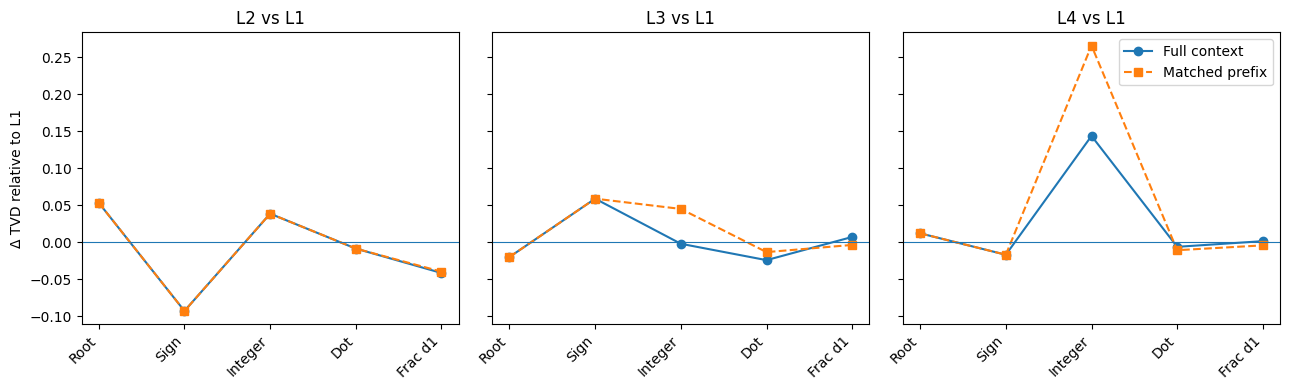

In [74]:
laplace_effect_plot = (
    laplace_full[
        [
            "contrast_id",
            "model_id",
            "analysis_stage",
            "delta_full",
        ]
    ]
    .merge(
        laplace_matched[
            [
                "contrast_id",
                "model_id",
                "analysis_stage",
                "delta_matched",
            ]
        ],
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="left",
    )
)

laplace_plot_summary = (
    laplace_effect_plot
    .groupby(
        ["contrast_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        full=("delta_full", "mean"),
        matched=("delta_matched", "mean"),
    )
)

contrast_order = [
    "L2_vs_L1",
    "L3_vs_L1",
    "L4_vs_L1",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
    sharey=True,
)

for ax, contrast_id in zip(
    axes,
    contrast_order,
):
    temp = (
        laplace_plot_summary[
            laplace_plot_summary["contrast_id"]
            == contrast_id
        ]
        .set_index("analysis_stage")
        .reindex(PRIMARY_STAGE_ORDER)
    )

    x = np.arange(len(PRIMARY_STAGE_ORDER))

    ax.plot(
        x,
        temp["full"],
        marker="o",
        label="Full context",
    )

    ax.plot(
        x,
        temp["matched"],
        marker="s",
        linestyle="--",
        label="Matched prefix",
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "Root",
            "Sign",
            "Integer",
            "Dot",
            "Frac d1",
        ],
        rotation=45,
        ha="right",
    )

    ax.set_title(
        contrast_id.replace("_vs_", " vs ")
    )

axes[0].set_ylabel(
    "Δ TVD relative to L1"
)

axes[-1].legend()

plt.tight_layout()
plt.show()

### Mechanistic follow-up candidate

Extreme-scale integer effects should later be examined at the token/symbol level for:

- Normal N6 versus N1 at prefixes $-1$ and $1$.
- Laplace L4 versus L1 at prefixes $-1$ and $1$.

This analysis is deferred until the primary family-level parameter effects are complete.

## 07.14 Interpretation

I would record the following.

### Narrower scale: L2

The narrower Laplace condition does not produce a general improvement or deterioration across stages. Its clearest consistent change is improved sign-stage alignment, with a matched mean TVD reduction of approximately 0.093 in five of six conditions. Fractional alignment also improves modestly on average, while the apparent integer increase is largely driven by one model/protocol condition.

### Moderate widening: L3

Increasing scale to 2 produces little change in the full-context stage averages. However, matched-prefix analysis identifies a modest integer-stage deterioration of approximately +0.045 at the shared prefixes −1 and 1, occurring in five of six conditions. The near-zero full-context effect therefore masks a local same-prefix sensitivity.

### Extreme widening: L4

Increasing scale to 10 produces a substantially larger and highly localised integer-stage effect. Mean integer TVD increases by approximately +0.144 in the full-context comparison and +0.266 at the shared integer prefixes. Five of six conditions show deterioration, and both −1 and 1 contribute for most models. Other stages remain much closer to the canonical condition on average.

### Result statement

Laplace scale changes produced stage-specific rather than uniform changes in alignment. Relative to $\mathrm{Laplace}(0,1)$, the narrower $\mathrm{Laplace}(0,0.5)$ condition reduced matched sign-stage TVD by approximately $0.093$, with lower TVD in five of six model/protocol conditions; matched Fraction depth-1 TVD was also lower by approximately $0.040$. The apparent mean integer-stage increase of approximately $0.039$ under L2 had a median near zero and was largely driven by one condition.

For $\mathrm{Laplace}(0,2)$, the full-context integer-stage effect was approximately zero, whereas the matched-prefix effect at $-1$ and $1$ was approximately $+0.045$, with higher TVD in five of six conditions. Under the extreme $\mathrm{Laplace}(0,10)$ condition, integer-stage TVD increased by approximately $+0.144$ in the full-context comparison and $+0.266$ in the matched-prefix comparison. Five of six model/protocol conditions showed higher matched integer-stage TVD, and the deterioration occurred at both shared integer prefixes for most conditions. ROOT, dot, and Fraction depth-1 effects under the wider-scale conditions remained comparatively small on average.

### Result conclusion

Laplace alignment is sensitive to scale, but the effect depends strongly on numerical stage and scale magnitude. Moderate widening produces a small same-prefix deterioration at the integer stage that is hidden by the full-context stage average, while extreme widening produces a substantially larger integer-stage deterioration that remains when the comparison is restricted to identical prefixes. The stronger matched than full-context effect under the extreme scale shows that the result is not explained solely by the introduction of new large-magnitude numerical contexts. Conversely, narrowing the distribution produces a relatively consistent improvement at the sign stage rather than a general improvement across all stages. Overall, Laplace scale sensitivity is localised rather than global and becomes especially pronounced at the integer stage under extreme spread.

## 07.17 — Laplace family conclusion

Changing Laplace scale does not shift alignment uniformly across the numerical representation. The strongest deterioration emerges at the integer stage as the scale becomes large. Matched-prefix analysis shows a modest deterioration at scale $2$ and a substantially larger deterioration at scale $10$ at the same prefixes $-1$ and $1$, demonstrating genuine local sensitivity rather than an effect caused only by changed prefix coverage. The narrower scale instead produces improved sign-stage alignment in most evaluated model/protocol conditions. Thus, Laplace scale affects different numerical stages differently, with extreme spread producing the clearest and most robust same-prefix alignment failure.

# 08 — RQ3B.3 Exponential: Rate Sensitivity

## Research question

How does changing the rate of an Exponential target distribution alter next-symbol probabilistic alignment, and at which numerical stages do these effects occur?

The canonical reference is:

$$
E1 = \mathrm{Exponential}(\lambda=1).
$$

The evaluated rate conditions are:

- E2: $\lambda=0.5$
- E1: $\lambda=1$
- E3: $\lambda=2$
- E4: $\lambda=0.1$

For an Exponential distribution:

$$
\mathbb{E}[X] = \frac{1}{\lambda}
$$

and

$$
\mathrm{SD}(X) = \frac{1}{\lambda}.
$$

Therefore, decreasing the rate increases the numerical scale of the target, while increasing the rate concentrates probability more strongly near zero.

## 08.1 — Pre-analysis expectation

Changing the Exponential rate changes the characteristic numerical scale of the distribution while preserving non-negative support.

Therefore:

1. No sign branch is introduced by the parameter manipulation.
2. E2 ($\lambda=0.5$) produces a broader target than E1.
3. E3 ($\lambda=2$) produces a more concentrated target than E1.
4. E4 ($\lambda=0.1$) is an extreme broad-scale condition and introduces larger-magnitude numerical contexts.
5. E1, E2, and E3 use identical primary prefix sets, allowing exact same-prefix comparisons without a coverage confound.
6. E4 contains both the original E1 contexts and additional large-magnitude contexts, so both full-context and matched-prefix effects are required.
7. No directional prediction is made about whether increasing or decreasing rate improves alignment.

In [75]:
exponential_primary = prefix[
    (prefix["distribution"] == "exponential")
    & prefix["primary_alignment_row"]
].copy()

exponential_stage = compute_stage_means(
    exponential_primary
)

EXPONENTIAL_RATE = ["E2", "E3", "E4"]

exponential_full = pd.concat(
    [
        compute_full_contrast(
            exponential_stage,
            target_id=parameter_id,
            reference_id="E1",
        )
        for parameter_id in EXPONENTIAL_RATE
    ],
    ignore_index=True,
)

exponential_matched_outputs = [
    compute_matched_contrast(
        exponential_primary,
        target_id=parameter_id,
        reference_id="E1",
    )
    for parameter_id in EXPONENTIAL_RATE
]

exponential_matched = pd.concat(
    [x[0] for x in exponential_matched_outputs],
    ignore_index=True,
)

In [76]:
exponential_full_summary = summarise_across_models(
    exponential_full,
    "delta_full",
)

exponential_matched_summary = summarise_across_models(
    exponential_matched,
    "delta_matched",
)

exponential_common_counts = (
    exponential_matched
    .groupby(
        ["contrast_id", "analysis_stage"]
    )["n_common"]
    .first()
    .reset_index()
)

exponential_matched_summary = (
    exponential_matched_summary
    .merge(
        exponential_common_counts,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)

stage_order_map = {
    stage: i
    for i, stage in enumerate(PRIMARY_STAGE_ORDER)
}

for df in [
    exponential_full_summary,
    exponential_matched_summary,
]:
    df["stage_order"] = (
        df["analysis_stage"].map(stage_order_map)
    )
print("Full context summary for exponential contrasts:")
display(
    exponential_full_summary
    .sort_values(["contrast_id", "stage_order"])
    .drop(columns="stage_order")
    .round(4)
)
print("Matched prefix summary for exponential contrasts:")
display(
    exponential_matched_summary
    .sort_values(["contrast_id", "stage_order"])
    .drop(columns="stage_order")
    .round(4)
)

Full context summary for exponential contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
3,E2_vs_E1,start,-0.0622,-0.1008,-0.2375,0.2366,6,2,4
2,E2_vs_E1,integer,0.0368,0.0137,-0.0242,0.1077,6,5,1
0,E2_vs_E1,dot,0.0261,0.0475,-0.0773,0.1544,6,4,2
1,E2_vs_E1,fraction_d1,-0.0261,-0.0112,-0.1355,0.0610,6,3,3
7,E3_vs_E1,start,0.1290,0.2109,-0.2323,0.3636,6,4,2
6,E3_vs_E1,integer,0.0075,-0.0001,-0.2014,0.2382,6,2,4
4,E3_vs_E1,dot,0.0460,0.0438,-0.0861,0.1716,6,3,3
5,E3_vs_E1,fraction_d1,0.0322,0.0155,-0.0878,0.1965,6,3,3
11,E4_vs_E1,start,0.0211,-0.0440,-0.3957,0.5320,6,2,4
10,E4_vs_E1,integer,0.3106,0.3127,0.0987,0.5819,6,6,0


Matched prefix summary for exponential contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
3,E2_vs_E1,start,-0.0622,-0.1008,-0.2375,0.2366,6,2,4,1
2,E2_vs_E1,integer,0.0368,0.0137,-0.0242,0.1077,6,5,1,2
0,E2_vs_E1,dot,0.0261,0.0475,-0.0773,0.1544,6,4,2,3
1,E2_vs_E1,fraction_d1,-0.0261,-0.0112,-0.1355,0.0610,6,3,3,3
7,E3_vs_E1,start,0.1290,0.2109,-0.2323,0.3636,6,4,2,1
6,E3_vs_E1,integer,0.0075,-0.0001,-0.2014,0.2382,6,2,4,2
4,E3_vs_E1,dot,0.0460,0.0438,-0.0861,0.1716,6,3,3,3
5,E3_vs_E1,fraction_d1,0.0322,0.0155,-0.0878,0.1965,6,3,3,3
11,E4_vs_E1,start,0.0211,-0.0440,-0.3957,0.5320,6,2,4,1
10,E4_vs_E1,integer,0.4226,0.5577,-0.0540,0.6913,6,5,1,2


E4 produces substantially higher integer-stage TVD in all six conditions in the full-context comparison.

The moderate reduction in rate produces a small but reasonably consistent integer-stage deterioration, while the other stages do not move uniformly.

Because prefix coverage is identical, this integer effect is genuinely a same-context parameter sensitivity.

In [77]:
for parameter_id in ["E1", "E2", "E3", "E4"]:

    print(f"\n{parameter_id}")

    temp = exponential_primary[
        exponential_primary["parameter_id"]
        == parameter_id
    ]

    for stage in PRIMARY_STAGE_ORDER:
        values = sorted(
            temp.loc[
                temp["analysis_stage"] == stage,
                "prefix",
            ].unique()
        )

        print(stage, values)


E1
start ['ROOT']
sign []
integer ['1', '2']
dot ['0.', '1.', '2.']
fraction_d1 ['0.1', '0.5', '1.1']

E2
start ['ROOT']
sign []
integer ['1', '2']
dot ['0.', '1.', '2.']
fraction_d1 ['0.1', '0.5', '1.1']

E3
start ['ROOT']
sign []
integer ['1', '2']
dot ['0.', '1.', '2.']
fraction_d1 ['0.1', '0.5', '1.1']

E4
start ['ROOT']
sign []
integer ['1', '10', '2', '20']
dot ['0.', '1.', '10.', '2.', '20.']
fraction_d1 ['0.1', '0.5', '1.1', '10.0']


In [78]:
e3_full = compute_full_contrast(
    exponential_stage,
    target_id="E3",
    reference_id="E1",
)

display(
    e3_full[
        [
            "model_id",
            "analysis_stage",
            "target_mean",
            "reference_mean",
            "delta_full",
        ]
    ]
    .sort_values(
        ["analysis_stage", "model_id"]
    )
    .round(4)
)

,model_id,analysis_stage,target_mean,reference_mean,delta_full
0,S1,dot,0.1998,0.0939,0.1059
4,S2,dot,0.5352,0.3636,0.1716
8,S3,dot,0.8252,0.6868,0.1384
12,S4,dot,0.1151,0.2012,-0.0861
16,S5,dot,0.7277,0.7629,-0.0352
20,S6,dot,0.3376,0.3560,-0.0184
1,S1,fraction_d1,0.2065,0.1743,0.0322
5,S2,fraction_d1,0.4789,0.2824,0.1965
9,S3,fraction_d1,0.8021,0.7268,0.0754
13,S4,fraction_d1,0.0359,0.0371,-0.0012


In [79]:
e1_prefixes = set(
    exponential_primary.loc[
        exponential_primary["parameter_id"] == "E1",
        ["analysis_stage", "prefix"]
    ]
    .itertuples(index=False, name=None)
)

e3_prefixes = set(
    exponential_primary.loc[
        exponential_primary["parameter_id"] == "E3",
        ["analysis_stage", "prefix"]
    ]
    .itertuples(index=False, name=None)
)

print("E1 primary prefixes:", len(e1_prefixes))
print("E3 primary prefixes:", len(e3_prefixes))
print("Identical prefix sets:", e1_prefixes == e3_prefixes)
print("E1 only:", e1_prefixes - e3_prefixes)
print("E3 only:", e3_prefixes - e1_prefixes)

E1 primary prefixes: 9
E3 primary prefixes: 9
Identical prefix sets: True
E1 only: set()
E3 only: set()


In [80]:
e3_summary = (
    e3_full
    .groupby("analysis_stage")["delta_full"]
    .agg(
        mean_effect="mean",
        median_effect="median",
        min_effect="min",
        max_effect="max",
        n_models="count",
        n_worse=lambda x: (x > 0).sum(),
        n_better=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

e3_summary["stage_order"] = (
    e3_summary["analysis_stage"]
    .map({
        stage: i
        for i, stage in enumerate(
            ["start", "integer", "dot", "fraction_d1"]
        )
    })
)

e3_summary = (
    e3_summary
    .sort_values("stage_order")
    .drop(columns="stage_order")
)

display(e3_summary.round(4))

,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
3,start,0.1290,0.2109,-0.2323,0.3636,6,4,2
2,integer,0.0075,-0.0001,-0.2014,0.2382,6,2,4
0,dot,0.0460,0.0438,-0.0861,0.1716,6,3,3
1,fraction_d1,0.0322,0.0155,-0.0878,0.1965,6,3,3


In [81]:
e3_root_by_model = (
    e3_full[
        e3_full["analysis_stage"] == "start"
    ][
        [
            "model_id",
            "reference_mean",
            "target_mean",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(e3_root_by_model.round(4))

,model_id,reference_mean,target_mean,delta_full
3,S1,0.1561,0.3673,0.2111
7,S2,0.5453,0.7783,0.2330
11,S3,0.9144,0.9025,-0.0119
15,S4,0.5053,0.7158,0.2106
19,S5,0.4448,0.8085,0.3636
23,S6,0.3672,0.1349,-0.2323


In [82]:
e3_integer_by_model = (
    e3_full[
        e3_full["analysis_stage"] == "integer"
    ][
        [
            "model_id",
            "reference_mean",
            "target_mean",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(e3_integer_by_model.round(4))

,model_id,reference_mean,target_mean,delta_full
2,S1,0.0454,0.0536,0.0083
6,S2,0.0001,0.0000,-0.0001
10,S3,0.0001,0.0000,-0.0001
14,S4,0.3836,0.1822,-0.2014
18,S5,0.0782,0.3164,0.2382
22,S6,0.0001,0.0000,-0.0001


In [83]:
_, e3_e1_pairs = compute_matched_contrast(
    exponential_primary,
    target_id="E3",
    reference_id="E1",
)

e3_integer_prefix_effects = (
    e3_e1_pairs[
        e3_e1_pairs["analysis_stage"] == "integer"
    ]
    .pivot(
        index="model_id",
        columns="prefix",
        values="delta_pair",
    )
    .reindex(MODEL_ORDER)
)

display(e3_integer_prefix_effects.round(4))

prefix,1,2
model_id,,
S1,0.0179,-0.0013
S2,-0.0002,0.0000
S3,-0.0002,-0.0000
S4,0.0447,-0.4476
S5,0.4764,0.0000
S6,-0.0001,-0.0001


In [84]:
e4_integer_by_model = (
    exponential_matched[
        (exponential_matched["contrast_id"] == "E4_vs_E1")
        & (
            exponential_matched["analysis_stage"]
            == "integer"
        )
    ][
        [
            "model_id",
            "delta_matched",
            "n_common",
        ]
    ]
    .sort_values("model_id")
)

display(e4_integer_by_model.round(4))

,model_id,delta_matched,n_common
50,S1,0.1568,2
54,S2,0.6185,2
58,S3,0.6913,2
62,S4,-0.0540,2
66,S5,0.4969,2
70,S6,0.6259,2


In [85]:
_, e4_e1_pairs = compute_matched_contrast(
    exponential_primary,
    target_id="E4",
    reference_id="E1",
)

e4_integer_prefix_effects = (
    e4_e1_pairs[
        e4_e1_pairs["analysis_stage"]
        == "integer"
    ]
    .pivot(
        index="model_id",
        columns="prefix",
        values="delta_pair",
    )
    .reindex(MODEL_ORDER)
)

display(
    e4_integer_prefix_effects.round(4)
)

prefix,1,2
model_id,,
S1,0.1997,0.1140
S2,0.7139,0.5232
S3,0.8593,0.5234
S4,0.1846,-0.2927
S5,0.4705,0.5233
S6,0.7290,0.5228


In [86]:
e4_integer_absolute = (
    exponential_primary[
        (exponential_primary["parameter_id"] == "E4")
        & (
            exponential_primary["analysis_stage"]
            == "integer"
        )
    ]
    .groupby("prefix")
    ["tv_analytic_lm"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

display(e4_integer_absolute.round(4))

,mean,median,min,max
prefix,,,,
1,0.5961,0.6705,0.2435,0.8595
10,0.2254,0.0295,0.0005,0.8021
2,0.4182,0.5230,0.1609,0.5234
20,0.3410,0.0628,0.0000,0.9996


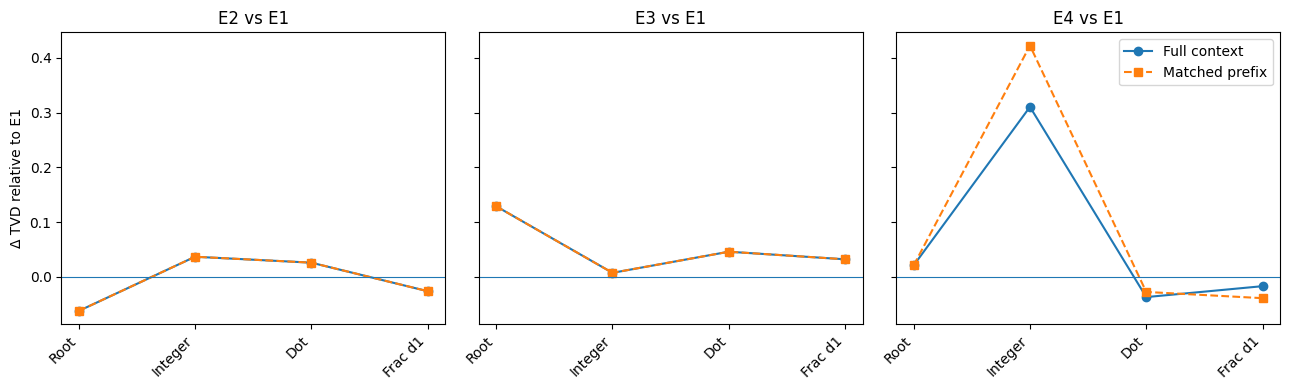

In [87]:
exponential_effect_plot = (
    exponential_full[
        [
            "contrast_id",
            "model_id",
            "analysis_stage",
            "delta_full",
        ]
    ]
    .merge(
        exponential_matched[
            [
                "contrast_id",
                "model_id",
                "analysis_stage",
                "delta_matched",
            ]
        ],
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="left",
    )
)

exponential_plot_summary = (
    exponential_effect_plot
    .groupby(
        ["contrast_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        full=("delta_full", "mean"),
        matched=("delta_matched", "mean"),
    )
)

contrast_order = [
    "E2_vs_E1",
    "E3_vs_E1",
    "E4_vs_E1",
]

exponential_stage_order = [
    "start",
    "integer",
    "dot",
    "fraction_d1",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
    sharey=True,
)

for ax, contrast_id in zip(
    axes,
    contrast_order,
):
    temp = (
        exponential_plot_summary[
            exponential_plot_summary["contrast_id"]
            == contrast_id
        ]
        .set_index("analysis_stage")
        .reindex(exponential_stage_order)
    )

    x = np.arange(
        len(exponential_stage_order)
    )

    ax.plot(
        x,
        temp["full"],
        marker="o",
        label="Full context",
    )

    ax.plot(
        x,
        temp["matched"],
        marker="s",
        linestyle="--",
        label="Matched prefix",
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "Root",
            "Integer",
            "Dot",
            "Frac d1",
        ],
        rotation=45,
        ha="right",
    )

    ax.set_title(
        contrast_id.replace("_vs_", " vs ")
    )

axes[0].set_ylabel(
    "Δ TVD relative to E1"
)

axes[-1].legend()

plt.tight_layout()
plt.show()

### E2 — lower rate, moderate increase in scale

The effect is modest and stage-specific. Integer-stage TVD increases by approximately +0.037, with five of six conditions worsening. Because E2 and E1 use identical prefixes, this is genuine same-prefix sensitivity. Other stages show smaller and less directionally stable changes.

### E3 — higher rate, more concentration near zero

The clearest average change occurs at ROOT, where TVD increases by approximately +0.129, with a median increase of +0.211. However, the effect is model/protocol dependent: four conditions worsen while two do not. Integer, dot, and fraction effects are comparatively small and inconsistent.

### E4 — extreme lower rate

The extreme broad-scale condition produces a pronounced integer-stage deterioration. The full-context mean increase is approximately +0.311, with all six conditions worsening. Restricting the comparison to the shared prefixes 1 and 2 increases the effect to approximately +0.423, with a median of +0.558. At prefix 1, all six conditions worsen; at prefix 2, five of six worsen.

The additional contexts 10 and 20 have lower average TVD than the shared contexts and therefore partially mask, rather than create, the same-prefix deterioration.

### Result statement

Exponential rate changes produced stage-specific changes in probabilistic alignment. E2 ($\lambda=0.5$) and E3 ($\lambda=2$) used exactly the same primary prefixes as the canonical E1 ($\lambda=1$) condition, so their full-context and matched-prefix effects were identical. Under E2, integer-stage TVD increased by approximately $+0.037$, with higher TVD in five of six model/protocol conditions, while effects at ROOT, dot, and Fraction depth 1 were smaller or less directionally consistent. Under E3, the largest mean change occurred at ROOT, where TVD increased by approximately $+0.129$ with a median increase of approximately $+0.211$, although only four of six model/protocol conditions showed higher TVD.

The extreme E4 condition ($\lambda=0.1$) produced a much larger integer-stage effect. Mean integer TVD increased by approximately $+0.311$ in the full-context comparison, with higher TVD in all six model/protocol conditions. At the two integer prefixes shared with E1, $1$ and $2$, the mean matched-prefix increase was approximately $+0.423$ and the median increase was approximately $+0.558$, with five of six conditions worsening overall. All six conditions showed higher TVD at prefix $1$, and five of six showed higher TVD at prefix $2$. The additional E4 integer prefixes $10$ and $20$ had lower average TVD than the shared prefixes, so their inclusion reduced rather than generated the full-context integer-stage effect.

### Result conclusion

Exponential alignment is sensitive to rate, but the response is neither uniform across stages nor symmetric around the canonical rate. Moderate lowering of the rate produces a small same-prefix deterioration at the integer stage, whereas increasing the rate primarily changes ROOT alignment in a model-dependent manner. The strongest effect occurs under the extreme low-rate condition, where integer-stage alignment deteriorates substantially.

Matched-prefix analysis shows that the extreme-rate deterioration is not explained by the introduction of larger numerical contexts. Instead, alignment worsens strongly at the same integer prefixes already present under the canonical distribution, while the newly introduced large-magnitude prefixes partially dilute this effect in the full-context stage average. Thus, extreme Exponential scale produces a pronounced local failure in adapting next-symbol probabilities to changed target mathematics.

### Result conclusion

Exponential alignment is sensitive to rate, but the response is neither uniform across stages nor symmetric around the canonical rate. Moderate lowering of the rate produces a small same-prefix deterioration at the integer stage, whereas increasing the rate primarily changes ROOT alignment in a model-dependent manner. The strongest effect occurs under the extreme low-rate condition, where integer-stage alignment deteriorates substantially.

Matched-prefix analysis shows that the extreme-rate deterioration is not explained by the introduction of larger numerical contexts. Instead, alignment worsens strongly at the same integer prefixes already present under the canonical distribution, while the newly introduced large-magnitude prefixes partially dilute this effect in the full-context stage average. Thus, extreme Exponential scale produces a pronounced local failure in adapting next-symbol probabilities to changed target mathematics.

### Mechanistic follow-up candidates

The following extreme-scale effects are retained for later token-level analysis:

- Normal N6 versus N1 at integer prefixes $-1$ and $1$.
- Laplace L4 versus L1 at integer prefixes $-1$ and $1$.
- Exponential E4 versus E1 at integer prefixes $1$ and $2$.

These cases are selected because they show substantial matched-prefix integer-stage deterioration and therefore permit investigation of whether similar next-symbol probability allocation errors occur across different distribution families.

# 09 — RQ3B.4 Uniform: Support Geometry

## Research question

How does changing the support of a Uniform target distribution alter next-symbol probabilistic alignment and the numerical stages at which alignment is evaluated?

The canonical reference is:

$$
U1 = \mathrm{Uniform}[0,1].
$$

The evaluated support conditions are:

- U1: $[0,1]$
- U2: $[-1,1]$
- U3: $[0,2]$
- U4: $[0,100]$

The manipulations test different aspects of support geometry:

1. U3 versus U1 increases positive support width.
2. U4 versus U1 produces an extreme increase in positive support width.
3. U2 introduces negative support and an explicit sign branch.
4. U2 versus U3 provides a same-width control: both supports have width 2, but one crosses zero and the other remains non-negative.

Because changing support also changes which numerical prefixes are relevant, exact-prefix and full-context comparisons must be distinguished carefully.

## 09.1 — Pre-analysis expectation

Changing Uniform support changes both the analytical next-symbol probabilities and, in some cases, the numerical representation itself.

Therefore:

1. Expanding support can introduce informative integer decisions that are absent for $[0,1]$.
2. Crossing zero introduces an explicit negative-sign branch.
3. Later numerical prefixes need not overlap across support settings.
4. ROOT remains directly comparable across all Uniform conditions.
5. U2 and U3 have the same support width but differ in location and sign structure, providing a useful control for separating width from support placement.
6. U4 shares essentially no informative integer, dot, or Fraction depth-1 prefixes with U1, so later-stage U4-versus-U1 differences cannot be interpreted as same-prefix effects.
7. No directional prediction is made about whether wider or shifted support improves or worsens alignment.

In [88]:
uniform_primary = prefix[
    (prefix["distribution"] == "uniform")
    & prefix["primary_alignment_row"]
].copy()

uniform_stage = compute_stage_means(
    uniform_primary
)

UNIFORM_SUPPORT = ["U2", "U3", "U4"]

uniform_full = pd.concat(
    [
        compute_full_contrast(
            uniform_stage,
            target_id=parameter_id,
            reference_id="U1",
        )
        for parameter_id in UNIFORM_SUPPORT
    ],
    ignore_index=True,
)

uniform_matched_outputs = [
    compute_matched_contrast(
        uniform_primary,
        target_id=parameter_id,
        reference_id="U1",
    )
    for parameter_id in UNIFORM_SUPPORT
]

uniform_matched = pd.concat(
    [x[0] for x in uniform_matched_outputs],
    ignore_index=True,
)

In [89]:
uniform_full_summary = summarise_across_models(
    uniform_full,
    "delta_full",
)

uniform_matched_summary = summarise_across_models(
    uniform_matched,
    "delta_matched",
)

uniform_common_counts = (
    uniform_matched
    .groupby(
        ["contrast_id", "analysis_stage"]
    )["n_common"]
    .first()
    .reset_index()
)

uniform_matched_summary = (
    uniform_matched_summary
    .merge(
        uniform_common_counts,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)
print("Full context summary for uniform contrasts:")
display(
    uniform_full_summary
    .sort_values(["contrast_id", "analysis_stage"])
    .round(4)
)
print("Matched prefix summary for uniform contrasts:")
display(
    uniform_matched_summary
    .sort_values(["contrast_id", "analysis_stage"])
    .round(4)
)

Full context summary for uniform contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,U2_vs_U1,dot,-0.0089,-0.0192,-0.0560,0.0581,6,2,4
1,U2_vs_U1,fraction_d1,-0.0141,-0.0232,-0.1121,0.0869,6,3,3
2,U2_vs_U1,start,0.1239,0.0184,-0.1211,0.4982,6,3,3
3,U3_vs_U1,dot,0.0864,0.0954,-0.1063,0.2987,6,4,2
4,U3_vs_U1,fraction_d1,0.0735,0.0834,-0.0826,0.2423,6,4,2
5,U3_vs_U1,start,-0.0358,-0.0073,-0.4728,0.4995,6,3,3
6,U4_vs_U1,dot,0.0102,0.0210,-0.1312,0.1615,6,4,2
7,U4_vs_U1,fraction_d1,-0.0641,-0.0286,-0.2533,0.0896,6,1,5
8,U4_vs_U1,start,0.1589,0.1259,-0.2658,0.8828,6,4,2


Matched prefix summary for uniform contrasts:


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
0,U2_vs_U1,dot,0.0222,0.0217,-0.0293,0.0802,6,3,3,1
1,U2_vs_U1,fraction_d1,-0.0435,-0.0350,-0.2994,0.1202,6,2,4,1
2,U2_vs_U1,start,0.1239,0.0184,-0.1211,0.4982,6,3,3,1
3,U3_vs_U1,dot,0.0926,0.0782,-0.0693,0.2984,6,4,2,1
4,U3_vs_U1,fraction_d1,0.0066,-0.0183,-0.1021,0.1992,6,2,4,1
5,U3_vs_U1,start,-0.0358,-0.0073,-0.4728,0.4995,6,3,3,1
6,U4_vs_U1,start,0.1589,0.1259,-0.2658,0.8828,6,4,2,1


In [90]:
for parameter_id in ["U1", "U2", "U3", "U4"]:

    print(f"\n{parameter_id}")

    temp = uniform_primary[
        uniform_primary["parameter_id"]
        == parameter_id
    ]

    for stage in PRIMARY_STAGE_ORDER:

        values = sorted(
            temp.loc[
                temp["analysis_stage"] == stage,
                "prefix",
            ].unique()
        )

        print(stage, values)


U1
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']

U2
start ['ROOT']
sign ['-']
integer []
dot ['-0.', '0.']
fraction_d1 ['-0.5', '0.0', '0.5']

U3
start ['ROOT']
sign []
integer ['1']
dot ['0.', '1.']
fraction_d1 ['0.5', '1.0', '1.5']

U4
start ['ROOT']
sign []
integer ['1', '10', '5', '50']
dot ['1.', '10.', '5.', '50.']
fraction_d1 ['1.5', '50.5']


In [91]:
uniform_absolute = (
    uniform_stage
    .groupby(
        ["parameter_id", "analysis_stage"]
    )["mean_value"]
    .agg(
        mean_tvd="mean",
        median_tvd="median",
        min_tvd="min",
        max_tvd="max",
        n_models="count",
    )
    .reset_index()
)

display(
    uniform_absolute
    .sort_values(
        ["parameter_id", "analysis_stage"]
    )
    .round(4)
)

,parameter_id,analysis_stage,mean_tvd,median_tvd,min_tvd,max_tvd,n_models
0,U1,dot,0.4406,0.3746,0.0851,0.8989,6
1,U1,fraction_d1,0.4657,0.5129,0.1290,0.8190,6
2,U1,start,0.2886,0.1698,0.0005,0.8072,6
3,U2,dot,0.4317,0.3347,0.0635,0.8821,6
4,U2,fraction_d1,0.4516,0.4196,0.1340,0.8804,6
5,U2,sign,0.3271,0.0342,0.0005,0.9993,6
6,U2,start,0.4124,0.4614,0.1227,0.6861,6
7,U3,dot,0.5270,0.5624,0.1211,0.8964,6
8,U3,fraction_d1,0.5392,0.5912,0.1218,0.8855,6
9,U3,integer,0.0946,0.0047,0.0000,0.3052,6


In [92]:
u2_matched = uniform_matched[
    uniform_matched["contrast_id"]
    == "U2_vs_U1"
].copy()

display(
    u2_matched[
        [
            "model_id",
            "analysis_stage",
            "delta_matched",
            "n_common",
        ]
    ]
    .sort_values(
        ["analysis_stage", "model_id"]
    )
    .round(4)
)

,model_id,analysis_stage,delta_matched,n_common
0,S1,dot,0.0597,1
3,S2,dot,0.0802,1
6,S3,dot,0.0480,1
9,S4,dot,-0.0206,1
12,S5,dot,-0.0046,1
15,S6,dot,-0.0293,1
1,S1,fraction_d1,0.0408,1
4,S2,fraction_d1,0.1202,1
7,S3,fraction_d1,-0.0258,1
10,S4,fraction_d1,-0.0442,1


In [93]:
u2_root_by_model = (
    uniform_full[
        (uniform_full["contrast_id"] == "U2_vs_U1")
        & (uniform_full["analysis_stage"] == "start")
    ][
        [
            "model_id",
            "reference_mean",
            "target_mean",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(u2_root_by_model.round(4))

,model_id,reference_mean,target_mean,delta_full
2,S1,0.3354,0.2441,-0.0912
5,S2,0.0041,0.4246,0.4204
8,S3,0.0005,0.4987,0.4982
11,S4,0.8072,0.6861,-0.1211
14,S5,0.5836,0.4982,-0.0854
17,S6,0.0005,0.1227,0.1222


Crossing zero alters ROOT alignment substantially for some conditions, but there is no shared direction across the evaluated models/protocols.

In [94]:
u2_sign_by_model = (
    uniform_stage[
        (uniform_stage["parameter_id"] == "U2")
        & (uniform_stage["analysis_stage"] == "sign")
    ][
        [
            "model_id",
            "mean_value",
            "n_prefixes",
        ]
    ]
    .sort_values("model_id")
)

display(u2_sign_by_model.round(4))

,model_id,mean_value,n_prefixes
20,S1,0.0679,1
24,S2,0.0005,1
28,S3,0.0005,1
32,S4,0.8938,1
36,S5,0.9993,1
40,S6,0.0005,1


In [95]:
u3_matched = uniform_matched[
    uniform_matched["contrast_id"]
    == "U3_vs_U1"
].copy()

display(
    u3_matched[
        [
            "model_id",
            "analysis_stage",
            "delta_matched",
            "n_common",
        ]
    ]
    .sort_values(
        ["analysis_stage", "model_id"]
    )
    .round(4)
)

,model_id,analysis_stage,delta_matched,n_common
18,S1,dot,-0.0693,1
21,S2,dot,0.2984,1
24,S3,dot,0.1121,1
27,S4,dot,0.0444,1
30,S5,dot,-0.0003,1
33,S6,dot,0.1703,1
19,S1,fraction_d1,-0.0328,1
22,S2,fraction_d1,0.1992,1
25,S3,fraction_d1,-0.0323,1
28,S4,fraction_d1,0.0122,1


In [96]:
u3_dot_by_model = (
    uniform_matched[
        (uniform_matched["contrast_id"] == "U3_vs_U1")
        & (uniform_matched["analysis_stage"] == "dot")
    ][
        [
            "model_id",
            "delta_matched",
        ]
    ]
    .sort_values("model_id")
)

display(u3_dot_by_model.round(4))

,model_id,delta_matched
18,S1,-0.0693
21,S2,0.2984
24,S3,0.1121
27,S4,0.0444
30,S5,-0.0003
33,S6,0.1703


In [97]:
u4_root_by_model = (
    uniform_full[
        (uniform_full["contrast_id"] == "U4_vs_U1")
        & (uniform_full["analysis_stage"] == "start")
    ][
        [
            "model_id",
            "reference_mean",
            "target_mean",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(u4_root_by_model.round(4))

,model_id,reference_mean,target_mean,delta_full
38,S1,0.3354,0.2128,-0.1226
41,S2,0.0041,0.0885,0.0843
44,S3,0.0005,0.8833,0.8828
47,S4,0.8072,0.5414,-0.2658
50,S5,0.5836,0.7512,0.1675
53,S6,0.0005,0.2077,0.2072


In [98]:
u4_integer_by_model = (
    uniform_stage[
        (uniform_stage["parameter_id"] == "U4")
        & (uniform_stage["analysis_stage"] == "integer")
    ][
        [
            "model_id",
            "mean_value",
            "n_prefixes",
        ]
    ]
    .sort_values("model_id")
)

display(u4_integer_by_model.round(4))

,model_id,mean_value,n_prefixes
68,S1,0.1828,4
72,S2,0.2242,4
76,S3,0.3441,4
80,S4,0.4823,4
84,S5,0.8954,4
88,S6,0.2279,4


In [99]:
u4_integer_prefixes = (
    uniform_primary[
        (uniform_primary["parameter_id"] == "U4")
        & (
            uniform_primary["analysis_stage"]
            == "integer"
        )
    ]
    .groupby("prefix")
    ["tv_analytic_lm"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

display(
    u4_integer_prefixes.round(4)
)

,mean,median,min,max
prefix,,,,
1,0.5195,0.5662,0.1936,0.7197
10,0.3627,0.2069,0.0005,0.9987
5,0.4893,0.4401,0.1125,0.9090
50,0.1996,0.0075,0.0000,0.9996


In [100]:
u2_u3_full = compute_full_contrast(
    uniform_stage,
    target_id="U2",
    reference_id="U3",
)

u2_u3_matched, u2_u3_pairs = (
    compute_matched_contrast(
        uniform_primary,
        target_id="U2",
        reference_id="U3",
    )
)

u2_u3_full_summary = summarise_across_models(
    u2_u3_full,
    "delta_full",
)

u2_u3_matched_summary = summarise_across_models(
    u2_u3_matched,
    "delta_matched",
)

u2_u3_common = (
    u2_u3_matched
    .groupby(
        ["contrast_id", "analysis_stage"]
    )["n_common"]
    .first()
    .reset_index()
)

u2_u3_matched_summary = (
    u2_u3_matched_summary
    .merge(
        u2_u3_common,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)

display(u2_u3_full_summary.round(4))
display(u2_u3_matched_summary.round(4))

,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,U2_vs_U3,dot,-0.0953,-0.0943,-0.3224,0.0894,6,2,4
1,U2_vs_U3,fraction_d1,-0.0876,-0.0214,-0.3168,0.0122,6,1,5
2,U2_vs_U3,start,0.1596,0.1752,-0.1084,0.3720,6,3,3


,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
0,U2_vs_U3,dot,-0.0704,-0.0645,-0.2182,0.1290,6,1,5,1
1,U2_vs_U3,fraction_d1,-0.0502,-0.0250,-0.2950,0.0736,6,3,3,1
2,U2_vs_U3,start,0.1596,0.1752,-0.1084,0.3720,6,3,3,1


In [101]:
u2_u3_dot = (
    u2_u3_matched[
        u2_u3_matched["analysis_stage"]
        == "dot"
    ][
        [
            "model_id",
            "delta_matched",
        ]
    ]
    .sort_values("model_id")
)

display(u2_u3_dot.round(4))

,model_id,delta_matched
0,S1,0.1290
3,S2,-0.2182
6,S3,-0.0641
9,S4,-0.0650
12,S5,-0.0043
15,S6,-0.1996


With support width held fixed at 2, alignment at the shared dot context is lower-TVD under the zero-crossing U2 condition for five of six model/protocol conditions.

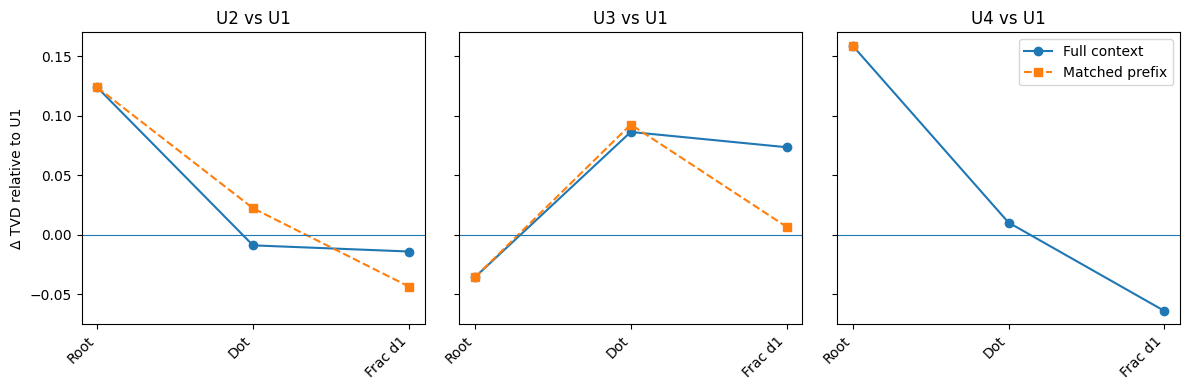

In [102]:
uniform_effect_plot = (
    uniform_full[
        [
            "contrast_id",
            "model_id",
            "analysis_stage",
            "delta_full",
        ]
    ]
    .merge(
        uniform_matched[
            [
                "contrast_id",
                "model_id",
                "analysis_stage",
                "delta_matched",
            ]
        ],
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="left",
    )
)

uniform_plot_summary = (
    uniform_effect_plot
    .groupby(
        ["contrast_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        full=("delta_full", "mean"),
        matched=("delta_matched", "mean"),
    )
)

uniform_stage_order = [
    "start",
    "dot",
    "fraction_d1",
]

contrast_order = [
    "U2_vs_U1",
    "U3_vs_U1",
    "U4_vs_U1",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharey=True,
)

for ax, contrast_id in zip(
    axes,
    contrast_order,
):

    temp = (
        uniform_plot_summary[
            uniform_plot_summary["contrast_id"]
            == contrast_id
        ]
        .set_index("analysis_stage")
        .reindex(uniform_stage_order)
    )

    x = np.arange(
        len(uniform_stage_order)
    )

    ax.plot(
        x,
        temp["full"],
        marker="o",
        label="Full context",
    )

    ax.plot(
        x,
        temp["matched"],
        marker="s",
        linestyle="--",
        label="Matched prefix",
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["Root", "Dot", "Frac d1"],
        rotation=45,
        ha="right",
    )

    ax.set_title(
        contrast_id.replace("_vs_", " vs ")
    )

axes[0].set_ylabel(
    "Δ TVD relative to U1"
)

axes[-1].legend()

plt.tight_layout()
plt.show()



U2: crossing zero

Moving from [0,1] to [−1,1] does not produce a consistent same-prefix TVD shift at ROOT, dot, or Fraction d1. ROOT changes are large for some conditions but divide evenly in direction.

The more important structural effect is the introduction of the negative-sign branch. Sign-stage alignment is highly model-dependent: four conditions show low TVD, while two Gemma raw conditions show values near 0.9–1.0.

So crossing zero changes not just the probability target, but the representational pathway itself.

U3: moderate support expansion

Moving from [0,1] to [0,2] introduces an informative integer stage and changes the later prefix region.

The apparent Fraction d1 deterioration of approximately +0.074 almost disappears at the only shared fractional prefix:

Δ
matched
	​

≈+0.007.

This indicates a mainly changed-region rather than same-prefix fractional effect.

At the shared dot prefix, however:

Δ
matched
	​

≈+0.093,

with 4 of 6 conditions worsening. This provides more direct evidence of local support-width sensitivity.

U4: extreme support expansion

Moving to [0,100] changes later-stage prefix coverage almost completely.

Only ROOT permits an exact U1/U4 comparison, and even there the response is highly model/protocol dependent.

The widened support additionally activates a substantial informative integer-stage alignment problem, with mean TVD around 0.393, but this cannot be expressed as a same-prefix deterioration relative to U1 because U1 has no corresponding informative integer stage.

U2 versus U3

Holding support width fixed at 2 but changing its location/sign structure yields a modest matched dot-stage difference favouring U2 in 5 of 6 conditions. ROOT remains strongly heterogeneous and fractional matching is weak.

This indicates that support width alone is insufficient to determine the alignment profile.

### Result statement

Uniform support changes affected both probabilistic alignment and the numerical contexts in which alignment was evaluated. Changing the support from $[0,1]$ to $[-1,1]$ produced no directionally consistent same-prefix change at ROOT, dot, or Fraction depth 1. The zero-crossing condition additionally introduced an explicit sign stage, whose TVD was strongly model/protocol dependent: four conditions had relatively low sign-stage TVD, whereas two conditions had TVD close to $0.9$ or above.

Expanding positive support from $[0,1]$ to $[0,2]$ increased full-context dot and Fraction depth-1 TVD by approximately $+0.086$ and $+0.074$, respectively. At the shared dot prefix, the matched increase remained approximately $+0.093$, with higher TVD in four of six conditions. In contrast, the matched Fraction depth-1 effect at the only shared fractional prefix was approximately $+0.007$, indicating that most of the full fractional difference was associated with the different fractional regions represented under the wider support.

Under the extreme $[0,100]$ support, only ROOT was exactly shared with the canonical condition. ROOT TVD increased by approximately $+0.159$ on average, but with substantial model/protocol heterogeneity. The extreme support also activated an informative integer stage with mean TVD approximately $0.393$, although no same-prefix canonical integer comparison was available.

In the same-width comparison between $[-1,1]$ and $[0,2]$, the matched dot-stage TVD was approximately $0.070$ lower under the zero-crossing support, with lower TVD in five of six model/protocol conditions.

### Result conclusion

Uniform support sensitivity cannot be reduced to a single effect of support width. Changing the support alters both the target probabilities and, in several conditions, the numerical representation itself by introducing sign or informative integer branches and moving later-stage prefixes into different numerical regions.

Moderate widening from $[0,1]$ to $[0,2]$ provides some evidence of genuine same-prefix sensitivity at the dot stage, whereas the corresponding fractional difference is primarily associated with changed prefix coverage. Extreme widening to $[0,100]$ cannot support same-prefix conclusions beyond ROOT because the later numerical contexts do not overlap with the canonical condition; instead, it demonstrates that wide support activates a new and non-trivial integer-stage alignment problem. The same-width $[-1,1]$ versus $[0,2]$ comparison further shows that alignment depends on support placement and sign structure rather than support width alone.

### Result conclusion

Uniform support sensitivity cannot be reduced to a single effect of support width. Changing the support alters both the target probabilities and, in several conditions, the numerical representation itself by introducing sign or informative integer branches and moving later-stage prefixes into different numerical regions.

Moderate widening from $[0,1]$ to $[0,2]$ provides some evidence of genuine same-prefix sensitivity at the dot stage, whereas the corresponding fractional difference is primarily associated with changed prefix coverage. Extreme widening to $[0,100]$ cannot support same-prefix conclusions beyond ROOT because the later numerical contexts do not overlap with the canonical condition; instead, it demonstrates that wide support activates a new and non-trivial integer-stage alignment problem. The same-width $[-1,1]$ versus $[0,2]$ comparison further shows that alignment depends on support placement and sign structure rather than support width alone.

## 09.15 — Uniform family conclusion

Uniform support geometry affects probabilistic alignment through two distinct mechanisms. First, the analytical next-symbol distribution can change at a numerical prefix that remains identical across conditions, as seen in the dot-stage comparison between $[0,1]$ and $[0,2]$. Second, changing the support can alter which numerical branches and regions are represented at all, including the introduction of a negative-sign branch under $[-1,1]$ and informative integer decisions under wider positive supports.

These representational changes make raw stage-level differences insufficient for interpreting support sensitivity. Matched-prefix analysis shows that some apparent effects, particularly the fractional difference between $[0,1]$ and $[0,2]$, largely disappear when numerical context is held fixed. In contrast, the extreme $[0,100]$ condition primarily demonstrates changed-region behaviour because later-stage contexts do not overlap with the canonical support. Overall, the Uniform results show that target support influences both local conditional alignment and the structure of the numerical prediction problem itself.

In [104]:
contrast_plan.loc[
    contrast_plan["contrast_id"] == "B4_vs_B2",
    "manipulation"
] = "right_skew"

contrast_plan.loc[
    contrast_plan["contrast_id"] == "B5_vs_B2",
    "manipulation"
] = "left_skew"

# 10 — RQ3B.5 Beta: Shape, Concentration and Skew

## Research question

How does changing the shape, concentration, or skew of a Beta target distribution alter next-symbol probabilistic alignment?

The canonical reference is:

$$
B2 = \mathrm{Beta}(2,2).
$$

All Beta conditions have the same support:

$$
[0,1].
$$

The evaluated conditions are:

- B1: $\mathrm{Beta}(1,1)$ — flat / Uniform-equivalent density
- B2: $\mathrm{Beta}(2,2)$ — canonical symmetric central density
- B3: $\mathrm{Beta}(0.5,0.5)$ — symmetric U-shaped / boundary-heavy density
- B4: $\mathrm{Beta}(2,5)$ — right-skewed density concentrated toward lower values
- B5: $\mathrm{Beta}(5,2)$ — left-skewed density concentrated toward higher values
- B6: $\mathrm{Beta}(5,5)$ — symmetric, more strongly concentrated around the centre

B4 and B5 are reflected versions of one another around $0.5$. They have the same total concentration, $\alpha+\beta=7$, but opposite skew orientation.

## 10.1 — Pre-analysis expectation

The Beta family provides a particularly controlled test of parameter sensitivity because support and evaluated prefix structure remain fixed while the target density changes.

Therefore:

1. All primary Beta comparisons can be made at exactly the same numerical prefixes.
2. Full-context and matched-prefix effects should be identical.
3. Differences cannot be attributed to changes in prefix coverage.
4. B1, B2, B3, and B6 test different symmetric density shapes and concentration patterns.
5. B4 and B5 test skewed target shapes.
6. B4 versus B5 provides a controlled comparison of opposite skew orientations while keeping support and total concentration fixed.
7. Fraction-level analysis is especially important because the same prefixes can occupy very different density regions under different Beta shapes.
8. No directional prediction is made about which shape should be easier or harder for the LM.

In [105]:
beta_primary = prefix[
    (prefix["distribution"] == "beta")
    & prefix["primary_alignment_row"]
].copy()

beta_stage = compute_stage_means(
    beta_primary
)

BETA_TARGETS = [
    "B1",
    "B3",
    "B4",
    "B5",
    "B6",
]

beta_full = pd.concat(
    [
        compute_full_contrast(
            beta_stage,
            target_id=parameter_id,
            reference_id="B2",
        )
        for parameter_id in BETA_TARGETS
    ],
    ignore_index=True,
)

beta_matched_outputs = [
    compute_matched_contrast(
        beta_primary,
        target_id=parameter_id,
        reference_id="B2",
    )
    for parameter_id in BETA_TARGETS
]

beta_matched = pd.concat(
    [x[0] for x in beta_matched_outputs],
    ignore_index=True,
)

In [106]:
beta_full_summary = summarise_across_models(
    beta_full,
    "delta_full",
)

beta_matched_summary = summarise_across_models(
    beta_matched,
    "delta_matched",
)

beta_common_counts = (
    beta_matched
    .groupby(
        ["contrast_id", "analysis_stage"]
    )["n_common"]
    .first()
    .reset_index()
)

beta_matched_summary = (
    beta_matched_summary
    .merge(
        beta_common_counts,
        on=["contrast_id", "analysis_stage"],
        how="left",
    )
)

display(
    beta_matched_summary
    .sort_values(
        ["contrast_id", "analysis_stage"]
    )
    .round(4)
)

,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better,n_common
0,B1_vs_B2,dot,-0.0402,-0.0662,-0.1722,0.2099,6,1,5,1
1,B1_vs_B2,fraction_d1,0.0511,0.0651,-0.0497,0.1403,6,4,2,3
2,B1_vs_B2,start,0.2202,0.0264,0.0005,0.9994,6,6,0,1
3,B3_vs_B2,dot,0.0643,0.0850,-0.2013,0.2293,6,5,1,1
4,B3_vs_B2,fraction_d1,0.0127,0.0054,-0.0521,0.1088,6,4,2,3
5,B3_vs_B2,start,-0.0772,-0.0319,-0.3570,0.0142,6,2,4,1
6,B4_vs_B2,dot,0.0109,-0.0105,-0.0863,0.1529,6,3,3,1
7,B4_vs_B2,fraction_d1,-0.0072,-0.0203,-0.0575,0.0601,6,3,3,3
8,B4_vs_B2,start,0.0835,0.0001,-0.1125,0.4966,6,4,2,1
9,B5_vs_B2,dot,0.0223,-0.0160,-0.0840,0.2582,6,2,4,1


In [107]:
for parameter_id in [
    "B1", "B2", "B3", "B4", "B5", "B6"
]:

    print(f"\n{parameter_id}")

    temp = beta_primary[
        beta_primary["parameter_id"]
        == parameter_id
    ]

    for stage in PRIMARY_STAGE_ORDER:

        values = sorted(
            temp.loc[
                temp["analysis_stage"] == stage,
                "prefix",
            ].unique()
        )

        print(stage, values)


B1
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']

B2
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']

B3
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']

B4
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']

B5
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']

B6
start ['ROOT']
sign []
integer []
dot ['0.']
fraction_d1 ['0.2', '0.5', '0.8']


In [108]:
beta_full_vs_matched_check = (
    beta_full
    .merge(
        beta_matched,
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="inner",
    )
)

beta_full_vs_matched_check["difference"] = (
    beta_full_vs_matched_check["delta_full"]
    - beta_full_vs_matched_check["delta_matched"]
)

print(
    "Maximum |full - matched|:",
    beta_full_vs_matched_check["difference"]
    .abs()
    .max()
)

Maximum |full - matched|: 1.1102230246251565e-16


In [109]:
beta_absolute = (
    beta_stage
    .groupby(
        ["parameter_id", "analysis_stage"]
    )["mean_value"]
    .agg(
        mean_tvd="mean",
        median_tvd="median",
        min_tvd="min",
        max_tvd="max",
        n_models="count",
    )
    .reset_index()
)

display(
    beta_absolute
    .sort_values(
        ["parameter_id", "analysis_stage"]
    )
    .round(4)
)

,parameter_id,analysis_stage,mean_tvd,median_tvd,min_tvd,max_tvd,n_models
0,B1,dot,0.5140,0.5884,0.1028,0.8969,6
1,B1,fraction_d1,0.3462,0.2787,0.0583,0.6830,6
2,B1,start,0.5844,0.6032,0.0005,0.9994,6
3,B2,dot,0.5542,0.5725,0.1626,0.9694,6
4,B2,fraction_d1,0.2951,0.1900,0.0758,0.5795,6
5,B2,start,0.3641,0.1990,0.0000,0.9523,6
6,B3,dot,0.6185,0.7345,0.1986,0.9190,6
7,B3,fraction_d1,0.3078,0.1972,0.1380,0.5787,6
8,B3,start,0.2869,0.1672,0.0142,0.7631,6
9,B4,dot,0.5651,0.6243,0.1906,0.8830,6


In [110]:
b1_root_by_model = (
    beta_full[
        (beta_full["contrast_id"] == "B1_vs_B2")
        & (beta_full["analysis_stage"] == "start")
    ][
        [
            "model_id",
            "reference_mean",
            "target_mean",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(b1_root_by_model.round(4))

,model_id,reference_mean,target_mean,delta_full
2,S1,0.2993,0.3397,0.0405
5,S2,0.0988,0.3597,0.2609
8,S3,0.0000,0.9994,0.9994
11,S4,0.8344,0.8468,0.0124
14,S5,0.9523,0.9601,0.0078
17,S6,0.0000,0.0005,0.0005


Flat Beta increases ROOT TVD in every condition, but the magnitude is highly heterogeneous and the large cross-model mean is driven predominantly by one model/protocol condition.

In [111]:
b1_dot_by_model = (
    beta_full[
        (beta_full["contrast_id"] == "B1_vs_B2")
        & (beta_full["analysis_stage"] == "dot")
    ][
        ["model_id", "delta_full"]
    ]
    .sort_values("model_id")
)

display(b1_dot_by_model.round(4))

,model_id,delta_full
0,S1,-0.0598
3,S2,-0.0926
6,S3,-0.1722
9,S4,-0.0541
12,S5,-0.0725
15,S6,0.2099


In [112]:
b3_dot_by_model = (
    beta_full[
        (beta_full["contrast_id"] == "B3_vs_B2")
        & (beta_full["analysis_stage"] == "dot")
    ][
        [
            "model_id",
            "reference_mean",
            "target_mean",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(b3_dot_by_model.round(4))

,model_id,reference_mean,target_mean,delta_full
18,S1,0.1626,0.1986,0.0361
21,S2,0.5957,0.8251,0.2293
24,S3,0.8459,0.9190,0.0731
27,S4,0.2022,0.2991,0.0969
30,S5,0.9694,0.7681,-0.2013
33,S6,0.5492,0.7009,0.1517


In [114]:
b6_fraction_by_model = (
    beta_full[
        (beta_full["contrast_id"] == "B6_vs_B2")
        & (
            beta_full["analysis_stage"]
            == "fraction_d1"
        )
    ][
        [
            "model_id",
            "delta_full",
        ]
    ]
    .sort_values("model_id")
)

display(b6_fraction_by_model.round(4))

,model_id,delta_full
73,S1,0.0096
76,S2,-0.0004
79,S3,0.0756
82,S4,0.0852
85,S5,0.0577
88,S6,0.0133


In [115]:
_, b6_b2_pairs = compute_matched_contrast(
    beta_primary,
    target_id="B6",
    reference_id="B2",
)

b6_fraction_prefix_summary = (
    b6_b2_pairs[
        b6_b2_pairs["analysis_stage"]
        == "fraction_d1"
    ]
    .groupby("prefix")["delta_pair"]
    .agg(
        mean_effect="mean",
        median_effect="median",
        min_effect="min",
        max_effect="max",
        n_models="count",
        n_worse=lambda x: (x > 0).sum(),
        n_better=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

display(
    b6_fraction_prefix_summary.round(4)
)

,prefix,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,0.2,0.0138,0.0231,-0.1171,0.1064,6,4,2
1,0.5,0.0032,0.0106,-0.1047,0.0923,6,4,2
2,0.8,0.1035,0.0914,-0.0255,0.2368,6,5,1


In [116]:
def summarise_prefix_effects(
    paired_df,
    stage="fraction_d1",
):
    return (
        paired_df[
            paired_df["analysis_stage"] == stage
        ]
        .groupby("prefix")["delta_pair"]
        .agg(
            mean_effect="mean",
            median_effect="median",
            min_effect="min",
            max_effect="max",
            n_models="count",
            n_worse=lambda x: (x > 0).sum(),
            n_better=lambda x: (x < 0).sum(),
        )
        .reset_index()
    )

In [118]:
_, b4_b2_pairs = compute_matched_contrast(
    beta_primary,
    target_id="B4",
    reference_id="B2",
)

_, b5_b2_pairs = compute_matched_contrast(
    beta_primary,
    target_id="B5",
    reference_id="B2",
)
print("\nB4 vs B2 prefix effects:")
display(
    summarise_prefix_effects(
        b4_b2_pairs
    ).round(4)
)
print("\nB5 vs B2 prefix effects:")
display(
    summarise_prefix_effects(
        b5_b2_pairs
    ).round(4)
)


B4 vs B2 prefix effects:


,prefix,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,0.2,0.0357,0.0275,-0.0828,0.1886,6,3,3
1,0.5,-0.2027,-0.2207,-0.3733,0.0177,6,1,5
2,0.8,0.1455,0.1544,0.0118,0.2116,6,6,0



B5 vs B2 prefix effects:


,prefix,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,0.2,0.0216,0.0192,-0.1026,0.1236,6,3,3
1,0.5,-0.1142,-0.0818,-0.2989,0.0192,6,1,5
2,0.8,0.0214,0.0010,-0.0867,0.1852,6,3,3


In [119]:
b4_b5_full = compute_full_contrast(
    beta_stage,
    target_id="B4",
    reference_id="B5",
)

b4_b5_matched, b4_b5_pairs = (
    compute_matched_contrast(
        beta_primary,
        target_id="B4",
        reference_id="B5",
    )
)

b4_b5_summary = summarise_across_models(
    b4_b5_matched,
    "delta_matched",
)

display(
    b4_b5_summary.round(4)
)

,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_worse,n_better
0,B4_vs_B5,dot,-0.0114,-0.0054,-0.1568,0.1782,6,3,3
1,B4_vs_B5,fraction_d1,0.0166,0.0126,-0.0495,0.0822,6,5,1
2,B4_vs_B5,start,-0.0100,-0.0000,-0.0903,0.0968,6,2,4


In [120]:
b4_b5_prefix_summary = (
    b4_b5_pairs
    .groupby(
        ["analysis_stage", "prefix"]
    )["delta_pair"]
    .agg(
        mean_effect="mean",
        median_effect="median",
        min_effect="min",
        max_effect="max",
        n_models="count",
        n_b4_worse=lambda x: (x > 0).sum(),
        n_b4_better=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

display(
    b4_b5_prefix_summary.round(4)
)

,analysis_stage,prefix,mean_effect,median_effect,min_effect,max_effect,n_models,n_b4_worse,n_b4_better
0,dot,0.,-0.0114,-0.0054,-0.1568,0.1782,6,3,3
1,fraction_d1,0.2,0.0141,0.0025,-0.1434,0.2048,6,3,3
2,fraction_d1,0.5,-0.0885,-0.0306,-0.3088,-0.0015,6,0,6
3,fraction_d1,0.8,0.1241,0.1187,0.0077,0.2569,6,6,0
4,start,ROOT,-0.0100,-0.0000,-0.0903,0.0968,6,2,4


In [121]:
beta_fraction_effects = []

for parameter_id in [
    "B1", "B3", "B4", "B5", "B6"
]:

    _, pairs = compute_matched_contrast(
        beta_primary,
        target_id=parameter_id,
        reference_id="B2",
    )

    temp = (
        pairs[
            pairs["analysis_stage"]
            == "fraction_d1"
        ]
        .groupby("prefix")["delta_pair"]
        .mean()
        .reset_index()
    )

    temp["parameter_id"] = parameter_id

    beta_fraction_effects.append(temp)

beta_fraction_effects = pd.concat(
    beta_fraction_effects,
    ignore_index=True,
)

beta_fraction_matrix = (
    beta_fraction_effects
    .pivot(
        index="parameter_id",
        columns="prefix",
        values="delta_pair",
    )
    .reindex(
        index=["B1", "B3", "B4", "B5", "B6"],
        columns=["0.2", "0.5", "0.8"],
    )
)

display(
    beta_fraction_matrix.round(4)
)

prefix,0.2,0.5,0.8
parameter_id,,,
B1,0.0010,0.0947,0.0577
B3,0.0296,-0.0297,0.0382
B4,0.0357,-0.2027,0.1455
B5,0.0216,-0.1142,0.0214
B6,0.0138,0.0032,0.1035


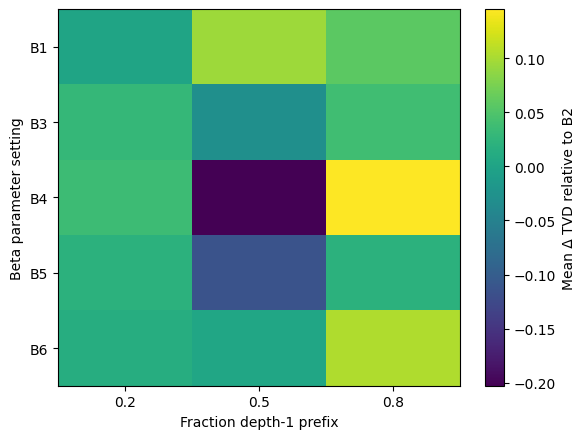

In [122]:
fig, ax = plt.subplots(
    figsize=(6, 4.5)
)

im = ax.imshow(
    beta_fraction_matrix.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(len(beta_fraction_matrix.columns))
)
ax.set_xticklabels(
    beta_fraction_matrix.columns
)

ax.set_yticks(
    range(len(beta_fraction_matrix.index))
)
ax.set_yticklabels(
    beta_fraction_matrix.index
)

ax.set_xlabel(
    "Fraction depth-1 prefix"
)
ax.set_ylabel(
    "Beta parameter setting"
)

fig.colorbar(
    im,
    ax=ax,
    label="Mean Δ TVD relative to B2",
)

plt.tight_layout()
plt.show()

the effect of mathematical shape depends on where in the numeric space the prefix lies

In [123]:
beta_stage_matrix = (
    beta_matched_summary
    .pivot(
        index="contrast_id",
        columns="analysis_stage",
        values="mean_effect",
    )
    .reindex(
        index=[
            "B1_vs_B2",
            "B3_vs_B2",
            "B4_vs_B2",
            "B5_vs_B2",
            "B6_vs_B2",
        ],
        columns=[
            "start",
            "dot",
            "fraction_d1",
        ],
    )
)

display(
    beta_stage_matrix.round(4)
)

analysis_stage,start,dot,fraction_d1
contrast_id,,,
B1_vs_B2,0.2202,-0.0402,0.0511
B3_vs_B2,-0.0772,0.0643,0.0127
B4_vs_B2,0.0835,0.0109,-0.0072
B5_vs_B2,0.0935,0.0223,-0.0237
B6_vs_B2,0.0970,-0.0012,0.0402


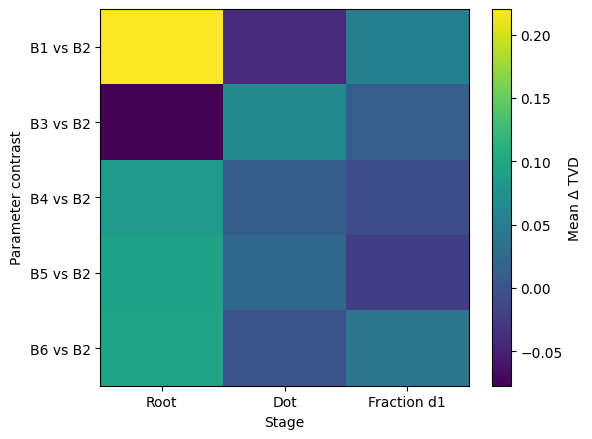

In [124]:
fig, ax = plt.subplots(
    figsize=(6, 4.5)
)

im = ax.imshow(
    beta_stage_matrix.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(len(beta_stage_matrix.columns))
)
ax.set_xticklabels(
    ["Root", "Dot", "Fraction d1"]
)

ax.set_yticks(
    range(len(beta_stage_matrix.index))
)
ax.set_yticklabels(
    [
        "B1 vs B2",
        "B3 vs B2",
        "B4 vs B2",
        "B5 vs B2",
        "B6 vs B2",
    ]
)

ax.set_xlabel("Stage")
ax.set_ylabel("Parameter contrast")

fig.colorbar(
    im,
    ax=ax,
    label="Mean Δ TVD",
)

plt.tight_layout()
plt.show()

### Result statement

Beta shape changes produced stage- and prefix-dependent changes in alignment despite identical support and prefix coverage across all six parameter settings. Because the primary prefix sets were identical, the full-context and matched-prefix effects were numerically equivalent.

Relative to $\mathrm{Beta}(2,2)$, the flat $\mathrm{Beta}(1,1)$ condition increased ROOT TVD by approximately $+0.220$ and did so in all six model/protocol conditions, although the median increase was only approximately $+0.026$ because one condition contributed an effect close to $+1$. Dot-stage TVD decreased by approximately $0.040$ under B1, with lower TVD in five of six conditions. The U-shaped $\mathrm{Beta}(0.5,0.5)$ condition increased dot-stage TVD by approximately $+0.064$, with higher TVD in five of six conditions.

Increasing symmetric central concentration to $\mathrm{Beta}(5,5)$ increased Fraction depth-1 TVD by approximately $+0.040$, with higher TVD in five of six conditions. This effect was localised primarily to prefix $0.8$, where the mean increase was approximately $+0.104$.

The skewed B4 and B5 conditions showed comparatively small aggregate Fraction depth-1 effects, but these averages concealed substantially larger prefix-specific changes. For $\mathrm{Beta}(2,5)$ relative to B2, TVD decreased by approximately $0.203$ at prefix $0.5$ but increased by approximately $0.146$ at prefix $0.8$; the latter increase occurred in all six model/protocol conditions. In the direct B4-versus-B5 skew-orientation comparison, B4 had approximately $0.089$ lower TVD at prefix $0.5$ in all six conditions and approximately $0.124$ higher TVD at prefix $0.8$ in all six conditions, while the aggregate fractional-stage difference was only approximately $+0.017$.

### Result conclusion

Beta alignment is sensitive to target density shape even when numerical support and evaluated prefixes are held fixed. The effect is not a uniform increase or decrease in alignment across the representation. Flatness, boundary concentration, central concentration, and skew affect different numerical stages and prefixes differently.

Most importantly, stage-level averaging can conceal substantial local parameter sensitivity. The skewed Beta conditions show nearly unchanged average Fraction depth-1 TVD, yet exact-prefix analysis reveals large and directionally consistent differences at individual fractional prefixes. Thus, within a fixed support and fixed numerical context set, the effect of changing target shape depends strongly on the particular prefix being conditioned upon.

The Beta results therefore provide direct evidence for a parameter-by-prefix interaction: mathematically different target shapes can alter alignment strongly at specific numerical locations even when their aggregate stage-level effects are small.

## 10.16 — Beta family conclusion

The Beta family provides the cleanest controlled evidence that LLM probabilistic alignment depends on target distribution shape. All evaluated Beta conditions share the same support and the same primary numerical prefixes, so differences directly reflect changes in alignment under altered target probability geometry rather than changes in evaluation coverage.

The effects are strongly local. Flat and boundary-heavy shapes primarily alter ROOT or dot-stage behaviour, while increased central concentration produces a modest fractional effect concentrated at a particular prefix. The skew conditions demonstrate the clearest prefix interaction: opposite changes at different fractional prefixes largely cancel in the stage average, making the aggregate effect appear small despite substantial local sensitivity.

Consequently, alignment with a distribution family cannot be characterised only by a family-level or even stage-level score. Within the same Beta family, changing shape can substantially alter local next-symbol alignment, and the direction and magnitude of that change depend on the numerical prefix at which the model is evaluated.

### Mechanistic follow-up candidate

The B4/B5 skew-orientation comparison is retained for later token-level analysis at Fraction depth-1 prefixes $0.5$ and $0.8$.

This case is selected because:

- support is identical;
- prefixes are identical;
- total concentration is identical;
- the distributions differ in skew orientation;
- the effect reverses across prefixes;
- both prefix-specific directions are consistent across all six model/protocol conditions.

The token-level analysis is deferred until the primary parameter-sweep analyses are complete.

# 11 — Equivalent-Target Control

## Research question

Do mathematically equivalent target distributions produce the same LLM next-symbol behaviour when they are specified as different distribution families?

The control compares:

$$
B1 = \mathrm{Beta}(1,1)
$$

with:

$$
U1 = \mathrm{Uniform}(0,1).
$$

These distributions are mathematically equivalent:

$$
\mathrm{Beta}(1,1) \equiv \mathrm{Uniform}(0,1).
$$

Both have support $[0,1]$ and the same constant probability density over that support.

This comparison is not a test of mathematical parameter sensitivity. Instead, it tests whether the model's numerical probability behaviour depends on how an equivalent target is specified.

The comparison is paired by model/protocol condition and exact numerical prefix.

## 11.1 — Pre-analysis expectation

Because Beta(1,1) and Uniform(0,1) define the same probability distribution:

1. Their analytical next-symbol distributions should be identical at every shared prefix.
2. Their candidate sets should be identical.
3. Their prefix coverage should be identical.
4. Any difference in LM next-symbol probabilities cannot be attributed to different target mathematics.
5. A difference would instead indicate sensitivity to the distribution-family specification or its representation in the prompt.
6. No directional prediction is made about whether the Beta or Uniform specification should produce better alignment.

In [125]:
b1_structure = (
    prefix[
        prefix["parameter_id"] == "B1"
    ][
        [
            "analysis_stage",
            "prefix",
            "candidate_count",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["analysis_stage", "prefix"]
    )
    .reset_index(drop=True)
)

u1_structure = (
    prefix[
        prefix["parameter_id"] == "U1"
    ][
        [
            "analysis_stage",
            "prefix",
            "candidate_count",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["analysis_stage", "prefix"]
    )
    .reset_index(drop=True)
)

print(
    "Identical structural tables:",
    b1_structure.equals(u1_structure)
)

display(b1_structure)

Identical structural tables: True


,analysis_stage,prefix,candidate_count
0,dot,0.,10
1,fraction_d1,0.2,10
2,fraction_d1,0.5,10
3,fraction_d1,0.8,10
4,fraction_d2,0.20,10
5,fraction_d2,0.50,10
6,fraction_d2,0.80,10
7,integer,0,1
8,start,ROOT,10


In [126]:
b1_truth = (
    token[
        token["parameter_id"] == "B1"
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "token",
            "analytic_truth",
        ]
    ]
    .rename(
        columns={
            "analytic_truth": "analytic_truth_B1"
        }
    )
)

u1_truth = (
    token[
        token["parameter_id"] == "U1"
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "token",
            "analytic_truth",
        ]
    ]
    .rename(
        columns={
            "analytic_truth": "analytic_truth_U1"
        }
    )
)

truth_control = b1_truth.merge(
    u1_truth,
    on=[
        "model_id",
        "analysis_stage",
        "prefix",
        "token",
    ],
    how="outer",
    indicator=True,
)

print(
    truth_control["_merge"].value_counts()
)

truth_control["truth_abs_difference"] = (
    truth_control["analytic_truth_B1"]
    - truth_control["analytic_truth_U1"]
).abs()

print(
    "Maximum analytical truth difference:",
    truth_control[
        "truth_abs_difference"
    ].max()
)

_merge
both          486
left_only       0
right_only      0
Name: count, dtype: int64
Maximum analytical truth difference: 0.0


In [127]:
CONTROL_STAGES = [
    "start",
    "dot",
    "fraction_d1",
]

b1_control = (
    prefix[
        (prefix["parameter_id"] == "B1")
        & prefix["primary_alignment_row"]
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "tv_analytic_lm",
        ]
    ]
    .rename(
        columns={
            "tv_analytic_lm": "tvd_B1"
        }
    )
)

u1_control = (
    prefix[
        (prefix["parameter_id"] == "U1")
        & prefix["primary_alignment_row"]
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "tv_analytic_lm",
        ]
    ]
    .rename(
        columns={
            "tv_analytic_lm": "tvd_U1"
        }
    )
)

equivalent_pairs = b1_control.merge(
    u1_control,
    on=[
        "model_id",
        "analysis_stage",
        "prefix",
    ],
    how="inner",
    validate="one_to_one",
)

equivalent_pairs["delta_tvd"] = (
    equivalent_pairs["tvd_B1"]
    - equivalent_pairs["tvd_U1"]
)

print(
    "Paired primary rows:",
    len(equivalent_pairs)
)

Paired primary rows: 30


In [128]:
equivalent_stage_model = (
    equivalent_pairs
    .groupby(
        ["model_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        B1_mean_tvd=("tvd_B1", "mean"),
        U1_mean_tvd=("tvd_U1", "mean"),
        delta_tvd=("delta_tvd", "mean"),
        n_prefixes=("prefix", "nunique"),
    )
)

display(
    equivalent_stage_model
    .sort_values(
        ["analysis_stage", "model_id"]
    )
    .round(4)
)

,model_id,analysis_stage,B1_mean_tvd,U1_mean_tvd,delta_tvd,n_prefixes
0,S1,dot,0.1028,0.1280,-0.0253,1
3,S2,dot,0.5032,0.3505,0.1527,1
6,S3,dot,0.6737,0.7825,-0.1088,1
9,S4,dot,0.1481,0.0851,0.0630,1
12,S5,dot,0.8969,0.8989,-0.0021,1
15,S6,dot,0.7591,0.3988,0.3603,1
1,S1,fraction_d1,0.1404,0.1550,-0.0146,3
4,S2,fraction_d1,0.2533,0.5480,-0.2947,3
7,S3,fraction_d1,0.6830,0.8190,-0.1360,3
10,S4,fraction_d1,0.0583,0.1290,-0.0707,3


In [129]:
equivalent_stage_summary = (
    equivalent_stage_model
    .groupby("analysis_stage")
    ["delta_tvd"]
    .agg(
        mean_effect="mean",
        median_effect="median",
        min_effect="min",
        max_effect="max",
        n_models="count",
        n_B1_worse=lambda x: (x > 0).sum(),
        n_B1_better=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

display(
    equivalent_stage_summary.round(4)
)

,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_models,n_B1_worse,n_B1_better
0,dot,0.0733,0.0304,-0.1088,0.3603,6,3,3
1,fraction_d1,-0.1195,-0.1033,-0.2947,-0.0146,6,0,6
2,start,0.2958,0.1976,-0.0000,0.9989,6,5,1


In [130]:
equivalent_absolute_summary = (
    equivalent_stage_model
    .groupby("analysis_stage")
    .agg(
        B1_mean=("B1_mean_tvd", "mean"),
        U1_mean=("U1_mean_tvd", "mean"),
        B1_median=("B1_mean_tvd", "median"),
        U1_median=("U1_mean_tvd", "median"),
    )
    .reset_index()
)

display(
    equivalent_absolute_summary.round(4)
)

,analysis_stage,B1_mean,U1_mean,B1_median,U1_median
0,dot,0.5140,0.4406,0.5884,0.3746
1,fraction_d1,0.3462,0.4657,0.2787,0.5129
2,start,0.5844,0.2886,0.6032,0.1698


In [131]:
equivalent_root = (
    equivalent_stage_model[
        equivalent_stage_model[
            "analysis_stage"
        ] == "start"
    ][
        [
            "model_id",
            "B1_mean_tvd",
            "U1_mean_tvd",
            "delta_tvd",
        ]
    ]
    .sort_values("model_id")
)

display(
    equivalent_root.round(4)
)

,model_id,B1_mean_tvd,U1_mean_tvd,delta_tvd
2,S1,0.3397,0.3354,0.0044
5,S2,0.3597,0.0041,0.3555
8,S3,0.9994,0.0005,0.9989
11,S4,0.8468,0.8072,0.0396
14,S5,0.9601,0.5836,0.3765
17,S6,0.0005,0.0005,-0.0000


In [132]:
equivalent_fraction = (
    equivalent_stage_model[
        equivalent_stage_model[
            "analysis_stage"
        ] == "fraction_d1"
    ][
        [
            "model_id",
            "B1_mean_tvd",
            "U1_mean_tvd",
            "delta_tvd",
        ]
    ]
    .sort_values("model_id")
)

display(
    equivalent_fraction.round(4)
)

,model_id,B1_mean_tvd,U1_mean_tvd,delta_tvd
1,S1,0.1404,0.1550,-0.0146
4,S2,0.2533,0.5480,-0.2947
7,S3,0.6830,0.8190,-0.1360
10,S4,0.0583,0.1290,-0.0707
13,S5,0.6380,0.6654,-0.0274
16,S6,0.3042,0.4779,-0.1737


In [133]:
equivalent_prefix_summary = (
    equivalent_pairs
    .groupby(
        ["analysis_stage", "prefix"]
    )["delta_tvd"]
    .agg(
        mean_effect="mean",
        median_effect="median",
        min_effect="min",
        max_effect="max",
        n_models="count",
        n_B1_worse=lambda x: (x > 0).sum(),
        n_B1_better=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

display(
    equivalent_prefix_summary.round(4)
)

,analysis_stage,prefix,mean_effect,median_effect,min_effect,max_effect,n_models,n_B1_worse,n_B1_better
0,dot,0.,0.0733,0.0304,-0.1088,0.3603,6,3,3
1,fraction_d1,0.2,-0.2152,-0.2103,-0.4195,-0.0275,6,0,6
2,fraction_d1,0.5,0.0394,0.0046,-0.0514,0.1695,6,3,3
3,fraction_d1,0.8,-0.1828,-0.0876,-0.4169,-0.0600,6,0,6
4,start,ROOT,0.2958,0.1976,-0.0000,0.9989,6,5,1


In [134]:
b1_token_control = (
    token[
        (token["parameter_id"] == "B1")
        & token["analysis_stage"].isin(
            ["start", "dot", "fraction_d1"]
        )
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "token",
            "analytic_truth",
            "lm_prob",
        ]
    ]
    .rename(
        columns={
            "analytic_truth": "truth_B1",
            "lm_prob": "lm_prob_B1",
        }
    )
)

u1_token_control = (
    token[
        (token["parameter_id"] == "U1")
        & token["analysis_stage"].isin(
            ["start", "dot", "fraction_d1"]
        )
    ][
        [
            "model_id",
            "analysis_stage",
            "prefix",
            "token",
            "analytic_truth",
            "lm_prob",
        ]
    ]
    .rename(
        columns={
            "analytic_truth": "truth_U1",
            "lm_prob": "lm_prob_U1",
        }
    )
)

lm_control_tokens = b1_token_control.merge(
    u1_token_control,
    on=[
        "model_id",
        "analysis_stage",
        "prefix",
        "token",
    ],
    how="inner",
    validate="one_to_one",
)

lm_control_tokens["spec_tvd_contribution"] = (
    0.5
    * (
        lm_control_tokens["lm_prob_B1"]
        - lm_control_tokens["lm_prob_U1"]
    ).abs()
)

lm_specification_tvd = (
    lm_control_tokens
    .groupby(
        [
            "model_id",
            "analysis_stage",
            "prefix",
        ],
        as_index=False,
    )
    .agg(
        lm_specification_tvd=(
            "spec_tvd_contribution",
            "sum",
        )
    )
)

In [135]:
lm_specification_summary = (
    lm_specification_tvd
    .groupby("analysis_stage")
    ["lm_specification_tvd"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .reset_index()
)

display(
    lm_specification_summary.round(4)
)

,analysis_stage,mean,median,min,max
0,dot,0.2917,0.2781,0.0021,0.6222
1,fraction_d1,0.3445,0.3127,0.0273,0.9620
2,start,0.3049,0.1976,0.0000,0.9999


In [136]:
lm_spec_by_model_stage = (
    lm_specification_tvd
    .groupby(
        ["model_id", "analysis_stage"],
        as_index=False,
    )
    .agg(
        mean_specification_tvd=(
            "lm_specification_tvd",
            "mean",
        )
    )
)

display(
    lm_spec_by_model_stage
    .sort_values(
        ["model_id", "analysis_stage"]
    )
    .round(4)
)

,model_id,analysis_stage,mean_specification_tvd
0,S1,dot,0.1443
1,S1,fraction_d1,0.1785
2,S1,start,0.0259
3,S2,dot,0.4119
4,S2,fraction_d1,0.4787
5,S2,start,0.3555
6,S3,dot,0.4926
7,S3,fraction_d1,0.6785
8,S3,start,0.9999
9,S4,dot,0.0772


In [137]:
lm_spec_by_model = (
    lm_spec_by_model_stage
    .groupby("model_id")
    ["mean_specification_tvd"]
    .mean()
    .sort_values()
)

display(
    lm_spec_by_model.to_frame(
        "stage_balanced_specification_tvd"
    ).round(4)
)

,stage_balanced_specification_tvd
model_id,
S4,0.0753
S1,0.1162
S5,0.1767
S6,0.3748
S2,0.4154
S3,0.7236


sensitivity to mathematically equivalent target specifications is itself model/protocol dependent.

In [138]:
control_plot = (
    equivalent_stage_model
    .pivot(
        index="model_id",
        columns="analysis_stage",
        values="delta_tvd",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=[
            "start",
            "dot",
            "fraction_d1",
        ],
    )
)

display(control_plot.round(4))

analysis_stage,start,dot,fraction_d1
model_id,,,
S1,0.0044,-0.0253,-0.0146
S2,0.3555,0.1527,-0.2947
S3,0.9989,-0.1088,-0.1360
S4,0.0396,0.0630,-0.0707
S5,0.3765,-0.0021,-0.0274
S6,-0.0000,0.3603,-0.1737


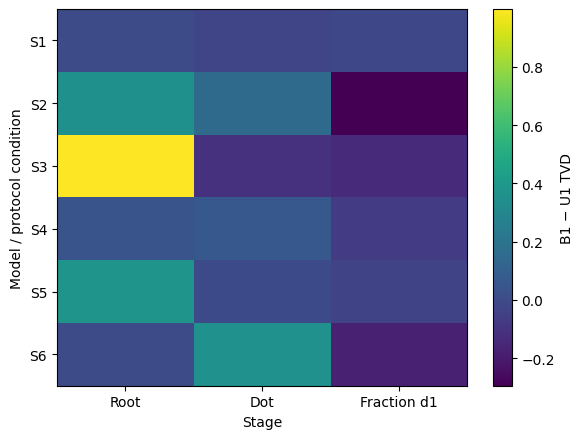

In [139]:
fig, ax = plt.subplots(
    figsize=(6, 4.5)
)

im = ax.imshow(
    control_plot.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(len(control_plot.columns))
)
ax.set_xticklabels(
    ["Root", "Dot", "Fraction d1"]
)

ax.set_yticks(
    range(len(control_plot.index))
)
ax.set_yticklabels(
    control_plot.index
)

ax.set_xlabel("Stage")
ax.set_ylabel("Model / protocol condition")

fig.colorbar(
    im,
    ax=ax,
    label="B1 − U1 TVD",
)

plt.tight_layout()
plt.show()

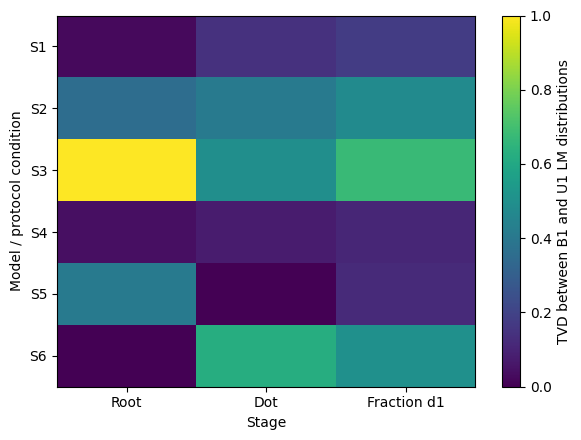

In [140]:
spec_matrix = (
    lm_spec_by_model_stage
    .pivot(
        index="model_id",
        columns="analysis_stage",
        values="mean_specification_tvd",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=[
            "start",
            "dot",
            "fraction_d1",
        ],
    )
)

fig, ax = plt.subplots(
    figsize=(6, 4.5)
)

im = ax.imshow(
    spec_matrix.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    range(len(spec_matrix.columns))
)
ax.set_xticklabels(
    ["Root", "Dot", "Fraction d1"]
)

ax.set_yticks(
    range(len(spec_matrix.index))
)
ax.set_yticklabels(
    spec_matrix.index
)

ax.set_xlabel("Stage")
ax.set_ylabel("Model / protocol condition")

fig.colorbar(
    im,
    ax=ax,
    label="TVD between B1 and U1 LM distributions",
)

plt.tight_layout()
plt.show()

### Interpretation boundary

The Beta(1,1) and Uniform(0,1) conditions are mathematically equivalent and have identical analytical next-symbol targets in the evaluation data.

Therefore, observed LM differences demonstrate sensitivity to the different target specifications rather than sensitivity to different target mathematics.

However, the current experiment does not isolate which component of the specification causes the effect. The result should therefore be described as representation- or specification-level sensitivity, rather than attributed specifically to a distribution name, parameter notation, or individual prompt phrase.

### Result statement

The Beta(1,1) and Uniform(0,1) control conditions used identical numerical prefixes, identical candidate sets, and exactly identical analytical next-symbol probability distributions; the maximum stored analytical probability difference between paired candidate rows was $0$.

Despite this mathematical equivalence, LM alignment differed substantially between the two target specifications. Relative to Uniform(0,1), Beta(1,1) increased ROOT TVD by approximately $+0.296$ on average, with higher TVD in five of six model/protocol conditions, although the magnitude was strongly model-dependent. At Fraction depth 1, the direction reversed: Beta(1,1) reduced mean TVD by approximately $0.120$, with lower TVD in all six conditions. The fractional effect was localised particularly to prefixes $0.2$ and $0.8$, where Beta(1,1) reduced mean TVD by approximately $0.215$ and $0.183$, respectively, in all six conditions.

Direct comparison of the two renormalised LM next-symbol distributions also showed substantial differences despite identical analytical truth. Mean TVD between the Beta(1,1)-conditioned and Uniform(0,1)-conditioned LM distributions was approximately $0.305$ at ROOT, $0.292$ at dot, and $0.344$ at Fraction depth 1. The magnitude of this specification sensitivity varied substantially across model/protocol conditions.

### Result conclusion

Mathematically equivalent target distributions do not necessarily induce equivalent next-symbol behaviour in the evaluated language models. Beta(1,1) and Uniform(0,1) define exactly the same target distribution and produce identical analytical next-symbol probabilities at every evaluated prefix, yet the models assign materially different conditional probability distributions under the two specifications.

The effect is stage- and prefix-dependent rather than a fixed advantage for one specification. The Beta specification is generally less aligned at ROOT but more aligned at the evaluated Fraction depth-1 prefixes, particularly $0.2$ and $0.8$. The size of the effect also varies strongly across model/protocol conditions.

This control therefore shows that measured probabilistic alignment depends not only on the mathematical target distribution but also on how that target is represented to the model. Consequently, differences observed between distribution families cannot automatically be interpreted as consequences of probability geometry alone when their specifications also differ.

### Mechanistic follow-up candidate

The equivalent-target control is retained as an optional token-level follow-up, particularly for the large S3 ROOT difference and the consistently different Fraction depth-1 behaviour at prefixes $0.2$ and $0.8$.

No token-level interpretation is required for the primary equivalent-target conclusion because analytical equivalence and direct LM-distribution divergence are already established.

# 12 — Matched-Prefix Synthesis

## Purpose

The family-level analyses showed that parameter changes can affect alignment in two related ways:

1. by changing the analytical target probabilities at a numerical prefix that remains unchanged; and
2. by changing which numerical prefixes and regions become relevant under the new target parameterisation.

This section synthesises the planned within-family parameter contrasts to determine how often observed stage-level effects persist when numerical context is held fixed.

Two estimands are compared:

### Full-context effect

$$
\Delta^{\mathrm{full}}_{ms}(p,p_0)
=
\bar{Y}^{\mathrm{full}}_{mps}
-
\bar{Y}^{\mathrm{full}}_{mp_0s}.
$$

This compares all informative prefixes available at a stage under the two parameter settings.

### Matched-prefix effect

$$
\Delta^{\mathrm{matched}}_{ms}(p,p_0)
=
\frac{1}{|I_s(p,p_0)|}
\sum_{r \in I_s(p,p_0)}
\left(
Y_{mpr}
-
Y_{mp_0r}
\right).
$$

This compares only exact numerical prefixes that occur in both conditions.

The difference between the two estimates is used as a diagnostic of sensitivity to prefix composition. It is not interpreted as a formal causal decomposition.

In [142]:
objects_to_check = [
    "normal_scale_full",
    "normal_scale_matched",
    "normal_location_full",
    "normal_location_matched",
    "laplace_full",
    "laplace_matched",
    "exponential_full",
    "exponential_matched",
    "uniform_full",
    "uniform_matched",
    "beta_full",
    "beta_matched",
    "equivalent_pairs",
]

object_status = {
    name: name in globals()
    for name in objects_to_check
}

pd.Series(
    object_status,
    name="exists"
).to_frame()

,exists
normal_scale_full,True
normal_scale_matched,True
normal_location_full,True
normal_location_matched,True
laplace_full,True
laplace_matched,True
exponential_full,True
exponential_matched,True
uniform_full,True
uniform_matched,True


In [143]:
for name in objects_to_check:
    if name in globals():
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            print(
                f"{name:28s}",
                obj.shape,
                list(obj.columns)
            )
        else:
            print(
                f"{name:28s}",
                type(obj)
            )

normal_scale_full            (90, 6) ['model_id', 'analysis_stage', 'target_mean', 'reference_mean', 'delta_full', 'contrast_id']
normal_scale_matched         (90, 6) ['model_id', 'analysis_stage', 'delta_matched', 'median_matched', 'n_common', 'contrast_id']
normal_location_full         (60, 6) ['model_id', 'analysis_stage', 'target_mean', 'reference_mean', 'delta_full', 'contrast_id']
normal_location_matched      (48, 6) ['model_id', 'analysis_stage', 'delta_matched', 'median_matched', 'n_common', 'contrast_id']
laplace_full                 (90, 6) ['model_id', 'analysis_stage', 'target_mean', 'reference_mean', 'delta_full', 'contrast_id']
laplace_matched              (90, 6) ['model_id', 'analysis_stage', 'delta_matched', 'median_matched', 'n_common', 'contrast_id']
exponential_full             (72, 6) ['model_id', 'analysis_stage', 'target_mean', 'reference_mean', 'delta_full', 'contrast_id']
exponential_matched          (72, 6) ['model_id', 'analysis_stage', 'delta_matched', 'medi

# 12 — Cross-Family Parameter Synthesis Setup

This section standardises the family-level parameter-effect tables produced in Sections 06–10.

The synthesis uses only the planned parameter-versus-canonical contrasts. Planned within-family controls such as N4 versus N5, U2 versus U3, and B4 versus B5 remain separate because they answer different comparison questions.

For parameter contrasts whose prefix coverage differs, both the full-context and matched-prefix estimates are retained. Matched-prefix analysis remains a validation of the parameter effect rather than a separate research question.

In [144]:
anchor_full = pd.concat(
    [
        normal_scale_full,
        normal_location_full,
        laplace_full,
        exponential_full,
        uniform_full,
        beta_full,
    ],
    ignore_index=True,
)

print("Full-context rows:", len(anchor_full))
display(anchor_full.head())

Full-context rows: 456


,model_id,analysis_stage,target_mean,reference_mean,delta_full,contrast_id
0,S1,dot,0.244215,0.090046,0.154168,N2_vs_N1
1,S1,fraction_d1,0.157168,0.199912,-0.042744,N2_vs_N1
2,S1,integer,0.062723,0.026559,0.036164,N2_vs_N1
3,S1,sign,0.100154,0.053985,0.046168,N2_vs_N1
4,S1,start,0.350098,0.308328,0.041770,N2_vs_N1


In [145]:
anchor_matched = pd.concat(
    [
        normal_scale_matched,
        normal_location_matched,
        laplace_matched,
        exponential_matched,
        uniform_matched,
        beta_matched,
    ],
    ignore_index=True,
)

print("Matched-prefix rows:", len(anchor_matched))
display(anchor_matched.head())

Matched-prefix rows: 432


,model_id,analysis_stage,delta_matched,median_matched,n_common,contrast_id
0,S1,dot,0.154168,0.136752,4,N2_vs_N1
1,S1,fraction_d1,-0.061373,-0.061373,2,N2_vs_N1
2,S1,integer,0.036164,0.036164,2,N2_vs_N1
3,S1,sign,0.046168,0.046168,1,N2_vs_N1
4,S1,start,0.041770,0.041770,1,N2_vs_N1


In [146]:
SYNTHESIS_KEY = [
    "contrast_id",
    "model_id",
    "analysis_stage",
]

full_duplicates = (
    anchor_full
    .duplicated(
        subset=SYNTHESIS_KEY,
        keep=False,
    )
)

matched_duplicates = (
    anchor_matched
    .duplicated(
        subset=SYNTHESIS_KEY,
        keep=False,
    )
)

print(
    "Duplicate full rows:",
    full_duplicates.sum()
)

print(
    "Duplicate matched rows:",
    matched_duplicates.sum()
)

Duplicate full rows: 0
Duplicate matched rows: 0


In [147]:
anchor_effects = (
    anchor_full
    .merge(
        anchor_matched[
            [
                "contrast_id",
                "model_id",
                "analysis_stage",
                "delta_matched",
                "median_matched",
                "n_common",
            ]
        ],
        on=[
            "contrast_id",
            "model_id",
            "analysis_stage",
        ],
        how="left",
        validate="one_to_one",
    )
)

print(anchor_effects.shape)

display(
    anchor_effects.head()
)

(456, 9)


,model_id,analysis_stage,target_mean,reference_mean,delta_full,contrast_id,delta_matched,median_matched,n_common
0,S1,dot,0.244215,0.090046,0.154168,N2_vs_N1,0.154168,0.136752,4.0
1,S1,fraction_d1,0.157168,0.199912,-0.042744,N2_vs_N1,-0.061373,-0.061373,2.0
2,S1,integer,0.062723,0.026559,0.036164,N2_vs_N1,0.036164,0.036164,2.0
3,S1,sign,0.100154,0.053985,0.046168,N2_vs_N1,0.046168,0.046168,1.0
4,S1,start,0.350098,0.308328,0.041770,N2_vs_N1,0.041770,0.041770,1.0


In [148]:
contrast_parts = (
    anchor_effects["contrast_id"]
    .str.split(
        "_vs_",
        n=1,
        expand=True,
    )
)

anchor_effects["target_id"] = (
    contrast_parts[0]
)

anchor_effects["reference_id"] = (
    contrast_parts[1]
)

In [149]:
parameter_family = (
    prefix[
        [
            "parameter_id",
            "distribution",
        ]
    ]
    .drop_duplicates()
    .set_index("parameter_id")
    ["distribution"]
    .to_dict()
)

anchor_effects["distribution"] = (
    anchor_effects["target_id"]
    .map(parameter_family)
)

In [150]:
display(
    anchor_effects[
        [
            "contrast_id",
            "target_id",
            "reference_id",
            "distribution",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "distribution",
            "contrast_id",
        ]
    )
)

,contrast_id,target_id,reference_id,distribution
366,B1_vs_B2,B1,B2,beta
384,B3_vs_B2,B3,B2,beta
402,B4_vs_B2,B4,B2,beta
420,B5_vs_B2,B5,B2,beta
438,B6_vs_B2,B6,B2,beta
240,E2_vs_E1,E2,E1,exponential
264,E3_vs_E1,E3,E1,exponential
288,E4_vs_E1,E4,E1,exponential
150,L2_vs_L1,L2,L1,laplace
180,L3_vs_L1,L3,L1,laplace


In [151]:
missing_matched = (
    anchor_effects[
        anchor_effects["delta_matched"].isna()
    ][
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
            "model_id",
        ]
    ]
    .sort_values(
        [
            "contrast_id",
            "analysis_stage",
            "model_id",
        ]
    )
)

display(missing_matched)

,distribution,contrast_id,analysis_stage,model_id
91,normal,N4_vs_N1,fraction_d1,S1
96,normal,N4_vs_N1,fraction_d1,S2
101,normal,N4_vs_N1,fraction_d1,S3
106,normal,N4_vs_N1,fraction_d1,S4
111,normal,N4_vs_N1,fraction_d1,S5
116,normal,N4_vs_N1,fraction_d1,S6
121,normal,N5_vs_N1,fraction_d1,S1
126,normal,N5_vs_N1,fraction_d1,S2
131,normal,N5_vs_N1,fraction_d1,S3
136,normal,N5_vs_N1,fraction_d1,S4


In [152]:
missing_matched_cells = (
    missing_matched[
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

display(missing_matched_cells)

,distribution,contrast_id,analysis_stage
0,normal,N4_vs_N1,fraction_d1
1,normal,N5_vs_N1,fraction_d1
2,uniform,U4_vs_U1,dot
3,uniform,U4_vs_U1,fraction_d1


In [153]:
common_count_check = (
    anchor_effects
    .dropna(subset=["n_common"])
    .groupby(
        [
            "contrast_id",
            "analysis_stage",
        ]
    )["n_common"]
    .nunique()
)

print(
    "Maximum n_common variants across models:",
    common_count_check.max()
)

Maximum n_common variants across models: 1


In [154]:
beta_synthesis_check = (
    anchor_effects[
        anchor_effects["distribution"] == "beta"
    ]
    .copy()
)

beta_synthesis_check[
    "full_matched_difference"
] = (
    beta_synthesis_check["delta_full"]
    - beta_synthesis_check["delta_matched"]
)

print(
    "Maximum Beta |full - matched|:",
    beta_synthesis_check[
        "full_matched_difference"
    ].abs().max()
)

Maximum Beta |full - matched|: 1.1102230246251565e-16


In [155]:
for contrast_id in [
    "E2_vs_E1",
    "E3_vs_E1",
]:

    temp = anchor_effects[
        anchor_effects["contrast_id"]
        == contrast_id
    ].copy()

    max_difference = (
        temp["delta_full"]
        - temp["delta_matched"]
    ).abs().max()

    print(
        contrast_id,
        max_difference,
    )

E2_vs_E1 1.1102230246251565e-16
E3_vs_E1 7.632783294297951e-17


In [156]:
anchor_effects[
    "full_minus_matched"
] = (
    anchor_effects["delta_full"]
    - anchor_effects["delta_matched"]
)

anchor_effects[
    "abs_full_matched_gap"
] = (
    anchor_effects[
        "full_minus_matched"
    ].abs()
)

### Interpretation note

The difference between the full-context and matched-prefix estimates is treated only as a diagnostic of sensitivity to prefix composition.

It is not interpreted as a formal additive "coverage effect."

A large difference indicates that the estimated parameter effect depends substantially on whether all available prefixes or only exact shared prefixes are used.

## 12.10 — Scientific question

The purpose of the full-versus-matched comparison is not to test whether the two estimates are statistically different.

Instead, it asks:

> When a parameter manipulation changes stage-level alignment, does that change remain when the numerical prefix is held fixed?

Three patterns are distinguished.

### A. Same-prefix sensitivity

If the parameter effect remains similar or becomes stronger after exact-prefix matching, the result provides evidence that changing the target mathematics alters alignment at an unchanged numerical context.

### B. Changed-region sensitivity

If a sizeable full-context effect becomes small after exact-prefix matching, the stage-level difference is primarily associated with the different numerical regions represented under the new parameterisation.

### C. No exact-prefix comparison

If no numerical prefixes are shared at a stage, the result can only be interpreted as a difference between the numerical regions induced by the two parameter settings.

The comparison between full and matched effects is therefore used as an interpretation diagnostic, not as a separate research question.

In [157]:
missing_matched_cells = (
    anchor_effects.loc[
        anchor_effects["delta_matched"].isna(),
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
        ],
    ]
    .drop_duplicates()
    .sort_values(
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
        ]
    )
    .reset_index(drop=True)
)

display(missing_matched_cells)

,distribution,contrast_id,analysis_stage
0,normal,N4_vs_N1,fraction_d1
1,normal,N5_vs_N1,fraction_d1
2,uniform,U4_vs_U1,dot
3,uniform,U4_vs_U1,fraction_d1


### Interpretation

These four comparisons do not have an exact-prefix counterpart.

Therefore:

- N4-versus-N1 and N5-versus-N1 Fraction depth-1 differences describe alignment in the different fractional regions induced by the Normal location shifts.
- U4-versus-U1 dot and Fraction depth-1 differences describe alignment under the numerical regions induced by the extreme Uniform support expansion.

They must not be described as same-prefix parameter effects.

In [158]:
KEY_MATCHED_CASES = [
    ("N6_vs_N1", "integer"),
    ("L4_vs_L1", "integer"),
    ("E4_vs_E1", "integer"),
    ("N3_vs_N1", "integer"),
    ("L3_vs_L1", "integer"),
    ("N4_vs_N1", "integer"),
    ("U3_vs_U1", "fraction_d1"),
]

key_matched_cases = (
    anchor_effects
    .groupby(
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_full=("delta_full", "mean"),
        median_full=("delta_full", "median"),
        mean_matched=("delta_matched", "mean"),
        median_matched=("delta_matched", "median"),
        n_common=("n_common", "first"),
    )
)

key_matched_cases = (
    key_matched_cases
    .set_index(
        [
            "contrast_id",
            "analysis_stage",
        ]
    )
    .loc[KEY_MATCHED_CASES]
    .reset_index()
)

key_matched_cases["full_minus_matched"] = (
    key_matched_cases["mean_full"]
    - key_matched_cases["mean_matched"]
)

key_matched_cases["abs_gap"] = (
    key_matched_cases["full_minus_matched"]
    .abs()
)

display(
    key_matched_cases[
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
            "n_common",
            "mean_full",
            "mean_matched",
            "abs_gap",
        ]
    ].round(4)
)

,distribution,contrast_id,analysis_stage,n_common,mean_full,mean_matched,abs_gap
0,normal,N6_vs_N1,integer,2.0,0.1969,0.3771,0.1802
1,laplace,L4_vs_L1,integer,2.0,0.1436,0.2655,0.1219
2,exponential,E4_vs_E1,integer,2.0,0.3106,0.4226,0.1120
3,normal,N3_vs_N1,integer,2.0,-0.0011,0.0370,0.0380
4,laplace,L3_vs_L1,integer,2.0,-0.0019,0.0451,0.0470
5,normal,N4_vs_N1,integer,1.0,-0.1027,-0.0058,0.0969
6,uniform,U3_vs_U1,fraction_d1,1.0,0.0735,0.0066,0.0669


In [159]:
INTERPRETATION = {
    ("N6_vs_N1", "integer"):
        "Same-prefix effect stronger after matching",

    ("L4_vs_L1", "integer"):
        "Same-prefix effect stronger after matching",

    ("E4_vs_E1", "integer"):
        "Same-prefix effect stronger after matching",

    ("N3_vs_N1", "integer"):
        "Same-prefix effect hidden by full-context average",

    ("L3_vs_L1", "integer"):
        "Same-prefix effect hidden by full-context average",

    ("N4_vs_N1", "integer"):
        "Full-context effect largely disappears after matching",

    ("U3_vs_U1", "fraction_d1"):
        "Full-context effect largely disappears after matching",
}

key_matched_cases["interpretation"] = [
    INTERPRETATION[
        (contrast_id, stage)
    ]
    for contrast_id, stage in zip(
        key_matched_cases["contrast_id"],
        key_matched_cases["analysis_stage"],
    )
]

display(
    key_matched_cases[
        [
            "contrast_id",
            "analysis_stage",
            "mean_full",
            "mean_matched",
            "interpretation",
        ]
    ].round(4)
)

,contrast_id,analysis_stage,mean_full,mean_matched,interpretation
0,N6_vs_N1,integer,0.1969,0.3771,Same-prefix effect stronger after matching
1,L4_vs_L1,integer,0.1436,0.2655,Same-prefix effect stronger after matching
2,E4_vs_E1,integer,0.3106,0.4226,Same-prefix effect stronger after matching
3,N3_vs_N1,integer,-0.0011,0.0370,Same-prefix effect hidden by full-context average
4,L3_vs_L1,integer,-0.0019,0.0451,Same-prefix effect hidden by full-context average
5,N4_vs_N1,integer,-0.1027,-0.0058,Full-context effect largely disappears after m...
6,U3_vs_U1,fraction_d1,0.0735,0.0066,Full-context effect largely disappears after m...


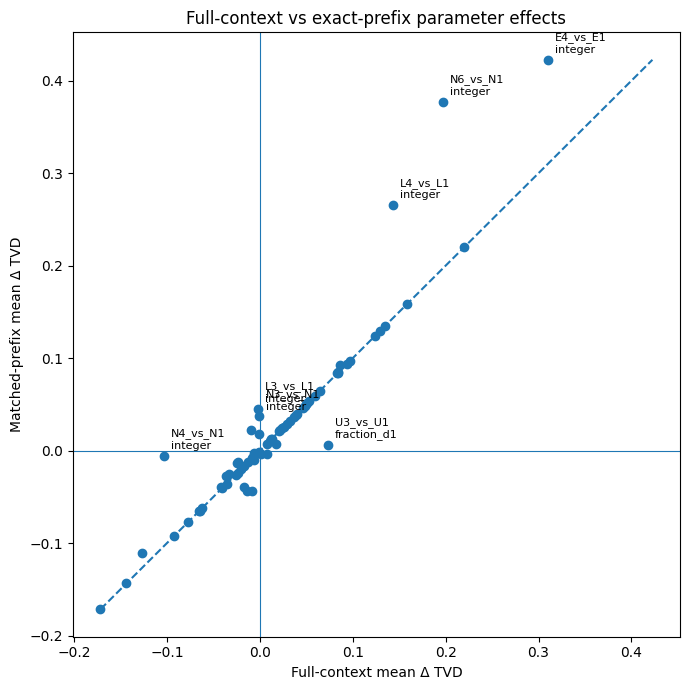

In [160]:
synthesis_plot = (
    anchor_effects
    .dropna(
        subset=["delta_matched"]
    )
    .groupby(
        [
            "contrast_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_full=("delta_full", "mean"),
        mean_matched=("delta_matched", "mean"),
    )
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    synthesis_plot["mean_full"],
    synthesis_plot["mean_matched"],
)

plot_min = min(
    synthesis_plot["mean_full"].min(),
    synthesis_plot["mean_matched"].min(),
)

plot_max = max(
    synthesis_plot["mean_full"].max(),
    synthesis_plot["mean_matched"].max(),
)

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.axvline(
    0,
    linewidth=0.8,
)

LABEL_CASES = set(KEY_MATCHED_CASES)

for _, row in synthesis_plot.iterrows():

    key = (
        row["contrast_id"],
        row["analysis_stage"],
    )

    if key in LABEL_CASES:

        ax.annotate(
            f"{row['contrast_id']}\n"
            f"{row['analysis_stage']}",
            (
                row["mean_full"],
                row["mean_matched"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

ax.set_xlabel(
    "Full-context mean Δ TVD"
)

ax.set_ylabel(
    "Matched-prefix mean Δ TVD"
)

ax.set_title(
    "Full-context vs exact-prefix parameter effects"
)

plt.tight_layout()
plt.show()

### Reading the figure

The diagonal represents equal full-context and matched-prefix effects.

- Points close to the diagonal indicate that changing prefix composition has little influence on the estimated parameter effect.
- Points away from the diagonal indicate that the stage-level effect depends on which numerical prefixes are included.
- Positive points above the diagonal indicate that deterioration is stronger when analysis is restricted to exact shared prefixes.
- Effects that move substantially toward zero after matching are primarily associated with changed numerical-region composition.

## 12.15 — Cross-family interpretation

The matched-prefix analysis separates two forms of parameter sensitivity.

### Same-prefix conditional sensitivity

Normal, Laplace, and Exponential all show the same qualitative pattern under their extreme broad-scale conditions. Integer-stage deterioration remains when the numerical context is held fixed and is larger under exact-prefix matching than in the complete stage average.

This indicates that the extreme-scale effect is not produced merely by the introduction of new large-magnitude numerical contexts. Instead, the models fail to adjust their conditional next-symbol probabilities appropriately even at integer prefixes that remain unchanged from the canonical distribution.

Moderate scale expansion in Normal and Laplace provides a weaker version of the same phenomenon. The full integer-stage average is close to zero, but exact-prefix analysis reveals a small deterioration at the shared integer contexts.

### Changed-region sensitivity

Other parameter manipulations primarily alter the numerical regions represented in the evaluation.

The apparent integer-stage improvement under the positive Normal location shift almost disappears when the exact integer prefix is held fixed. Likewise, most of the Fraction depth-1 deterioration under the Uniform $[0,2]$ condition disappears at the shared fractional prefix.

These effects therefore describe differences between the numerical regions activated by the parameterisation rather than strong changes in alignment at an unchanged prefix.

### Non-matchable effects

Some manipulations move the numerical representation far enough that no exact later-stage comparison is possible. This occurs for Fraction depth 1 under the Normal location shifts and for dot and Fraction depth 1 under the extreme Uniform support expansion.

Such effects remain meaningful as changed-region results but cannot support a same-prefix sensitivity claim.

## 12.16 — Result statement

Exact-prefix analysis distinguished parameter effects that persisted at unchanged numerical contexts from effects associated primarily with changed prefix coverage.

The strongest same-prefix effects occurred under extreme broad-scale manipulations. For Normal N6 versus N1, mean integer-stage TVD increased by approximately $+0.197$ in the full-context comparison and $+0.377$ at the two shared integer prefixes. The corresponding Laplace L4-versus-L1 effect increased from approximately $+0.144$ to $+0.266$, and the Exponential E4-versus-E1 effect increased from approximately $+0.311$ to $+0.423$. In each case, exact-prefix restriction strengthened rather than removed the observed deterioration.

Moderate scale increases showed weaker versions of this pattern. The Normal N3-versus-N1 integer effect changed from approximately $-0.001$ in the full-context comparison to $+0.037$ under matching, while the Laplace L3-versus-L1 effect changed from approximately $-0.002$ to $+0.045$.

Conversely, some apparent stage-level effects were substantially reduced by exact-prefix restriction. The Normal N4-versus-N1 integer effect decreased in magnitude from approximately $-0.103$ to $-0.006$, and the Uniform U3-versus-U1 Fraction depth-1 effect decreased from approximately $+0.074$ to $+0.007$.

No exact Fraction depth-1 comparison was available for the two Normal location shifts, and no exact dot or Fraction depth-1 comparison was available between Uniform $[0,100]$ and $[0,1]$.

## 12.17 — Result conclusion

Parameter sensitivity cannot be interpreted reliably from stage-level averages alone.

Some mathematical manipulations produce genuine local changes in probabilistic alignment at unchanged numerical contexts. This is clearest for extreme increases in target scale: Normal, Laplace, and Exponential all show pronounced integer-stage deterioration at prefixes that are identical to those evaluated under the canonical target. Because these effects become larger under exact-prefix restriction, they cannot be explained by the additional large-magnitude contexts introduced by the broader distributions.

Other apparent parameter effects primarily reflect changes in the numerical regions represented by the new target parameterisation. The positive Normal location-shift integer effect and the moderate Uniform fractional effect largely disappear when prefix identity is held fixed.

The parameter sweep therefore reveals two distinct forms of sensitivity: local conditional sensitivity to changed target mathematics at the same numerical prefix, and changed-region sensitivity caused by the different numerical contexts made relevant by the target parameterisation. Distinguishing these mechanisms is necessary for interpreting stage-level parameter effects.

# 13 — RQ3B × RQ2: Stage Sensitivity

## Research question

When the mathematical properties of the target distribution change, at which numerical stages does probabilistic alignment change?

This analysis extends the stage-level question from the canonical main-grid conditions.

The parameter sweep asks whether the stage profile itself is stable under mathematical changes to location, scale, rate, support, shape, and concentration.

Three phenomena are distinguished:

1. **Stage sensitivity:** alignment at an existing stage changes when the target mathematics changes.
2. **Stage-profile movement:** the stage with the largest alignment error changes under a new parameterisation.
3. **Stage activation:** a parameter manipulation introduces a meaningful numerical branch that was absent or non-informative under the canonical condition.

The primary sensitivity analysis uses exact matched-prefix effects where available. Newly activated stages are analysed separately because no canonical matched-stage effect exists for them.

## 13.1 — Stage-sensitivity measures

Two descriptive summaries are retained.

### Common directional effect

$$
C_{cs}
=
\left|
\frac{1}{M}
\sum_m
\Delta^{\mathrm{matched}}_{mcs}
\right|.
$$

This measures the magnitude of the cross-model mean parameter effect.

### Model-response magnitude

$$
R_{cs}
=
\frac{1}{M}
\sum_m
\left|
\Delta^{\mathrm{matched}}_{mcs}
\right|.
$$

This measures how strongly the evaluated model/protocol conditions respond regardless of direction.

The distinction is important because a stage can be highly sensitive but model-dependent: large positive and negative responses can cancel in the cross-model mean.

In [161]:
stage_effects = (
    anchor_effects
    .dropna(
        subset=["delta_matched"]
    )
    .copy()
)

stage_effects["abs_delta_matched"] = (
    stage_effects["delta_matched"].abs()
)

contrast_stage_effects = (
    stage_effects
    .groupby(
        [
            "distribution",
            "contrast_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_delta=(
            "delta_matched",
            "mean",
        ),
        median_delta=(
            "delta_matched",
            "median",
        ),
        mean_abs_model_delta=(
            "abs_delta_matched",
            "mean",
        ),
        median_abs_model_delta=(
            "abs_delta_matched",
            "median",
        ),
        n_models=(
            "model_id",
            "nunique",
        ),
        n_worse=(
            "delta_matched",
            lambda x: (x > 0).sum(),
        ),
        n_better=(
            "delta_matched",
            lambda x: (x < 0).sum(),
        ),
        n_common=(
            "n_common",
            "first",
        ),
    )
)

contrast_stage_effects[
    "abs_common_effect"
] = (
    contrast_stage_effects[
        "mean_delta"
    ].abs()
)

contrast_stage_effects[
    "direction_consistency"
] = (
    contrast_stage_effects[
        ["n_worse", "n_better"]
    ]
    .max(axis=1)
    / contrast_stage_effects["n_models"]
)

display(
    contrast_stage_effects.head()
)

,distribution,contrast_id,analysis_stage,mean_delta,median_delta,mean_abs_model_delta,median_abs_model_delta,n_models,n_worse,n_better,n_common,abs_common_effect,direction_consistency
0,beta,B1_vs_B2,dot,-0.040209,-0.066150,0.110190,0.082557,6,1,5,1.0,0.040209,0.833333
1,beta,B1_vs_B2,fraction_d1,0.051126,0.065070,0.073526,0.065070,6,4,2,3.0,0.051126,0.666667
2,beta,B1_vs_B2,start,0.220235,0.026435,0.220235,0.026435,6,6,0,1.0,0.220235,1.000000
3,beta,B3_vs_B2,dot,0.064303,0.085005,0.131405,0.124312,6,5,1,1.0,0.064303,0.833333
4,beta,B3_vs_B2,fraction_d1,0.012716,0.005400,0.033779,0.015445,6,4,2,3.0,0.012716,0.666667


In [162]:
stage_sensitivity_summary = (
    contrast_stage_effects
    .groupby(
        "analysis_stage",
        as_index=False,
    )
    .agg(
        n_contrast_cells=(
            "contrast_id",
            "size",
        ),

        median_common_effect=(
            "abs_common_effect",
            "median",
        ),

        mean_common_effect=(
            "abs_common_effect",
            "mean",
        ),

        median_model_response=(
            "mean_abs_model_delta",
            "median",
        ),

        mean_model_response=(
            "mean_abs_model_delta",
            "mean",
        ),

        max_common_effect=(
            "abs_common_effect",
            "max",
        ),

        median_direction_consistency=(
            "direction_consistency",
            "median",
        ),
    )
)

STAGE_LABELS = {
    "start": "ROOT",
    "sign": "Sign",
    "integer": "Integer",
    "dot": "Dot",
    "fraction_d1": "Fraction d1",
}

stage_sensitivity_summary[
    "stage"
] = (
    stage_sensitivity_summary[
        "analysis_stage"
    ].map(STAGE_LABELS)
)

display(
    stage_sensitivity_summary[
        [
            "stage",
            "n_contrast_cells",
            "median_common_effect",
            "median_model_response",
            "max_common_effect",
            "median_direction_consistency",
        ]
    ]
    .sort_values(
        "median_common_effect",
        ascending=False,
    )
    .round(4)
)

,stage,n_contrast_cells,median_common_effect,median_model_response,max_common_effect,median_direction_consistency
4,ROOT,19,0.0772,0.1558,0.2202,0.6667
3,Sign,8,0.0743,0.1889,0.1352,0.5000
2,Integer,11,0.0387,0.0553,0.4226,0.8333
1,Fraction d1,16,0.0243,0.0578,0.0511,0.6667
0,Dot,18,0.0223,0.0824,0.0926,0.6667


In [163]:
strongest_by_stage = (
    contrast_stage_effects
    .sort_values(
        [
            "analysis_stage",
            "abs_common_effect",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "analysis_stage",
        as_index=False,
    )
    .first()
)

strongest_by_stage["stage"] = (
    strongest_by_stage[
        "analysis_stage"
    ].map(STAGE_LABELS)
)

display(
    strongest_by_stage[
        [
            "stage",
            "contrast_id",
            "mean_delta",
            "mean_abs_model_delta",
            "direction_consistency",
            "n_common",
        ]
    ].round(4)
)

,stage,contrast_id,mean_delta,mean_abs_model_delta,direction_consistency,n_common
0,Dot,U3_vs_U1,0.0926,0.1158,0.6667,1.0
1,Fraction d1,B1_vs_B2,0.0511,0.0735,0.6667,3.0
2,Integer,E4_vs_E1,0.4226,0.4406,0.8333,2.0
3,Sign,N5_vs_N1,0.1352,0.2366,0.6667,1.0
4,ROOT,B1_vs_B2,0.2202,0.2202,1.0000,1.0


In [164]:
STAGE_ORDER = [
    "start",
    "sign",
    "integer",
    "dot",
    "fraction_d1",
]

CONTRAST_ORDER = [
    "N2_vs_N1",
    "N3_vs_N1",
    "N4_vs_N1",
    "N5_vs_N1",
    "N6_vs_N1",

    "L2_vs_L1",
    "L3_vs_L1",
    "L4_vs_L1",

    "E2_vs_E1",
    "E3_vs_E1",
    "E4_vs_E1",

    "U2_vs_U1",
    "U3_vs_U1",
    "U4_vs_U1",

    "B1_vs_B2",
    "B3_vs_B2",
    "B4_vs_B2",
    "B5_vs_B2",
    "B6_vs_B2",
]

stage_effect_matrix = (
    contrast_stage_effects
    .pivot(
        index="contrast_id",
        columns="analysis_stage",
        values="mean_delta",
    )
    .reindex(
        index=CONTRAST_ORDER,
        columns=STAGE_ORDER,
    )
)

display(
    stage_effect_matrix.round(3)
)

analysis_stage,start,sign,integer,dot,fraction_d1
contrast_id,,,,,
N2_vs_N1,0.024,-0.065,0.029,0.048,-0.025
N3_vs_N1,-0.065,0.084,0.037,-0.012,0.007
N4_vs_N1,-0.143,0.085,-0.006,-0.044,NaN
N5_vs_N1,-0.171,0.135,-0.110,0.018,NaN
N6_vs_N1,-0.013,0.050,0.377,-0.017,-0.002
L2_vs_L1,0.053,-0.093,0.039,-0.008,-0.040
L3_vs_L1,-0.020,0.059,0.045,-0.013,-0.003
L4_vs_L1,0.012,-0.017,0.266,-0.011,-0.004
E2_vs_E1,-0.062,NaN,0.037,0.026,-0.026


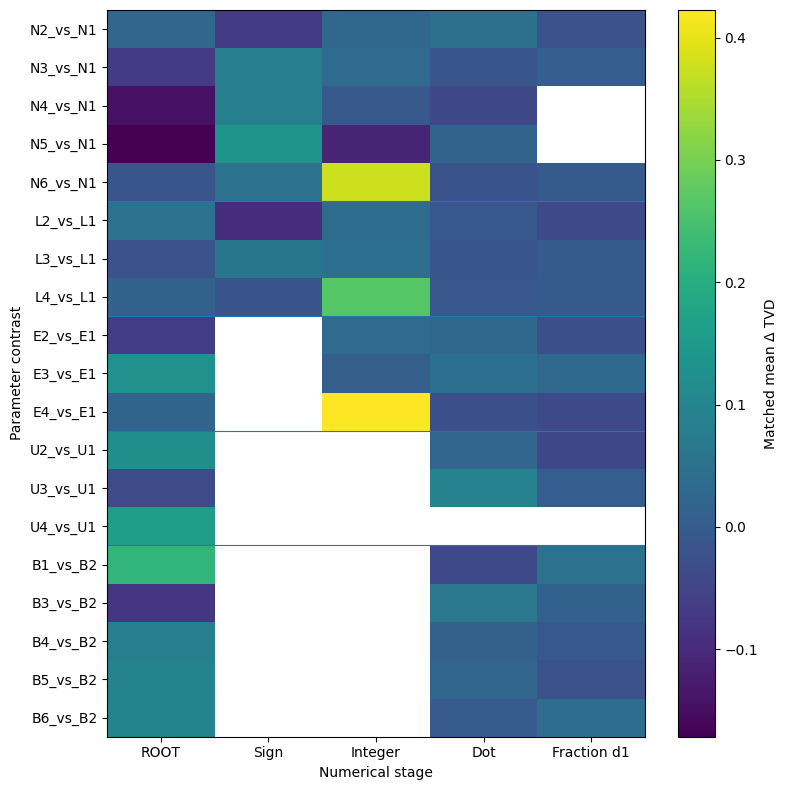

In [165]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    stage_effect_matrix.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(len(STAGE_ORDER))
)

ax.set_xticklabels(
    [
        "ROOT",
        "Sign",
        "Integer",
        "Dot",
        "Fraction d1",
    ]
)

ax.set_yticks(
    range(len(CONTRAST_ORDER))
)

ax.set_yticklabels(
    CONTRAST_ORDER
)

for boundary in [
    4.5,
    7.5,
    10.5,
    13.5,
]:
    ax.axhline(
        boundary,
        linewidth=0.8,
    )

ax.set_xlabel(
    "Numerical stage"
)

ax.set_ylabel(
    "Parameter contrast"
)

fig.colorbar(
    im,
    ax=ax,
    label="Matched mean Δ TVD",
)

plt.tight_layout()
plt.show()

In [166]:
primary_for_stage = prefix[
    prefix["primary_alignment_row"]
].copy()

absolute_stage_model = (
    primary_for_stage
    .groupby(
        [
            "distribution",
            "parameter_id",
            "model_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        stage_tvd=(
            "tv_analytic_lm",
            "mean",
        )
    )
)

absolute_stage_parameter = (
    absolute_stage_model
    .groupby(
        [
            "distribution",
            "parameter_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_stage_tvd=(
            "stage_tvd",
            "mean",
        ),
        median_stage_tvd=(
            "stage_tvd",
            "median",
        ),
    )
)

In [167]:
dominant_stage = (
    absolute_stage_parameter
    .sort_values(
        [
            "parameter_id",
            "mean_stage_tvd",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "parameter_id",
        as_index=False,
    )
    .first()
)

display(
    dominant_stage[
        [
            "distribution",
            "parameter_id",
            "analysis_stage",
            "mean_stage_tvd",
        ]
    ]
    .sort_values(
        [
            "distribution",
            "parameter_id",
        ]
    )
    .round(4)
)

,distribution,parameter_id,analysis_stage,mean_stage_tvd
0,beta,B1,start,0.5844
1,beta,B2,dot,0.5542
2,beta,B3,dot,0.6185
3,beta,B4,dot,0.5651
4,beta,B5,dot,0.5765
5,beta,B6,dot,0.5530
6,exponential,E1,start,0.4889
7,exponential,E2,dot,0.4368
8,exponential,E3,start,0.6179
9,exponential,E4,start,0.5100


In [168]:
ANCHORS = {
    "normal": "N1",
    "laplace": "L1",
    "exponential": "E1",
    "uniform": "U1",
    "beta": "B2",
}

dominant_lookup = (
    dominant_stage
    .set_index("parameter_id")
)

stage_shift_rows = []

for target_id, reference_id in [
    ("N2", "N1"),
    ("N3", "N1"),
    ("N4", "N1"),
    ("N5", "N1"),
    ("N6", "N1"),

    ("L2", "L1"),
    ("L3", "L1"),
    ("L4", "L1"),

    ("E2", "E1"),
    ("E3", "E1"),
    ("E4", "E1"),

    ("U2", "U1"),
    ("U3", "U1"),
    ("U4", "U1"),

    ("B1", "B2"),
    ("B3", "B2"),
    ("B4", "B2"),
    ("B5", "B2"),
    ("B6", "B2"),
]:

    target = dominant_lookup.loc[
        target_id
    ]

    reference = dominant_lookup.loc[
        reference_id
    ]

    stage_shift_rows.append({
        "distribution":
            target["distribution"],

        "contrast_id":
            f"{target_id}_vs_{reference_id}",

        "reference_dominant_stage":
            reference["analysis_stage"],

        "target_dominant_stage":
            target["analysis_stage"],

        "stage_shift":
            (
                target["analysis_stage"]
                !=
                reference["analysis_stage"]
            ),
    })

dominant_stage_shift = pd.DataFrame(
    stage_shift_rows
)

display(
    dominant_stage_shift
)

,distribution,contrast_id,reference_dominant_stage,target_dominant_stage,stage_shift
0,normal,N2_vs_N1,start,start,False
1,normal,N3_vs_N1,start,start,False
2,normal,N4_vs_N1,start,fraction_d1,True
3,normal,N5_vs_N1,start,dot,True
4,normal,N6_vs_N1,start,start,False
5,laplace,L2_vs_L1,dot,start,True
6,laplace,L3_vs_L1,dot,dot,False
7,laplace,L4_vs_L1,dot,start,True
8,exponential,E2_vs_E1,start,dot,True
9,exponential,E3_vs_E1,start,start,False


In [169]:
stage_ranked = (
    absolute_stage_parameter
    .sort_values(
        [
            "parameter_id",
            "mean_stage_tvd",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .copy()
)

stage_ranked["stage_rank"] = (
    stage_ranked
    .groupby(
        "parameter_id"
    )
    .cumcount()
    + 1
)

top_stage = (
    stage_ranked[
        stage_ranked["stage_rank"] == 1
    ][
        [
            "parameter_id",
            "analysis_stage",
            "mean_stage_tvd",
        ]
    ]
    .rename(
        columns={
            "analysis_stage":
                "top_stage",
            "mean_stage_tvd":
                "top_tvd",
        }
    )
)

second_stage = (
    stage_ranked[
        stage_ranked["stage_rank"] == 2
    ][
        [
            "parameter_id",
            "analysis_stage",
            "mean_stage_tvd",
        ]
    ]
    .rename(
        columns={
            "analysis_stage":
                "second_stage",
            "mean_stage_tvd":
                "second_tvd",
        }
    )
)

dominance_margin = (
    top_stage
    .merge(
        second_stage,
        on="parameter_id",
        how="inner",
    )
)

dominance_margin[
    "dominance_margin"
] = (
    dominance_margin["top_tvd"]
    - dominance_margin["second_tvd"]
)

display(
    dominance_margin
    .sort_values(
        "dominance_margin"
    )
    .round(4)
)

,parameter_id,top_stage,top_tvd,second_stage,second_tvd,dominance_margin
23,U4,dot,0.4509,start,0.4475,0.0034
12,L3,dot,0.3911,start,0.3867,0.0043
10,L1,dot,0.4151,start,0.4065,0.0086
13,L4,start,0.4186,dot,0.4090,0.0096
18,N5,dot,0.4050,sign,0.3953,0.0097
7,E2,dot,0.4368,start,0.4267,0.0101
16,N3,start,0.3934,dot,0.3830,0.0103
22,U3,fraction_d1,0.5392,dot,0.5270,0.0122
21,U2,fraction_d1,0.4516,dot,0.4317,0.0199
17,N4,fraction_d1,0.4181,dot,0.3976,0.0205


In [170]:
stage_presence = (
    primary_for_stage[
        [
            "distribution",
            "parameter_id",
            "analysis_stage",
        ]
    ]
    .drop_duplicates()
    .assign(
        present=True
    )
    .pivot_table(
        index=[
            "distribution",
            "parameter_id",
        ],
        columns="analysis_stage",
        values="present",
        aggfunc="first",
        fill_value=False,
    )
)

display(
    stage_presence
)

analysis_stage              dot  fraction_d1  integer   sign  start
distribution parameter_id                                          
beta         B1            True         True    False  False   True
             B2            True         True    False  False   True
             B3            True         True    False  False   True
             B4            True         True    False  False   True
             B5            True         True    False  False   True
             B6            True         True    False  False   True
exponential  E1            True         True     True  False   True
             E2            True         True     True  False   True
             E3            True         True     True  False   True
             E4            True         True     True  False   True
laplace      L1            True         True     True   True   True
             L2            True         True     True   True   True
             L3            True         True     True   True   True
             L4            True         True     True   True   True
normal       N1            True         True     True   True   True
             N2            True         True     True   True   True
             N3            True         True     True   True   True
             N4            True         True     True   True   True
             N5            True         True     True   True   True
             N6            True         True     True   True   True
uniform      U1            True         True    False  False   True
             U2            True         True    False   True   True
             U3            True         True     True  False   True
             U4            True         True     True  False   True

In [171]:
uniform_stage_activation = (
    absolute_stage_parameter[
        (
            (
                absolute_stage_parameter[
                    "parameter_id"
                ] == "U2"
            )
            &
            (
                absolute_stage_parameter[
                    "analysis_stage"
                ] == "sign"
            )
        )
        |
        (
            (
                absolute_stage_parameter[
                    "parameter_id"
                ].isin(
                    ["U3", "U4"]
                )
            )
            &
            (
                absolute_stage_parameter[
                    "analysis_stage"
                ] == "integer"
            )
        )
    ]
)

display(
    uniform_stage_activation[
        [
            "parameter_id",
            "analysis_stage",
            "mean_stage_tvd",
            "median_stage_tvd",
        ]
    ].round(4)
)

,parameter_id,analysis_stage,mean_stage_tvd,median_stage_tvd
89,U2,sign,0.3271,0.0342
93,U3,integer,0.0946,0.0047
97,U4,integer,0.3928,0.2860


## 13.16 — Result statement

The stage profile of parameter sensitivity was heterogeneous rather than dominated by a single numerical stage.

Across canonical parameter contrasts with exact-prefix comparisons, ROOT showed the largest typical common-direction effect, with a median absolute cross-model mean $\Delta$TVD of approximately $0.077$. The sign stage showed a similar median common effect of approximately $0.074$ but the largest typical model-response magnitude, approximately $0.189$, while its median directional consistency was only $0.50$, indicating substantial disagreement across model/protocol conditions.

Integer-stage effects were smaller for a typical parameter contrast, with a median absolute common effect of approximately $0.039$. However, the integer stage contained the largest parameter effects observed in the synthesis. Matched integer-stage TVD increased by approximately $+0.423$ for Exponential E4 versus E1, $+0.377$ for Normal N6 versus N1, and $+0.266$ for Laplace L4 versus L1. These extreme-scale effects were directionally consistent in five of six model/protocol conditions.

Dot and Fraction depth-1 stages showed smaller typical common stage-level effects, with median absolute values of approximately $0.022$ and $0.024$, respectively. These aggregate values do not imply prefix-level invariance, since the Beta analyses showed that substantial but opposing fractional-prefix effects can cancel within a stage mean.

The stage with the largest absolute mean TVD differed from the corresponding canonical condition for several parameter settings, although multiple changes involved near-tied stages. Support changes also altered stage availability: Uniform $[-1,1]$ introduced an informative sign branch with mean TVD approximately $0.327$, while Uniform $[0,2]$ and $[0,100]$ introduced informative integer decisions with mean TVD approximately $0.095$ and $0.393$, respectively.

## 13.17 — Result conclusion

The location of probabilistic alignment failure is not fixed under changes to the target mathematics.

ROOT is broadly responsive to parameter changes, while sign-stage sensitivity is comparatively large but strongly dependent on model/protocol condition. Integer-stage alignment shows a different pattern: ordinary parameter changes typically produce modest effects, but extreme increases in numerical scale lead to the largest and most directionally consistent same-prefix deterioration observed in the parameter sweep. This indicates a specific vulnerability of integer-level probability allocation when the target distribution becomes very broad.

Dot and fractional stages are comparatively stable at the aggregate stage level, but this stability can conceal substantial prefix-specific sensitivity, as demonstrated by the Beta shape and skew analyses. In addition, support changes can alter the numerical prediction process itself by activating sign or informative integer branches that are absent under the canonical target.

Therefore, RQ2 cannot be answered by assigning a single universally difficult stage. Parameter changes can alter both the severity and the location of alignment failure, and the resulting stage profile depends on the mathematical property being manipulated.

# 14 — RQ3B × RQ4: Model/Protocol Robustness

## Research question

How consistently do parameter-induced changes in probabilistic alignment appear across the evaluated model and protocol conditions?

The six evaluated conditions are:

- S1: Qwen3-4B Base, raw-direct
- S2: Qwen3-4B Instruct, raw-direct
- S3: Qwen3-4B Instruct, chat-direct
- S4: Gemma-4-E4B Base, raw-direct
- S5: Gemma-4-E4B-IT, raw-direct
- S6: Gemma-4-E4B-IT, chat-direct

This analysis does not treat the six conditions as independent samples from a population of language models and does not attempt to rank models.

Instead, it asks whether the parameter effects established in the preceding analyses are:

1. directionally shared across the evaluated conditions;
2. strongly heterogeneous in magnitude or direction;
3. dominated by an individual model/protocol condition; or
4. altered by raw-direct versus chat-direct prompting within the same instruction-tuned model.

Matched-prefix parameter effects are used wherever exact-prefix comparison is available.

In [172]:
model_effect_matrix = (
    anchor_effects
    .dropna(
        subset=["delta_matched"]
    )
    .pivot(
        index=[
            "contrast_id",
            "analysis_stage",
        ],
        columns="model_id",
        values="delta_matched",
    )
    .reindex(
        columns=[
            "S1",
            "S2",
            "S3",
            "S4",
            "S5",
            "S6",
        ]
    )
)

print(
    "Matched contrast-stage cells:",
    len(model_effect_matrix)
)

display(
    model_effect_matrix.head().round(4)
)

Matched contrast-stage cells: 72


model_id                        S1      S2      S3      S4      S5      S6
contrast_id analysis_stage                                                
B1_vs_B2    dot            -0.0598 -0.0926 -0.1722 -0.0541 -0.0725  0.2099
            fraction_d1    -0.0497  0.0633  0.1035 -0.0175  0.0668  0.1403
            start           0.0405  0.2609  0.9994  0.0124  0.0078  0.0005
B3_vs_B2    dot             0.0361  0.2293  0.0731  0.0969 -0.2013  0.1517
            fraction_d1    -0.0521  0.0198 -0.0110  0.1088  0.0076  0.0032

In [173]:
model_robustness = (
    anchor_effects
    .dropna(
        subset=["delta_matched"]
    )
    .assign(
        abs_delta=lambda x:
            x["delta_matched"].abs()
    )
    .groupby(
        [
            "contrast_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_effect=(
            "delta_matched",
            "mean",
        ),
        median_effect=(
            "delta_matched",
            "median",
        ),
        mean_abs_effect=(
            "abs_delta",
            "mean",
        ),
        median_abs_effect=(
            "abs_delta",
            "median",
        ),
        min_effect=(
            "delta_matched",
            "min",
        ),
        max_effect=(
            "delta_matched",
            "max",
        ),
        n_worse=(
            "delta_matched",
            lambda x: (x > 0).sum(),
        ),
        n_better=(
            "delta_matched",
            lambda x: (x < 0).sum(),
        ),
    )
)

model_robustness[
    "majority_direction_count"
] = (
    model_robustness[
        ["n_worse", "n_better"]
    ].max(axis=1)
)

model_robustness[
    "effect_range"
] = (
    model_robustness["max_effect"]
    - model_robustness["min_effect"]
)

display(
    model_robustness.head().round(4)
)

,contrast_id,analysis_stage,mean_effect,median_effect,mean_abs_effect,median_abs_effect,min_effect,max_effect,n_worse,n_better,majority_direction_count,effect_range
0,B1_vs_B2,dot,-0.0402,-0.0662,0.1102,0.0826,-0.1722,0.2099,1,5,5,0.3821
1,B1_vs_B2,fraction_d1,0.0511,0.0651,0.0735,0.0651,-0.0497,0.1403,4,2,4,0.1900
2,B1_vs_B2,start,0.2202,0.0264,0.2202,0.0264,0.0005,0.9994,6,0,6,0.9989
3,B3_vs_B2,dot,0.0643,0.0850,0.1314,0.1243,-0.2013,0.2293,5,1,5,0.4306
4,B3_vs_B2,fraction_d1,0.0127,0.0054,0.0338,0.0154,-0.0521,0.1088,4,2,4,0.1610


In [174]:
direction_consistency_counts = (
    model_robustness[
        "majority_direction_count"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "largest_same-direction_group"
    )
    .to_frame(
        "contrast_stage_cells"
    )
)

display(
    direction_consistency_counts
)

,contrast_stage_cells
largest_same-direction_group,
3,20
4,37
5,12
6,3


## 14.4 — Direction counts require effect-size context

A 6-of-6 directional result does not necessarily imply a large or broadly distributed effect.

For example, all six conditions can have the same sign while five effects are close to zero and one condition contributes almost the entire cross-model mean.

Therefore, direction counts are interpreted jointly with the cross-model median and individual model-level effects.

In [175]:
display(
    model_effect_matrix
    .loc[
        [
            (
                "B1_vs_B2",
                "start",
            )
        ]
    ]
    .round(4)
)

,model_id,S1,S2,S3,S4,S5,S6
contrast_id,analysis_stage,,,,,,
B1_vs_B2,start,0.0405,0.2609,0.9994,0.0124,0.0078,0.0005


In [176]:
display(
    model_effect_matrix
    .loc[
        [
            (
                "N5_vs_N1",
                "integer",
            )
        ]
    ]
    .round(4)
)

,model_id,S1,S2,S3,S4,S5,S6
contrast_id,analysis_stage,,,,,,
N5_vs_N1,integer,-0.0118,-0.0001,-0.0,-0.0388,-0.6121,-0.0


### Robustness interpretation rule

Directional agreement is not sufficient by itself.

A parameter effect is interpreted as broadly shared only when its direction is reasonably consistent **and** its magnitude is not produced almost entirely by one evaluated condition.

Cross-model means are therefore interpreted together with medians and individual condition-level effects.

In [177]:
EXTREME_SCALE_INTEGER = [
    ("N6_vs_N1", "integer"),
    ("L4_vs_L1", "integer"),
    ("E4_vs_E1", "integer"),
]

extreme_scale_integer = (
    model_effect_matrix
    .loc[
        EXTREME_SCALE_INTEGER
    ]
)

display(
    extreme_scale_integer.round(4)
)

,model_id,S1,S2,S3,S4,S5,S6
contrast_id,analysis_stage,,,,,,
N6_vs_N1,integer,0.1922,0.5856,0.7937,0.1215,-0.1220,0.6919
L4_vs_L1,integer,0.1509,0.2657,0.7728,0.1611,-0.0037,0.2462
E4_vs_E1,integer,0.1568,0.6185,0.6913,-0.0540,0.4969,0.6259


In [178]:
extreme_scale_summary = (
    anchor_effects[
        anchor_effects[
            ["contrast_id", "analysis_stage"]
        ]
        .apply(
            tuple,
            axis=1,
        )
        .isin(
            EXTREME_SCALE_INTEGER
        )
    ]
    .groupby(
        [
            "contrast_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_effect=(
            "delta_matched",
            "mean",
        ),
        median_effect=(
            "delta_matched",
            "median",
        ),
        min_effect=(
            "delta_matched",
            "min",
        ),
        max_effect=(
            "delta_matched",
            "max",
        ),
        n_worse=(
            "delta_matched",
            lambda x: (x > 0).sum(),
        ),
        n_better=(
            "delta_matched",
            lambda x: (x < 0).sum(),
        ),
    )
)

display(
    extreme_scale_summary.round(4)
)

,contrast_id,analysis_stage,mean_effect,median_effect,min_effect,max_effect,n_worse,n_better
0,E4_vs_E1,integer,0.4226,0.5577,-0.0540,0.6913,5,1
1,L4_vs_L1,integer,0.2655,0.2036,-0.0037,0.7728,5,1
2,N6_vs_N1,integer,0.3771,0.3889,-0.1220,0.7937,5,1


## 14.9 — Extreme-scale robustness

The extreme-scale integer deterioration is comparatively robust across the evaluated model/protocol conditions.

Normal N6, Laplace L4, and Exponential E4 each increase matched integer-stage TVD in five of six conditions. Their cross-condition medians are approximately $+0.389$, $+0.204$, and $+0.558$, respectively, indicating that the effects are not generated solely by individual outlying conditions.

The exceptional condition is also not identical across all three families: S5 moves in the opposite direction for Normal N6 and is approximately unchanged for Laplace L4, whereas S4 is the exception for Exponential E4.

Thus, the cross-family extreme-scale integer effect is shared broadly across the evaluated conditions despite substantial variation in magnitude.

In [179]:
HETEROGENEOUS_CASES = [
    ("N4_vs_N1", "sign"),
    ("U3_vs_U1", "start"),
    ("E4_vs_E1", "start"),
    ("U2_vs_U1", "start"),
]

heterogeneous_examples = (
    model_effect_matrix
    .loc[
        HETEROGENEOUS_CASES
    ]
)

display(
    heterogeneous_examples.round(4)
)

,model_id,S1,S2,S3,S4,S5,S6
contrast_id,analysis_stage,,,,,,
N4_vs_N1,sign,0.2837,-0.2652,-0.2630,0.2596,0.7498,-0.2569
U3_vs_U1,start,-0.0774,0.0628,0.4995,-0.4728,-0.4574,0.2306
E4_vs_E1,start,0.3600,-0.3957,-0.0584,-0.2818,-0.0296,0.5320
U2_vs_U1,start,-0.0912,0.4204,0.4982,-0.1211,-0.0854,0.1222


In [180]:
model_robustness[
    "cancellation_ratio"
] = (
    model_robustness[
        "mean_effect"
    ].abs()
    /
    model_robustness[
        "mean_abs_effect"
    ]
)

display(
    model_robustness[
        [
            "contrast_id",
            "analysis_stage",
            "mean_effect",
            "mean_abs_effect",
            "cancellation_ratio",
            "n_worse",
            "n_better",
        ]
    ]
    .sort_values(
        "mean_abs_effect",
        ascending=False,
    )
    .head(15)
    .round(4)
)

,contrast_id,analysis_stage,mean_effect,mean_abs_effect,cancellation_ratio,n_worse,n_better
25,E4_vs_E1,integer,0.4226,0.4406,0.9591,5,1
62,N6_vs_N1,integer,0.3771,0.4178,0.9027,5,1
54,N4_vs_N1,sign,0.0847,0.3464,0.2444,3,3
70,U3_vs_U1,start,-0.0358,0.3001,0.1192,3,3
71,U4_vs_U1,start,0.1589,0.2884,0.5511,4,2
26,E4_vs_E1,start,0.0211,0.2762,0.0763,2,4
39,L4_vs_L1,integer,0.2655,0.2667,0.9954,5,1
59,N5_vs_N1,start,-0.1714,0.2501,0.6853,2,4
58,N5_vs_N1,sign,0.1352,0.2366,0.5712,4,2
67,U2_vs_U1,start,0.1239,0.2231,0.5552,3,3


### Cancellation diagnostic

The cancellation ratio is used only descriptively:

$$
R_{\mathrm{cancel}}
=
\frac{
\left|
\frac{1}{M}\sum_m \Delta_m
\right|
}{
\frac{1}{M}\sum_m |\Delta_m|
}.
$$

Values near $1$ indicate that condition-level effects largely reinforce one another.

Values near $0$ indicate that substantial positive and negative effects cancel in the cross-model mean.

This diagnostic is not introduced as a thesis evaluation metric; it is used only to distinguish genuinely small parameter effects from heterogeneous effects whose average is small.

In [181]:
protocol_effects = (
    anchor_effects
    .dropna(
        subset=["delta_matched"]
    )
    .pivot(
        index=[
            "contrast_id",
            "analysis_stage",
        ],
        columns="model_id",
        values="delta_matched",
    )
)

# Same Qwen3-4B Instruct model
qwen_protocol = (
    protocol_effects[
        ["S2", "S3"]
    ]
    .copy()
)

qwen_protocol[
    "chat_minus_raw"
] = (
    qwen_protocol["S3"]
    - qwen_protocol["S2"]
)

qwen_protocol[
    "abs_protocol_difference"
] = (
    qwen_protocol[
        "chat_minus_raw"
    ].abs()
)

# Same Gemma IT model
gemma_protocol = (
    protocol_effects[
        ["S5", "S6"]
    ]
    .copy()
)

gemma_protocol[
    "chat_minus_raw"
] = (
    gemma_protocol["S6"]
    - gemma_protocol["S5"]
)

gemma_protocol[
    "abs_protocol_difference"
] = (
    gemma_protocol[
        "chat_minus_raw"
    ].abs()
)

In [182]:
def summarise_protocol_difference(
    df,
):
    temp = (
        df
        .reset_index()
    )

    return (
        temp
        .groupby(
            "analysis_stage"
        )
        .agg(
            n_cells=(
                "contrast_id",
                "size",
            ),
            median_abs_difference=(
                "abs_protocol_difference",
                "median",
            ),
            mean_abs_difference=(
                "abs_protocol_difference",
                "mean",
            ),
        )
        .reset_index()
    )


qwen_protocol_summary = (
    summarise_protocol_difference(
        qwen_protocol
    )
)

gemma_protocol_summary = (
    summarise_protocol_difference(
        gemma_protocol
    )
)

print("Qwen Instruct: raw vs chat")
display(
    qwen_protocol_summary.round(4)
)

print("Gemma IT: raw vs chat")
display(
    gemma_protocol_summary.round(4)
)

Qwen Instruct: raw vs chat


,analysis_stage,n_cells,median_abs_difference,mean_abs_difference
0,dot,18,0.0833,0.0985
1,fraction_d1,16,0.0809,0.1021
2,integer,11,0.0001,0.0717
3,sign,8,0.1472,0.2390
4,start,19,0.2030,0.2957


Gemma IT: raw vs chat


,analysis_stage,n_cells,median_abs_difference,mean_abs_difference
0,dot,18,0.1432,0.1346
1,fraction_d1,16,0.0677,0.0784
2,integer,11,0.1702,0.2599
3,sign,8,0.3929,0.3890
4,start,19,0.2093,0.2788


In [183]:
extreme_protocol = (
    protocol_effects
    .loc[
        EXTREME_SCALE_INTEGER
    ][
        [
            "S2",
            "S3",
            "S5",
            "S6",
        ]
    ]
    .copy()
)

extreme_protocol[
    "Qwen_chat_minus_raw"
] = (
    extreme_protocol["S3"]
    - extreme_protocol["S2"]
)

extreme_protocol[
    "Gemma_chat_minus_raw"
] = (
    extreme_protocol["S6"]
    - extreme_protocol["S5"]
)

display(
    extreme_protocol.round(4)
)

,model_id,S2,S3,S5,S6,Qwen_chat_minus_raw,Gemma_chat_minus_raw
contrast_id,analysis_stage,,,,,,
N6_vs_N1,integer,0.5856,0.7937,-0.1220,0.6919,0.2081,0.8139
L4_vs_L1,integer,0.2657,0.7728,-0.0037,0.2462,0.5071,0.2498
E4_vs_E1,integer,0.6185,0.6913,0.4969,0.6259,0.0728,0.1290


### Extreme-scale protocol interaction

Within the three extreme-scale integer contrasts identified independently in the family analyses, the chat-direct condition produced a larger matched TVD deterioration than the corresponding raw-direct condition for both instruction-tuned models.

This pattern occurred for Normal N6, Laplace L4, and Exponential E4.

The result is treated as a consistent interaction within this evaluated subset rather than as a general claim that chat formatting necessarily increases parameter sensitivity in language models.

In [184]:
extreme_variant = (
    protocol_effects
    .loc[
        EXTREME_SCALE_INTEGER
    ][
        [
            "S1",
            "S2",
            "S4",
            "S5",
        ]
    ]
)

display(
    extreme_variant.round(4)
)

,model_id,S1,S2,S4,S5
contrast_id,analysis_stage,,,,
N6_vs_N1,integer,0.1922,0.5856,0.1215,-0.1220
L4_vs_L1,integer,0.1509,0.2657,0.1611,-0.0037
E4_vs_E1,integer,0.1568,0.6185,-0.0540,0.4969


## 14.18 — Model and variant dependence

Parameter sensitivity cannot be characterised by a single model-independent effect.

Some parameter manipulations produce substantial responses in opposite directions across the evaluated conditions, particularly at ROOT and sign. Other apparently directionally consistent effects have highly unequal magnitudes and can be dominated by an individual condition.

The extreme-scale integer failure is an important exception. Normal N6, Laplace L4, and Exponential E4 each deteriorate in five of six conditions and have sizeable cross-condition medians, showing that this result is not attributable to a single model or protocol.

Model variant also modulates the effect, but not uniformly across families. Qwen3-4B Instruct under raw-direct prompting shows a larger extreme-scale integer deterioration than Qwen3-4B Base in all three families, whereas the corresponding Gemma Base-versus-IT comparison is mixed. The current experiment therefore does not support a general claim that instruction tuning either increases or decreases mathematical parameter sensitivity.

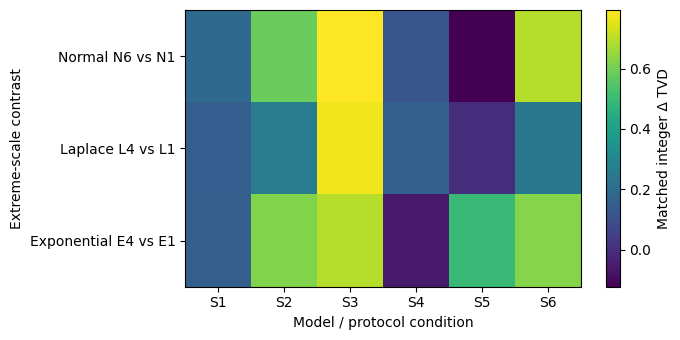

In [185]:
extreme_plot = (
    extreme_scale_integer
    .reindex(
        columns=[
            "S1",
            "S2",
            "S3",
            "S4",
            "S5",
            "S6",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(7, 3.5)
)

im = ax.imshow(
    extreme_plot.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(
        len(
            extreme_plot.columns
        )
    )
)

ax.set_xticklabels(
    extreme_plot.columns
)

ax.set_yticks(
    range(
        len(
            extreme_plot.index
        )
    )
)

ax.set_yticklabels(
    [
        "Normal N6 vs N1",
        "Laplace L4 vs L1",
        "Exponential E4 vs E1",
    ]
)

ax.set_xlabel(
    "Model / protocol condition"
)

ax.set_ylabel(
    "Extreme-scale contrast"
)

fig.colorbar(
    im,
    ax=ax,
    label="Matched integer Δ TVD",
)

plt.tight_layout()
plt.show()

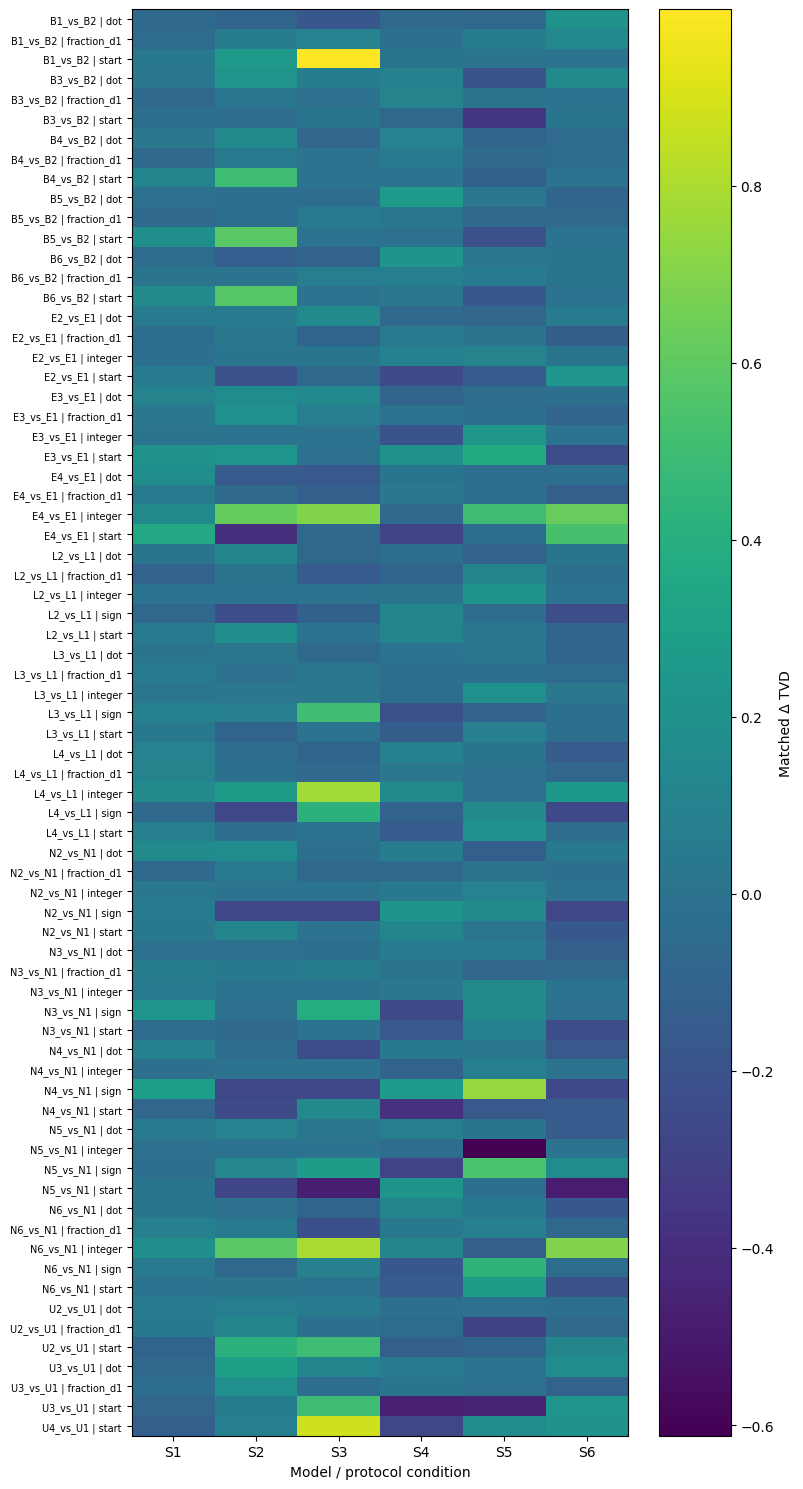

In [186]:
all_model_effects = (
    anchor_effects
    .dropna(
        subset=["delta_matched"]
    )
    .pivot(
        index=[
            "contrast_id",
            "analysis_stage",
        ],
        columns="model_id",
        values="delta_matched",
    )
    .reindex(
        columns=[
            "S1",
            "S2",
            "S3",
            "S4",
            "S5",
            "S6",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8, 15)
)

im = ax.imshow(
    all_model_effects.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(6)
)

ax.set_xticklabels(
    [
        "S1",
        "S2",
        "S3",
        "S4",
        "S5",
        "S6",
    ]
)

ax.set_yticks(
    range(
        len(
            all_model_effects.index
        )
    )
)

ax.set_yticklabels(
    [
        f"{contrast} | {stage}"
        for contrast, stage
        in all_model_effects.index
    ],
    fontsize=7,
)

ax.set_xlabel(
    "Model / protocol condition"
)

fig.colorbar(
    im,
    ax=ax,
    label="Matched Δ TVD",
)

plt.tight_layout()
plt.show()

## 14.21 — Result statement

Parameter-induced changes in alignment showed substantial heterogeneity across the six evaluated model/protocol conditions. Across the 72 canonical contrast-stage cells with exact-prefix estimates, only three had the same nominal effect direction in all six conditions, twelve had the same direction in five of six, thirty-seven had a four-versus-two split, and twenty divided three-versus-three. Direction counts alone were insufficient to establish robustness because several apparently unanimous effects had strongly unequal magnitudes.

For example, the Beta B1-versus-B2 ROOT effect was positive in all six conditions, but its cross-condition mean of approximately $+0.220$ was accompanied by a median of only $+0.026$, with S3 contributing an effect of approximately $+0.999$. Similarly, the N5-versus-N1 matched integer effect was negative in all six conditions but had a mean of approximately $-0.110$ and a median of only $-0.006$, with S5 contributing approximately $-0.612$.

In contrast, the extreme-scale integer effects were broadly shared. Normal N6, Laplace L4, and Exponential E4 increased matched integer-stage TVD in five of six conditions, with cross-condition means of approximately $+0.377$, $+0.266$, and $+0.423$ and medians of approximately $+0.389$, $+0.204$, and $+0.558$, respectively. The exceptional condition was not identical across all three families.

Prompt protocol also modulated parameter sensitivity. Within the same Qwen Instruct and Gemma IT models, raw-direct and chat-direct conditions often produced materially different parameter effects. Within the three extreme-scale integer contrasts, chat-direct produced a larger TVD deterioration than raw-direct for both instruction-tuned models in all three families. However, protocol effects outside this subset varied in both magnitude and direction.

Raw-direct Base-versus-Instruct comparisons likewise differed by model family. Qwen Instruct showed larger extreme-scale integer effects than Qwen Base in all three families, whereas the corresponding Gemma Base-versus-IT pattern was mixed.

## 14.22 — Result conclusion

Parameter sensitivity is neither completely model-invariant nor reducible to isolated model-specific behaviour.

Many parameter effects are strongly heterogeneous across model and protocol conditions. Near-zero cross-model averages can conceal large opposing responses, while nominally unanimous directional effects can be dominated by a single condition. Consequently, model-averaged parameter effects must be interpreted together with their condition-level distributions.

The extreme-scale integer failure is a notable exception to this general heterogeneity. Broadening Normal, Laplace, and Exponential targets to their extreme evaluated scales produces substantial same-prefix integer deterioration across five of six conditions in each family, with sizeable median effects. This provides evidence that the extreme-scale vulnerability identified in RQ3B is not an artefact of one particular model or protocol.

At the same time, raw-versus-chat comparisons show that prompting protocol can substantially alter the magnitude and sometimes the direction of parameter sensitivity within the same instruction-tuned model. The consistent amplification of the three extreme-scale integer effects under chat-direct prompting is therefore retained as a specific model-protocol interaction, while the broader parameter sweep does not support a general claim that chat prompting or instruction tuning uniformly improves or worsens probabilistic alignment.

# 15 — RQ1 Robustness Across Parameterisations

## Purpose

The main-grid analysis established that the evaluated language models do not generally reproduce the analytical next-symbol probability distributions implied by the target numerical distributions.

The parameter sweep tests whether this basic misalignment phenomenon is restricted to the canonical distribution settings or remains present when mathematically meaningful parameters such as scale, location, rate, support, and shape are changed.

This section therefore considers absolute TVD rather than parameter-effect deltas.

Because stage availability and prefix counts differ across parameter settings, raw pooling of all prefix rows is avoided.

## 15.1 — Common-stage robustness summary

For a compact comparison across all parameter settings, the analysis uses the three informative stages present in every model × parameter condition:

- ROOT,
- dot,
- Fraction depth 1.

For each model/protocol condition $m$ and parameter setting $p$, mean TVD is first calculated independently within each stage. The three stage means are then averaged with equal weight:

$$
\mathrm{TVD}^{\mathrm{core}}_{mp}
=
\frac{1}{3}
\left(
\overline{\mathrm{TVD}}_{mp,\mathrm{ROOT}}
+
\overline{\mathrm{TVD}}_{mp,\mathrm{dot}}
+
\overline{\mathrm{TVD}}_{mp,\mathrm{fraction\ d1}}
\right).
$$

This stage-balanced quantity is used only as a descriptive robustness summary. It is not introduced as a new evaluation metric and does not replace the stage- and prefix-level analyses.

In [187]:
CORE_STAGES = [
    "start",
    "dot",
    "fraction_d1",
]

core_stage_model = (
    primary_for_stage[
        primary_for_stage[
            "analysis_stage"
        ].isin(CORE_STAGES)
    ]
    .groupby(
        [
            "distribution",
            "parameter_id",
            "model_id",
            "analysis_stage",
        ],
        as_index=False,
    )
    .agg(
        mean_stage_tvd=(
            "tv_analytic_lm",
            "mean",
        ),
        n_prefixes=(
            "prefix",
            "nunique",
        ),
    )
)

In [188]:
core_stage_count = (
    core_stage_model
    .groupby(
        [
            "parameter_id",
            "model_id",
        ]
    )["analysis_stage"]
    .nunique()
)

display(
    core_stage_count
    .value_counts()
    .sort_index()
)

assert (
    core_stage_count == 3
).all()

analysis_stage
3    144
Name: count, dtype: int64

In [189]:
core_alignment = (
    core_stage_model
    .groupby(
        [
            "distribution",
            "parameter_id",
            "model_id",
        ],
        as_index=False,
    )
    .agg(
        core_stage_balanced_tvd=(
            "mean_stage_tvd",
            "mean",
        )
    )
)

print(
    "Model × parameter cells:",
    len(core_alignment)
)

display(
    core_alignment.head()
)

Model × parameter cells: 144


,distribution,parameter_id,model_id,core_stage_balanced_tvd
0,beta,B1,S1,0.194322
1,beta,B1,S2,0.372032
2,beta,B1,S3,0.785369
3,beta,B1,S4,0.351048
4,beta,B1,S5,0.831658


In [190]:
display(
    core_alignment[
        "core_stage_balanced_tvd"
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
    .to_frame()
    .round(4)
)

,core_stage_balanced_tvd
count,144.0000
mean,0.4140
std,0.2027
min,0.0988
5%,0.1731
25%,0.2477
50%,0.3535
75%,0.6037
95%,0.7733
max,0.8433


### Interpretation note

No threshold is imposed to classify a condition as "aligned" or "misaligned."

TVD equals $0$ only under exact agreement between the renormalised LM and analytical next-symbol distributions. The distribution of stage-balanced TVD is therefore used descriptively to determine whether alignment error remains present throughout the wider parameter sweep.

In [191]:
CANONICAL_PARAMETERS = [
    "N1",
    "L1",
    "E1",
    "U1",
    "B2",
]

core_alignment[
    "parameter_group"
] = np.where(
    core_alignment[
        "parameter_id"
    ].isin(
        CANONICAL_PARAMETERS
    ),
    "canonical",
    "noncanonical",
)

In [192]:
canonical_robustness = (
    core_alignment
    .groupby(
        "parameter_group"
    )[
        "core_stage_balanced_tvd"
    ]
    .agg(
        n_cells="count",
        mean_tvd="mean",
        median_tvd="median",
        min_tvd="min",
        max_tvd="max",
    )
    .reset_index()
)

display(
    canonical_robustness.round(4)
)

,parameter_group,n_cells,mean_tvd,median_tvd,min_tvd,max_tvd
0,canonical,30,0.4046,0.3054,0.1414,0.8310
1,noncanonical,114,0.4164,0.3589,0.0988,0.8433


In [193]:
parameter_absolute_alignment = (
    core_alignment
    .groupby(
        [
            "distribution",
            "parameter_id",
        ],
        as_index=False,
    )
    .agg(
        mean_core_tvd=(
            "core_stage_balanced_tvd",
            "mean",
        ),
        median_core_tvd=(
            "core_stage_balanced_tvd",
            "median",
        ),
        min_model_tvd=(
            "core_stage_balanced_tvd",
            "min",
        ),
        max_model_tvd=(
            "core_stage_balanced_tvd",
            "max",
        ),
    )
    .sort_values(
        "mean_core_tvd"
    )
)

display(
    parameter_absolute_alignment
    .round(4)
)

,distribution,parameter_id,mean_core_tvd,median_core_tvd,min_model_tvd,max_model_tvd
18,normal,N5,0.3596,0.3188,0.0988,0.6446
17,normal,N4,0.3769,0.2948,0.1708,0.7334
16,normal,N3,0.3811,0.2715,0.1920,0.6948
12,laplace,L3,0.3876,0.2734,0.1959,0.6775
19,normal,N6,0.3918,0.2994,0.1832,0.7561
7,exponential,E2,0.3950,0.3565,0.1619,0.7755
20,uniform,U1,0.3983,0.3207,0.2061,0.7160
10,laplace,L1,0.3998,0.2891,0.1699,0.7028
11,laplace,L2,0.4010,0.3525,0.1666,0.6438
13,laplace,L4,0.4024,0.2909,0.2118,0.7498


In [194]:
display(
    parameter_absolute_alignment[
        [
            "distribution",
            "parameter_id",
            "mean_core_tvd",
            "median_core_tvd",
        ]
    ]
    .round(3)
)

,distribution,parameter_id,mean_core_tvd,median_core_tvd
18,normal,N5,0.360,0.319
17,normal,N4,0.377,0.295
16,normal,N3,0.381,0.272
12,laplace,L3,0.388,0.273
19,normal,N6,0.392,0.299
7,exponential,E2,0.395,0.356
20,uniform,U1,0.398,0.321
10,laplace,L1,0.400,0.289
11,laplace,L2,0.401,0.352
13,laplace,L4,0.402,0.291


In [195]:
core_stage_absolute_summary = (
    core_stage_model
    .groupby(
        "analysis_stage"
    )[
        "mean_stage_tvd"
    ]
    .agg(
        n_cells="count",
        mean_tvd="mean",
        median_tvd="median",
        min_tvd="min",
        max_tvd="max",
    )
    .reset_index()
)

core_stage_absolute_summary[
    "stage"
] = (
    core_stage_absolute_summary[
        "analysis_stage"
    ].map(
        {
            "start": "ROOT",
            "dot": "Dot",
            "fraction_d1":
                "Fraction d1",
        }
    )
)

display(
    core_stage_absolute_summary[
        [
            "stage",
            "n_cells",
            "mean_tvd",
            "median_tvd",
            "min_tvd",
            "max_tvd",
        ]
    ].round(4)
)

,stage,n_cells,mean_tvd,median_tvd,min_tvd,max_tvd
0,Dot,144,0.4569,0.3632,0.0635,0.9970
1,Fraction d1,144,0.3643,0.2544,0.0359,0.8855
2,ROOT,144,0.4208,0.4247,0.0000,0.9994


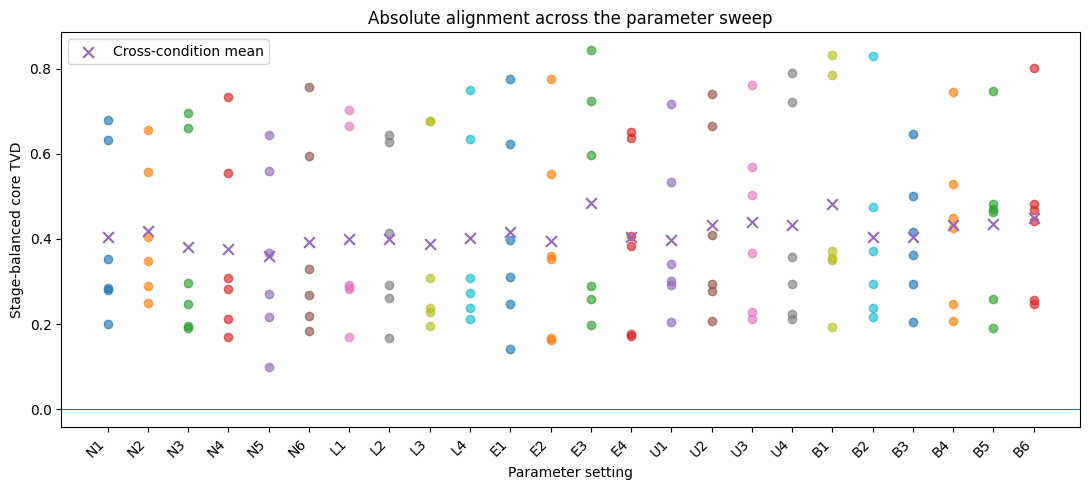

In [196]:
PARAMETER_ORDER = [
    "N1", "N2", "N3", "N4", "N5", "N6",
    "L1", "L2", "L3", "L4",
    "E1", "E2", "E3", "E4",
    "U1", "U2", "U3", "U4",
    "B1", "B2", "B3", "B4", "B5", "B6",
]

plot_alignment = (
    core_alignment
    .copy()
)

plot_alignment[
    "parameter_id"
] = pd.Categorical(
    plot_alignment[
        "parameter_id"
    ],
    categories=PARAMETER_ORDER,
    ordered=True,
)

parameter_means = (
    plot_alignment
    .groupby(
        "parameter_id",
        observed=True,
    )[
        "core_stage_balanced_tvd"
    ]
    .mean()
    .reindex(PARAMETER_ORDER)
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

for x, parameter_id in enumerate(
    PARAMETER_ORDER
):

    values = (
        plot_alignment.loc[
            plot_alignment[
                "parameter_id"
            ] == parameter_id,
            "core_stage_balanced_tvd",
        ]
        .to_numpy()
    )

    ax.scatter(
        np.repeat(
            x,
            len(values),
        ),
        values,
        alpha=0.65,
    )

ax.scatter(
    np.arange(
        len(PARAMETER_ORDER)
    ),
    parameter_means.values,
    marker="x",
    s=60,
    label="Cross-condition mean",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_xticks(
    np.arange(
        len(PARAMETER_ORDER)
    )
)

ax.set_xticklabels(
    PARAMETER_ORDER,
    rotation=45,
    ha="right",
)

ax.set_ylabel(
    "Stage-balanced core TVD"
)

ax.set_xlabel(
    "Parameter setting"
)

ax.set_title(
    "Absolute alignment across the parameter sweep"
)

ax.legend()

plt.tight_layout()
plt.show()

## 15.10 — Interpretation boundary

This robustness analysis does not imply that every model is misaligned at every stage or every prefix.

Individual model × parameter × stage conditions can show low TVD, and the preceding analyses demonstrate substantial heterogeneity across models, stages, and prefixes.

The claim is narrower:

> The overall probabilistic-alignment phenomenon established in the main grid remains present across the wider mathematical parameter space and is not an artefact of selecting only the canonical parameter settings.

The stage-balanced summary is used only to establish this robustness property. Local interpretation continues to rely on the stage- and prefix-level analyses.

## 15.11 — Result statement

The probabilistic misalignment observed under the canonical target distributions persisted across the wider parameter sweep.

Using ROOT, dot, and Fraction depth 1—the three informative stages available in all 144 model × parameter conditions—a stage-balanced descriptive TVD had a mean of approximately $0.414$ and a median of approximately $0.354$. The observed values ranged from approximately $0.099$ to $0.843$.

The 30 canonical model × parameter cells had a mean stage-balanced TVD of approximately $0.405$ and a median of approximately $0.305$. The 114 non-canonical cells had corresponding values of approximately $0.416$ and $0.359$. Thus, moving away from the canonical distribution settings did not remove the alignment error.

At the parameter-setting level, mean stage-balanced TVD across the six evaluated model/protocol conditions ranged from approximately $0.360$ to $0.485$ across the 24 mathematical settings. None of the parameter settings produced cross-condition alignment close to TVD $=0$ on this common-stage summary.

Across all parameter settings and model/protocol conditions, mean absolute TVD was approximately $0.421$ at ROOT, $0.457$ at the dot stage, and $0.364$ at Fraction depth 1.

## 15.12 — Result conclusion

The main probabilistic-alignment failure identified in RQ1 is robust to changes in the mathematical parameters of the target distributions.

Misalignment is not confined to the canonical Normal, Laplace, Exponential, Uniform, and Beta settings. It remains present across changes to scale, location, rate, support, shape, and concentration, and no evaluated parameter setting eliminates the phenomenon across the six model/protocol conditions.

This robustness does not imply uniform failure. The preceding analyses show that the severity and location of misalignment depend strongly on the parameterisation, numerical stage, prefix, model, and prompting protocol. Rather, the parameter sweep strengthens the broader RQ1 conclusion: imperfect local probabilistic alignment is a persistent property of the evaluated models across a substantially wider set of target distributions than the canonical conditions alone.